In [1]:
# Notebook includes the code from main.py

In [2]:
# import libraries

#import libraries to conduct eda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

# import for distance calculations
!pip install geopy
from geopy import distance
import math

# import scipy for statistical analysis in eda
#!pip install scipy
from scipy import stats

# import datetime to set timestamp on pdf report
from datetime import datetime, timedelta

print("All required libraries installed")


All required libraries installed


In [3]:
# data file names 

data_file_hurr = "../data/ibtracs.NA.list.v04r01.csv"

data_file_gas = "../data/aaa_fl_metros_wayback_2022_2025.csv"
#"../data/gas_coordinates.csv"

data_file_coast = "../data/Gulf_Coast_Coords.csv"

data_file_metro_loc = "../data/gas_coordinates.csv"

In [4]:
# import file loading functions
from file_load import *

In [5]:
# import data files

# import data files
hurr_file_chk = input('Is hurricane data file downloaded to data folder? (y/n) ')
if hurr_file_chk == 'y':
    hurr_data = df_import(data_file_hurr)
else:
    url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.NA.list.v04r01.csv'
    hurr_data = pd.read_csv(url)
    
hurr_data.name = 'hurr_data'

gas_data = df_import(data_file_gas)
gas_data.name = 'gas_data'

coast_pt_data = df_import(data_file_coast)

metro_loc_data = coord_import(data_file_metro_loc)

Is hurricane data file downloaded to data folder? (y/n)  y


C:\Users\eenoo\Downloads\CSCI_5502\Project\src\file_load.py:6: DtypeWarning: Columns (1,2,3,8,9,14,19,20,23,24,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  pri_data = pd.read_csv(datafile)


Successfully loaded ../data/ibtracs.NA.list.v04r01.csv
Successfully loaded ../data/aaa_fl_metros_wayback_2022_2025.csv
Successfully loaded ../data/Gulf_Coast_Coords.csv
Successfully loaded ../data/gas_coordinates.csv


In [6]:
# import stats functions
from stats_look import *

In [7]:
# run stats on baseline data
# basic analysis on hurricane data
sum_stats(hurr_data)

# basic analysis on gas data
sum_stats(gas_data)


Statistics for hurr_data
<bound method DataFrame.info of                   SID SEASON NUMBER BASIN SUBBASIN     NAME  \
0                       Year                                  
1       1851175N26270   1851      5   NaN       GM  UNNAMED   
2       1851175N26270   1851      5   NaN       GM  UNNAMED   
3       1851175N26270   1851      5   NaN       GM  UNNAMED   
4       1851175N26270   1851      5   NaN       GM  UNNAMED   
...               ...    ...    ...   ...      ...      ...   
127645  2025291N11319   2025     93   NaN      NaN  MELISSA   
127646  2025291N11319   2025     93   NaN      NaN  MELISSA   
127647  2025291N11319   2025     93   NaN      NaN  MELISSA   
127648  2025291N11319   2025     93   NaN      NaN  MELISSA   
127649  2025291N11319   2025     93   NaN      NaN  MELISSA   

                   ISO_TIME NATURE            LAT           LON  ...  \
0                                   degrees_north  degrees_east  ...   
1       1851-06-23 12:00:00     TS        

In [8]:
# import data cleaning functions
from clean import *

In [9]:
# Clean hurricane data and generate data frames for cleaned hurricane data, list of hurricanes, and summary list of hurricanes with maximum storm category observed
# Generates data frames with ALL data and a set of filtered data frames for "recent" (2022-2025)
hurr_data_redux, hurr_list, hurr_sum_list, hurr_data_redux_rec, hurr_list_rec, hurr_sum_list_rec, hurr_data_redux_rec_hur = hurr_clean(hurr_data)

# Name output data frames
hurr_data_redux.name = 'hurr_data_redux'
hurr_list.name = 'hurr_list'
hurr_sum_list.name = 'hurr_sum_list'
hurr_data_redux_rec.name = 'hurr_data_redux_rec'
hurr_list_rec.name = 'hurr_list_rec'
hurr_sum_list_rec.name = 'hurr_sum_list_rec'
hurr_data_redux_rec_hur.name = 'hurr_data_redux_rec_hur'

Cleaning hurr_data
          Unit
SID           
SEASON    Year
NUMBER        
BASIN         
SUBBASIN      
(174, 1)
Data table columns reduced to 47
Hurricane data cleaning complete


In [10]:
# List metro areas of interest
# all FL cities selected to represent the perimeter

metro_all = ['Pensacola', 'Tallahassee', 'Tampa-St. Petersburg-Clearwater', 'Fort Myers-Cape Coral', 'Miami','West Palm Beach-Boca Raton','Melbourne-Titusville','Daytona Beach','Jacksonville']

# East coast of FL
metro_east = ['Miami','West Palm Beach-Boca Raton','Melbourne-Titusville','Daytona Beach','Jacksonville']

# West coast of FL (exl panhandle)
metro_west = ['Tampa-St. Petersburg-Clearwater', 'Fort Myers-Cape Coral']

# Panhandle of FL
metro_ph = ['Pensacola', 'Tallahassee']

# Gulf Coast of FL (West + Panhandle)
metro_gulf = ['Pensacola', 'Tallahassee', 'Tampa-St. Petersburg-Clearwater', 'Fort Myers-Cape Coral']


In [11]:
# Clean gas station data and generate data frame for cleaned gas station data
gas_data_redux = gas_clean(gas_data)
gas_data_redux.name = 'gas_data_redux'

Cleaning gas_data
Gas data cleaning complete


In [12]:
# run stats on cleaned data
# basic analysis on cleaned hurricane data
sum_stats(hurr_data_redux)

Statistics for hurr_data_redux
<bound method DataFrame.info of                   SID  SEASON  NUMBER BASIN SUBBASIN     NAME  \
1       1851175N26270    1851       5  NATL       GM  UNNAMED   
2       1851175N26270    1851       5  NATL       GM  UNNAMED   
3       1851175N26270    1851       5  NATL       GM  UNNAMED   
4       1851175N26270    1851       5  NATL       GM  UNNAMED   
5       1851175N26270    1851       5  NATL       GM  UNNAMED   
...               ...     ...     ...   ...      ...      ...   
127645  2025291N11319    2025      93  NATL      NaN  MELISSA   
127646  2025291N11319    2025      93  NATL      NaN  MELISSA   
127647  2025291N11319    2025      93  NATL      NaN  MELISSA   
127648  2025291N11319    2025      93  NATL      NaN  MELISSA   
127649  2025291N11319    2025      93  NATL      NaN  MELISSA   

                  ISO_TIME NATURE   LAT   LON  ... USA_EYE  USA_GUST  \
1      1851-06-23 12:00:00     TS  26.1 -90.4  ...     NaN             
2      1851-

In [13]:
# basic analysis on cleaned gas data
sum_stats(gas_data_redux)


Statistics for gas_data_redux
<bound method DataFrame.info of                             metro       date   regular    mid   premium  \
0       Bradenton-Sarasota-Venice 2022-01-21  3.236000  3.625  3.915000   
1       Bradenton-Sarasota-Venice 2022-01-22  3.254667  3.639  3.929667   
2       Bradenton-Sarasota-Venice 2022-01-23  3.273333  3.653  3.944333   
3       Bradenton-Sarasota-Venice 2022-01-24  3.292000  3.667  3.959000   
4       Bradenton-Sarasota-Venice 2022-01-25  3.310667  3.681  3.973667   
...                           ...        ...       ...    ...       ...   
34555  West Palm Beach-Boca Raton 2025-12-26  2.940500  3.410  3.724000   
34556  West Palm Beach-Boca Raton 2025-12-27  2.917000  3.350  3.682000   
34557  West Palm Beach-Boca Raton 2025-12-28  2.912000  3.333  3.692000   
34558  West Palm Beach-Boca Raton 2025-12-29  2.901000  3.304  3.679000   
34559  West Palm Beach-Boca Raton 2025-12-30  2.954000  3.405  3.757000   

         diesel  year  month   date_k

In [14]:
# Run visualizations

from eda_visuals import *

Starting EDA for hurr_sum_list


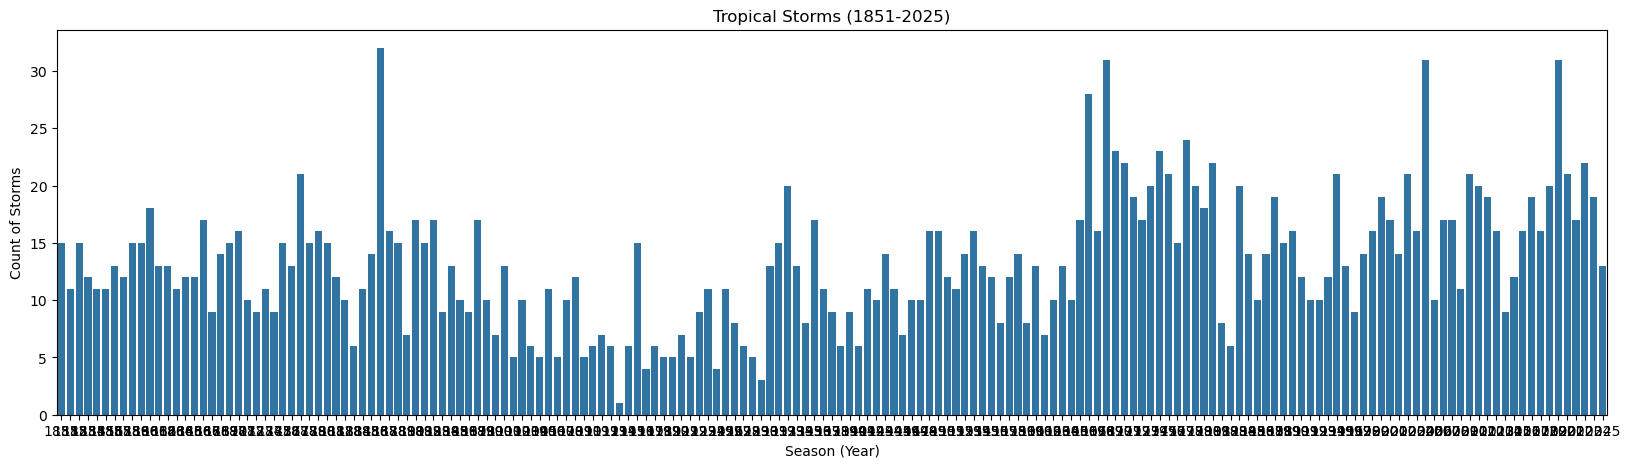

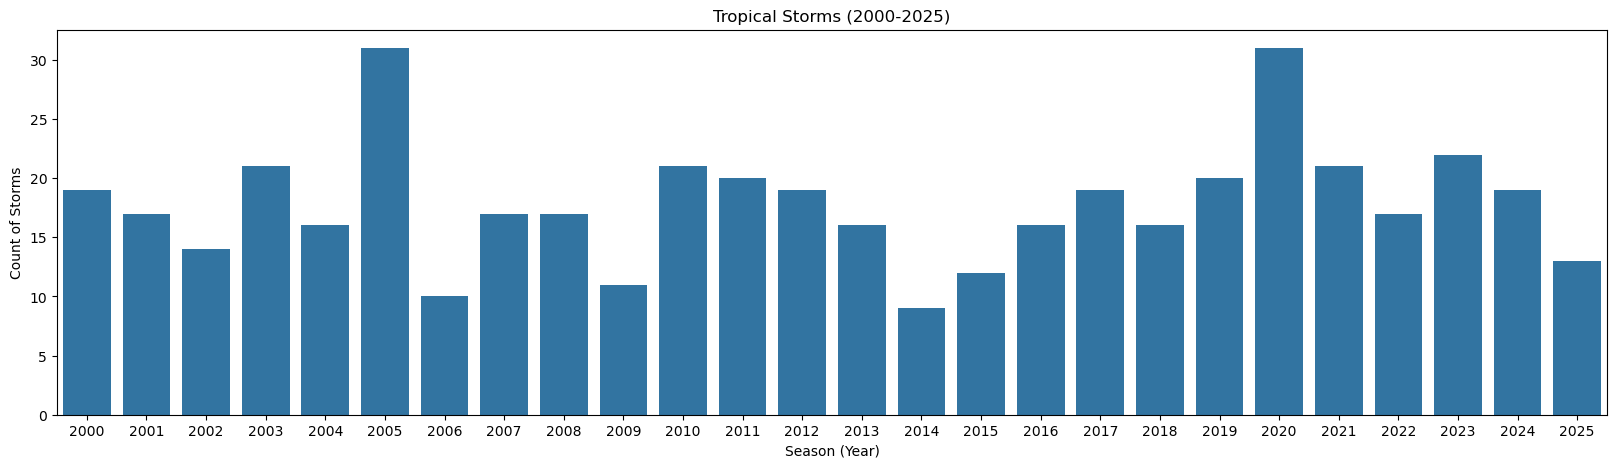

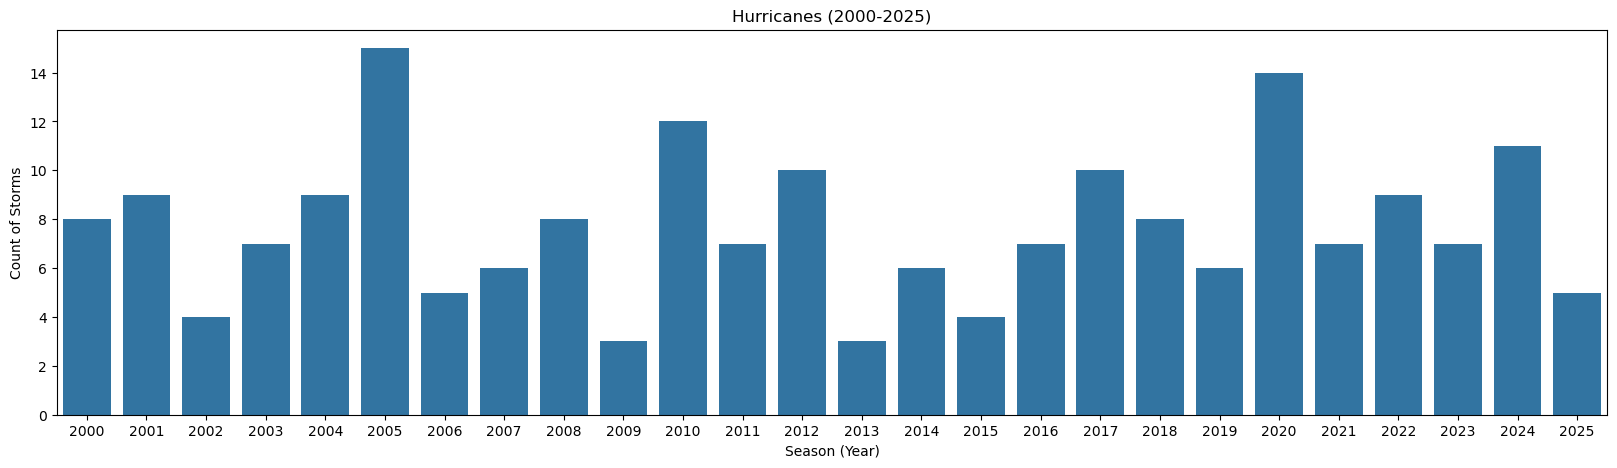

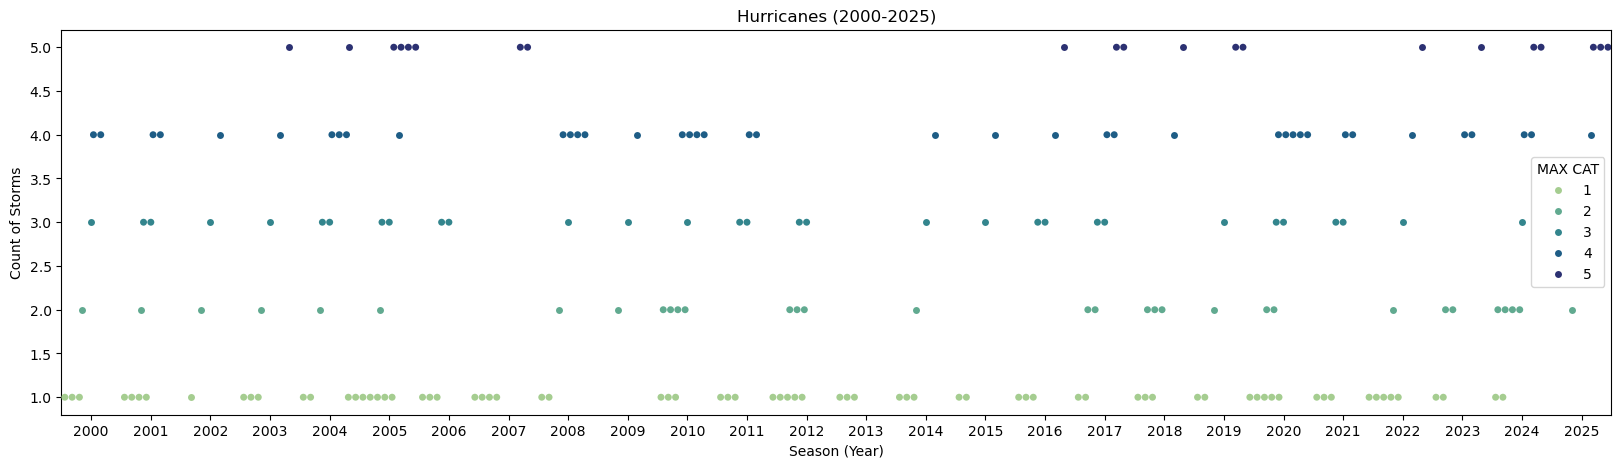

Starting EDA for hurr_sum_list_rec


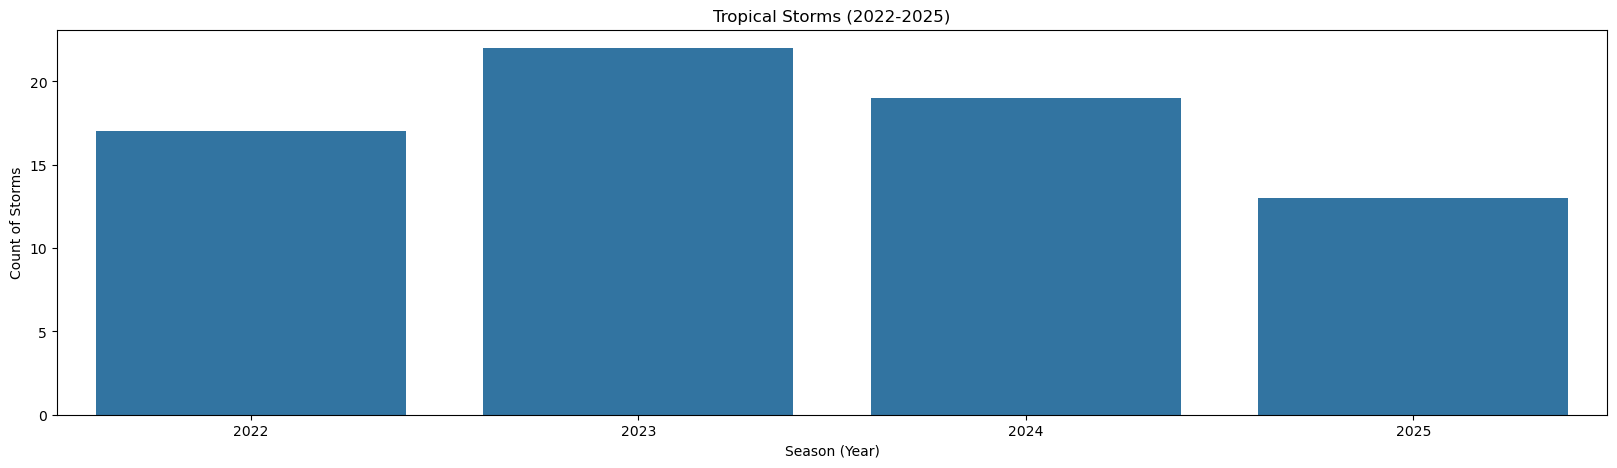

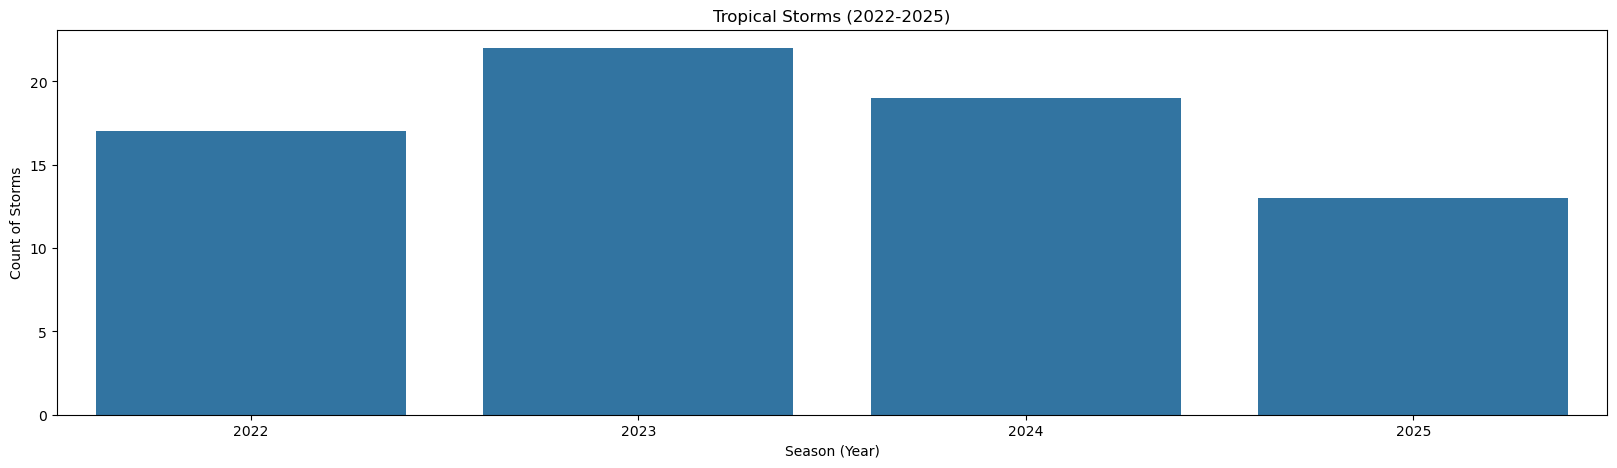

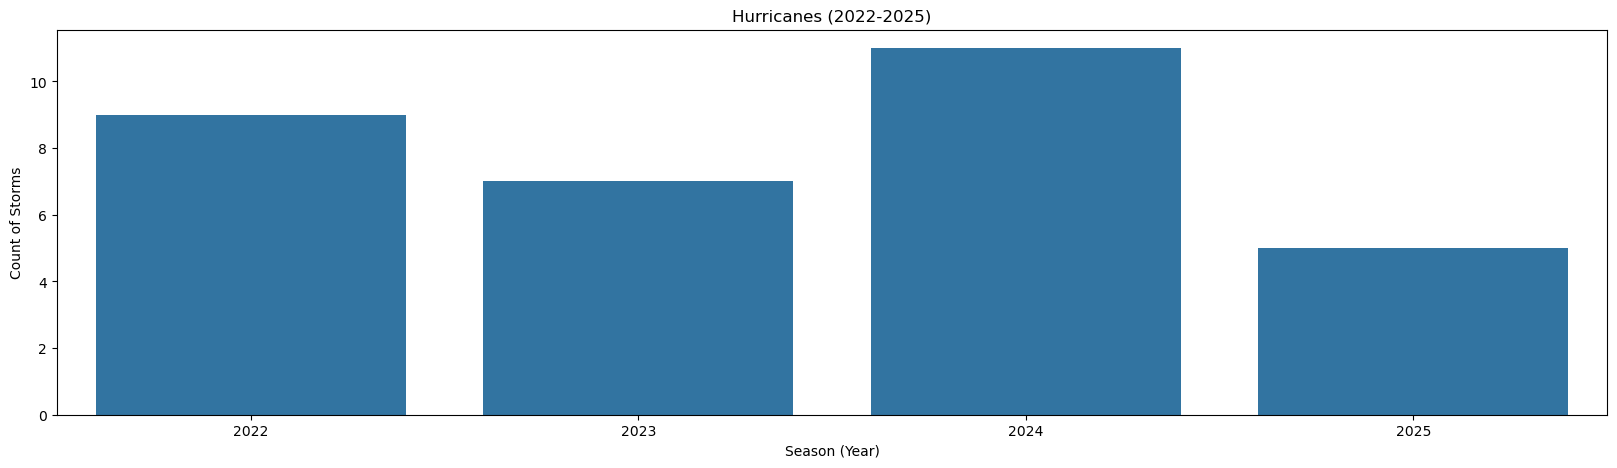

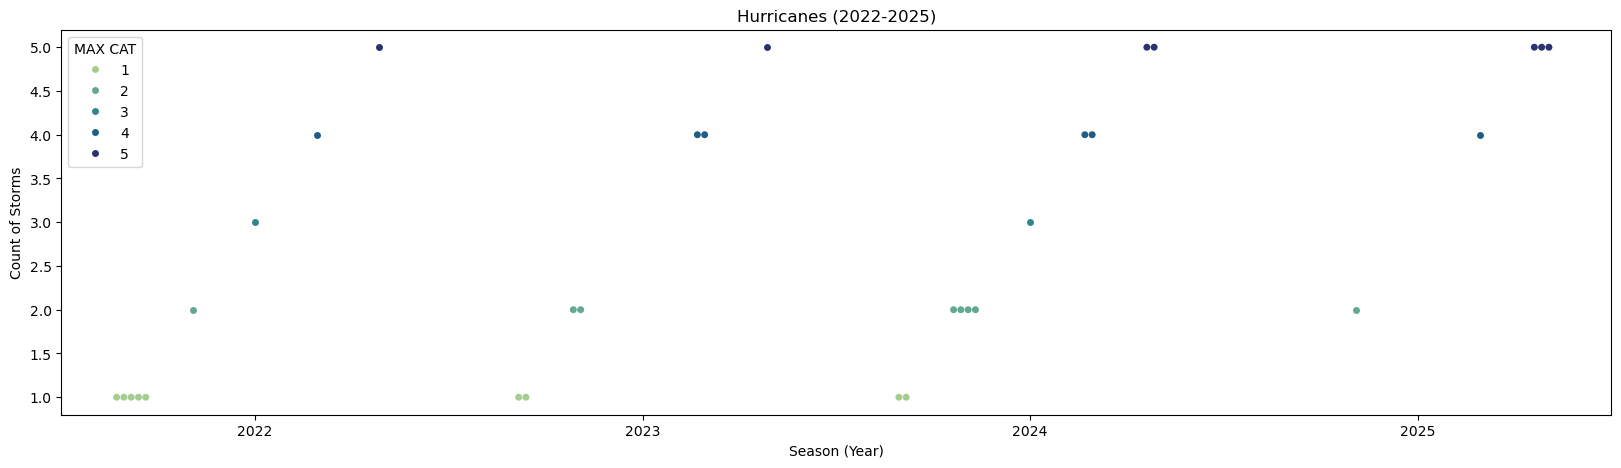

In [15]:
# Hurricane Overview Visuals
hurr_visuals(hurr_sum_list)
hurr_visuals(hurr_sum_list_rec)


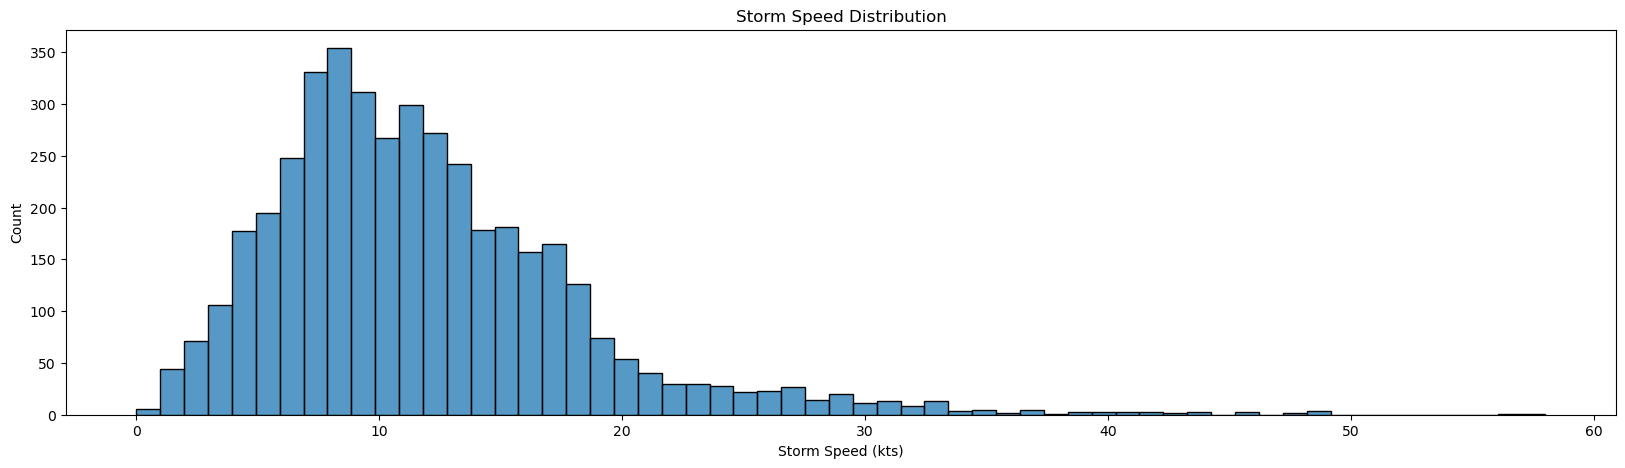

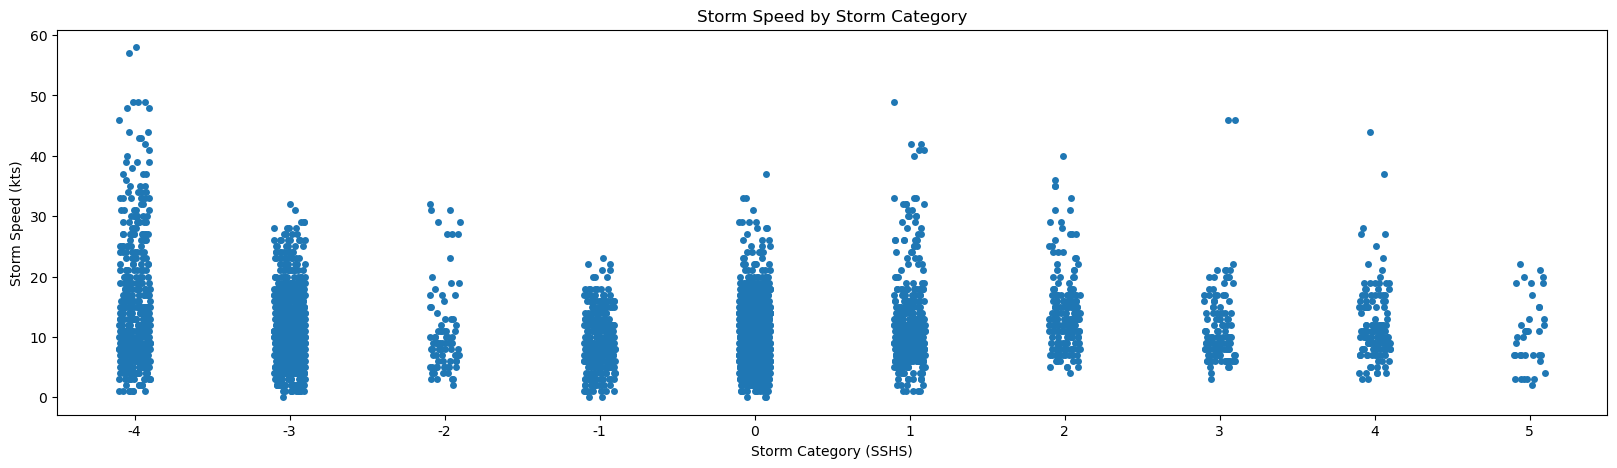

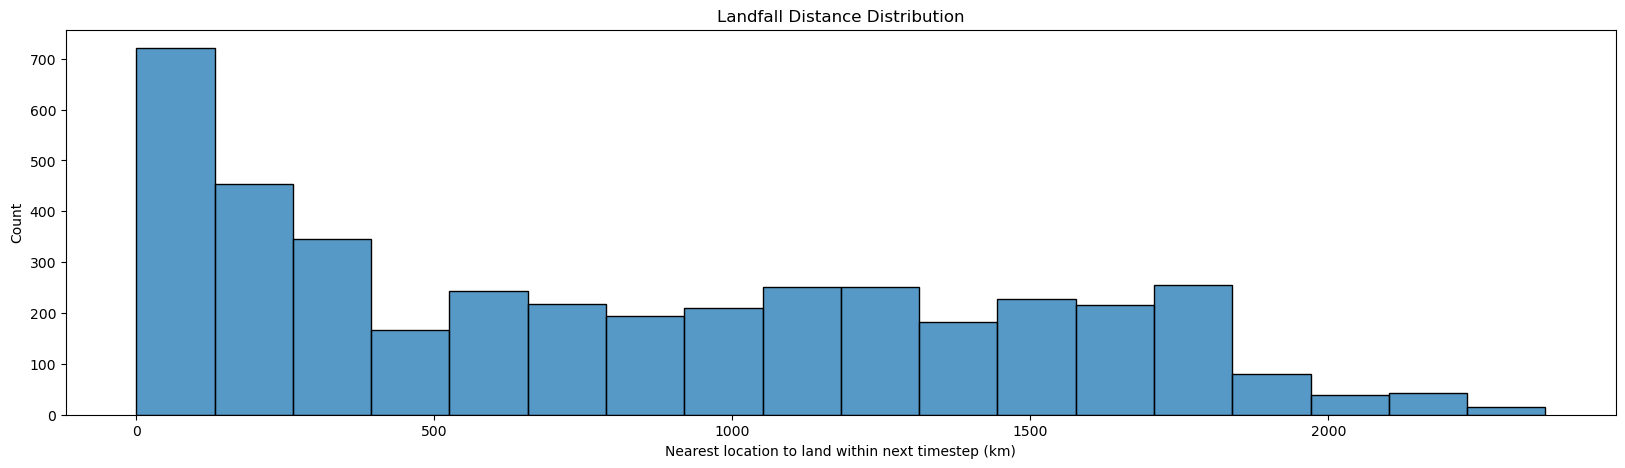

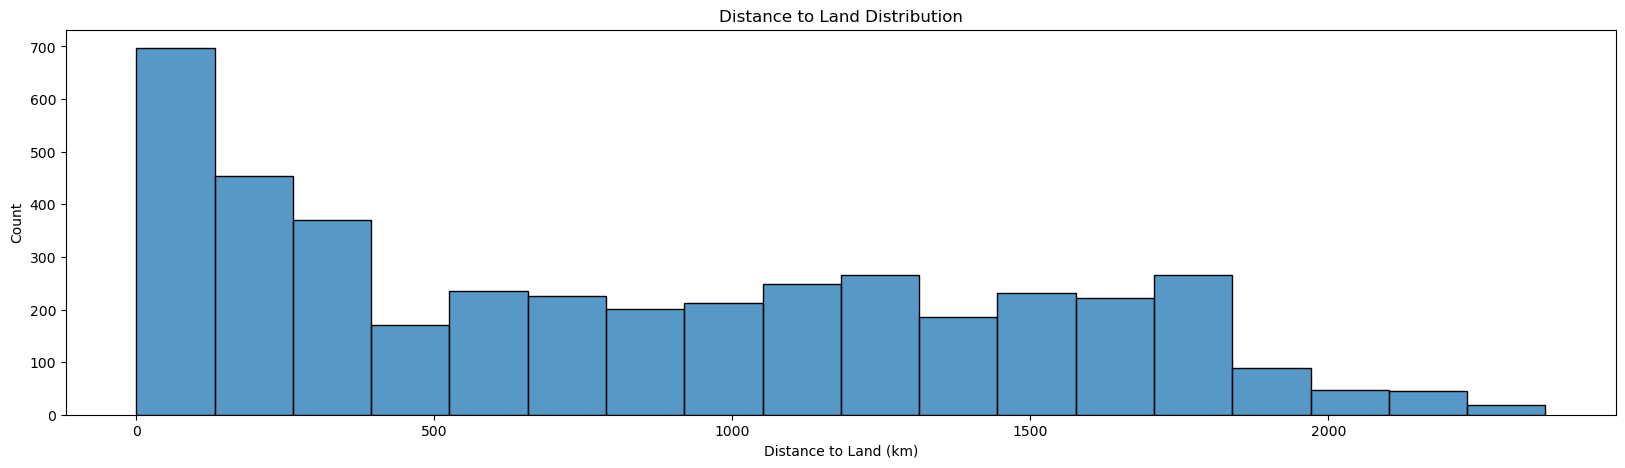

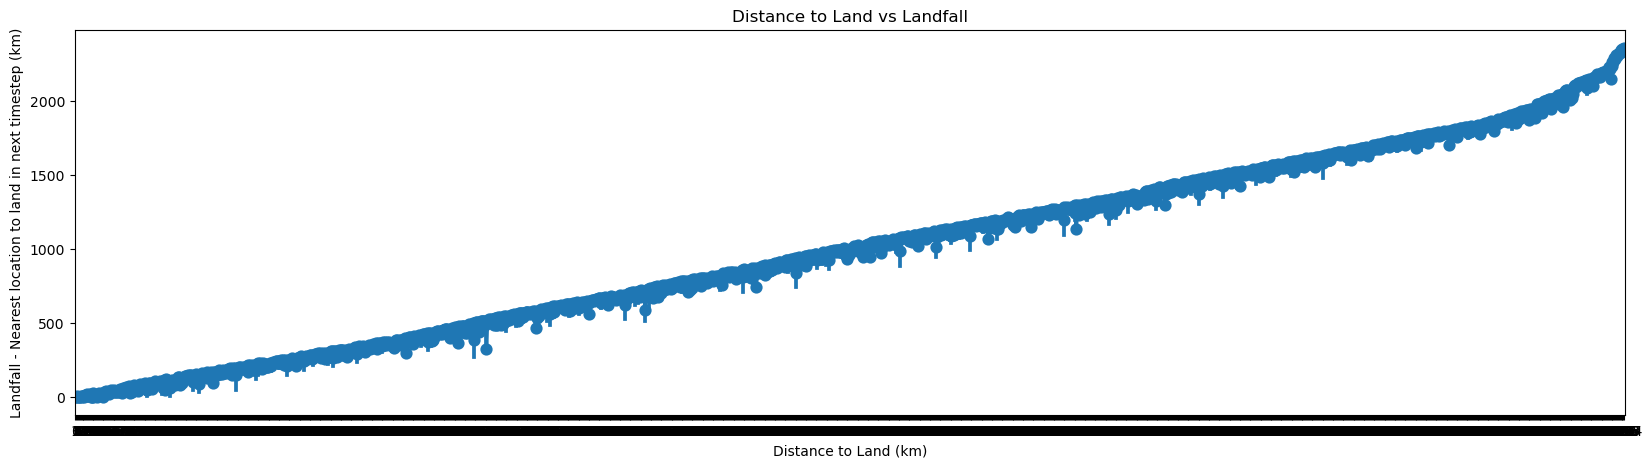

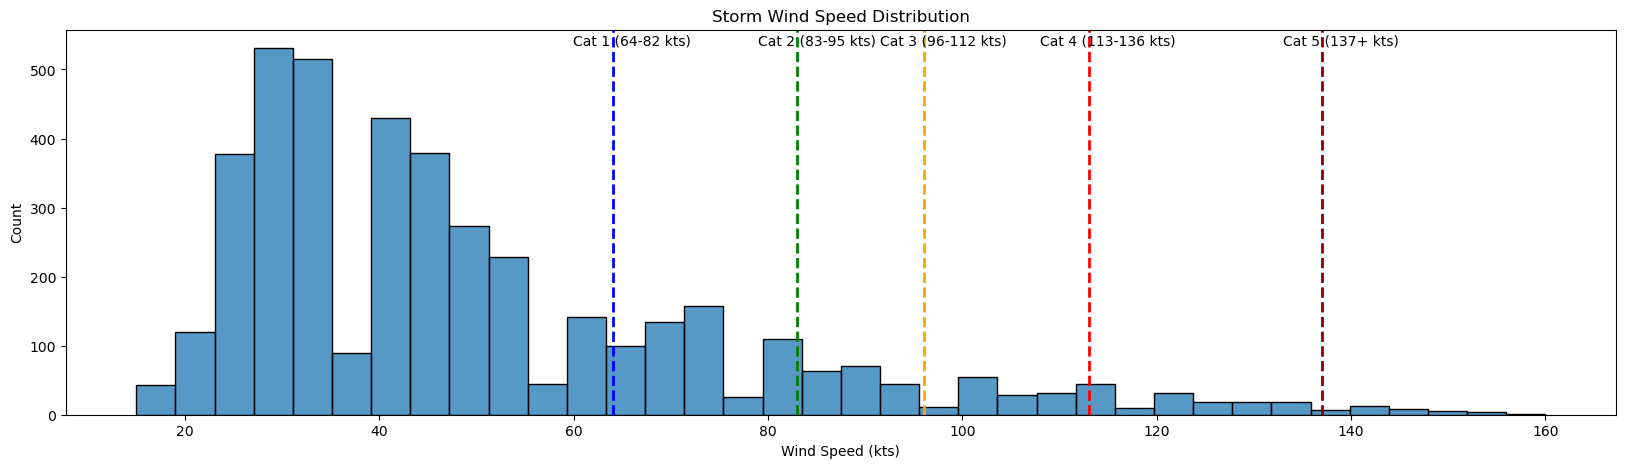

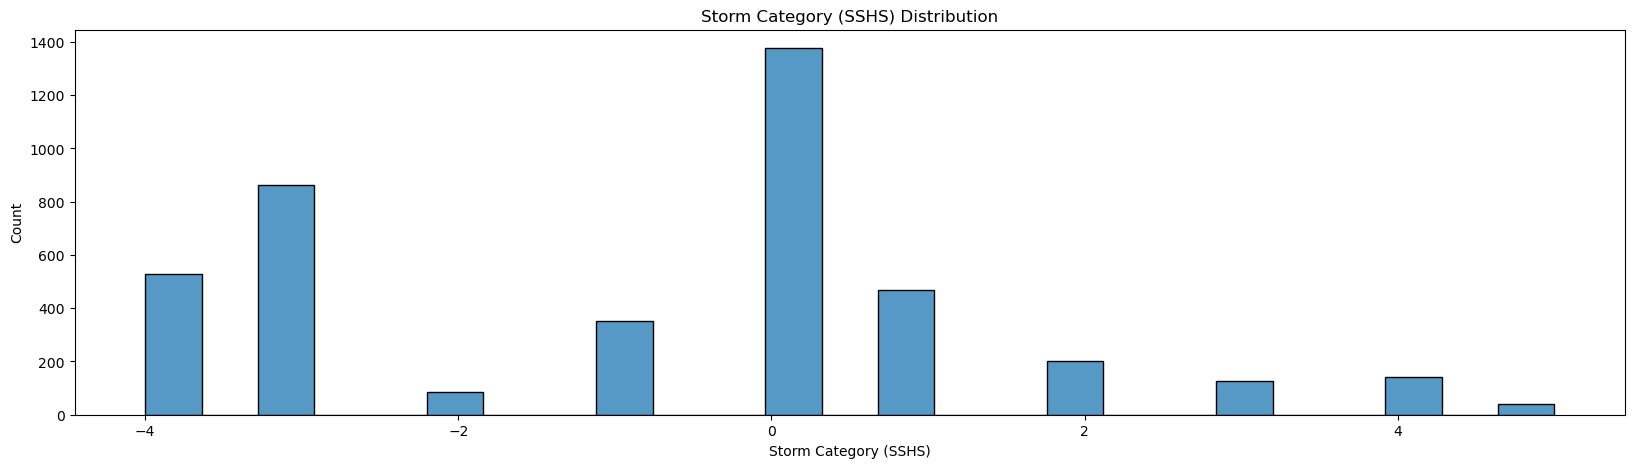

In [16]:
# Hurricane Stats Visuals
# All storms 2022-2025
stats_hurr_viz(hurr_data_redux_rec)

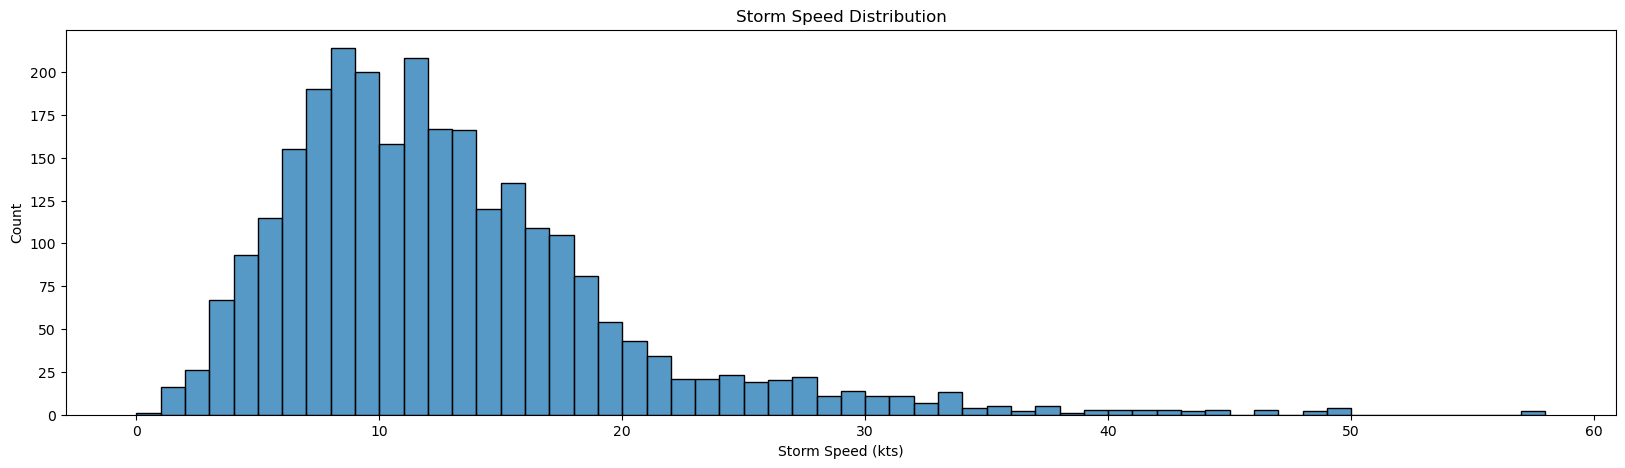

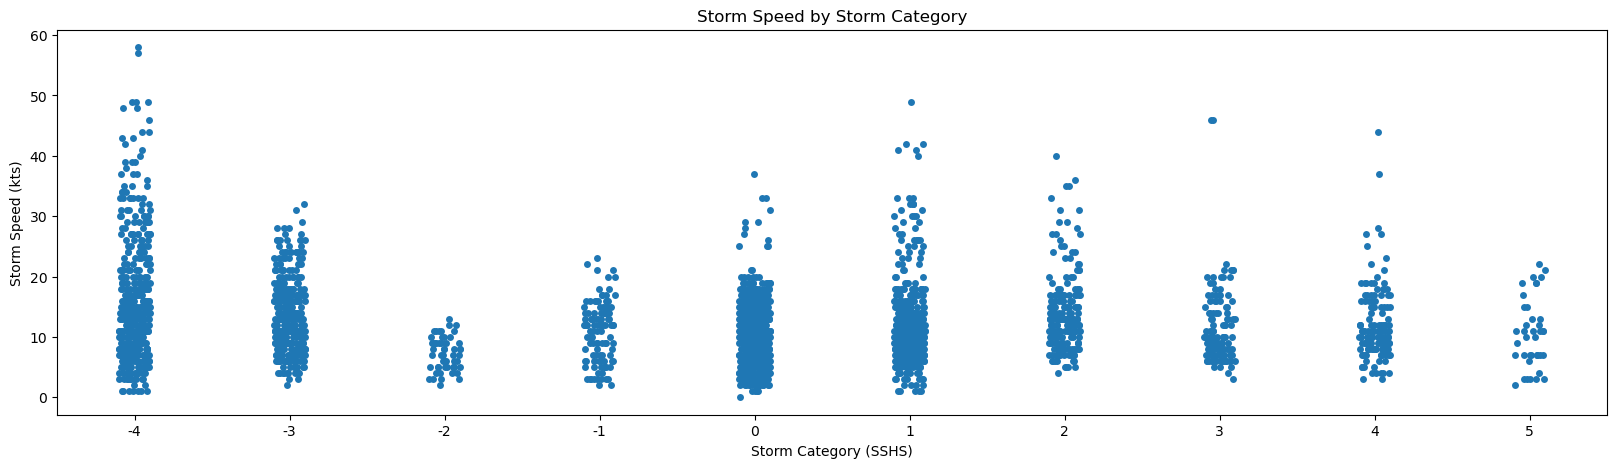

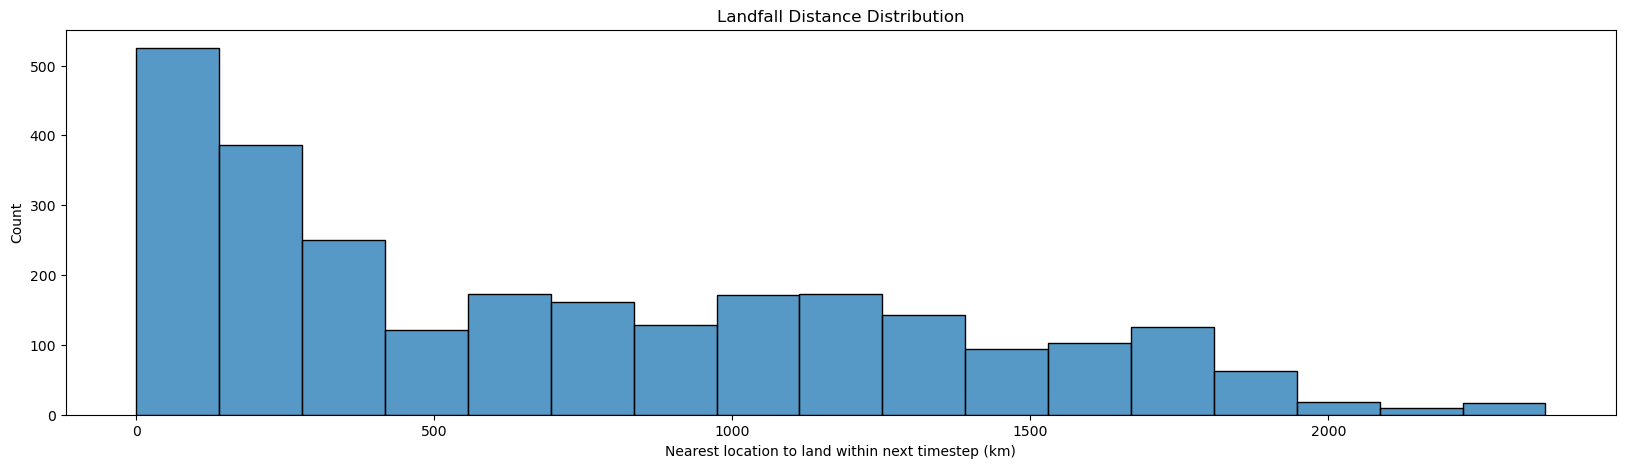

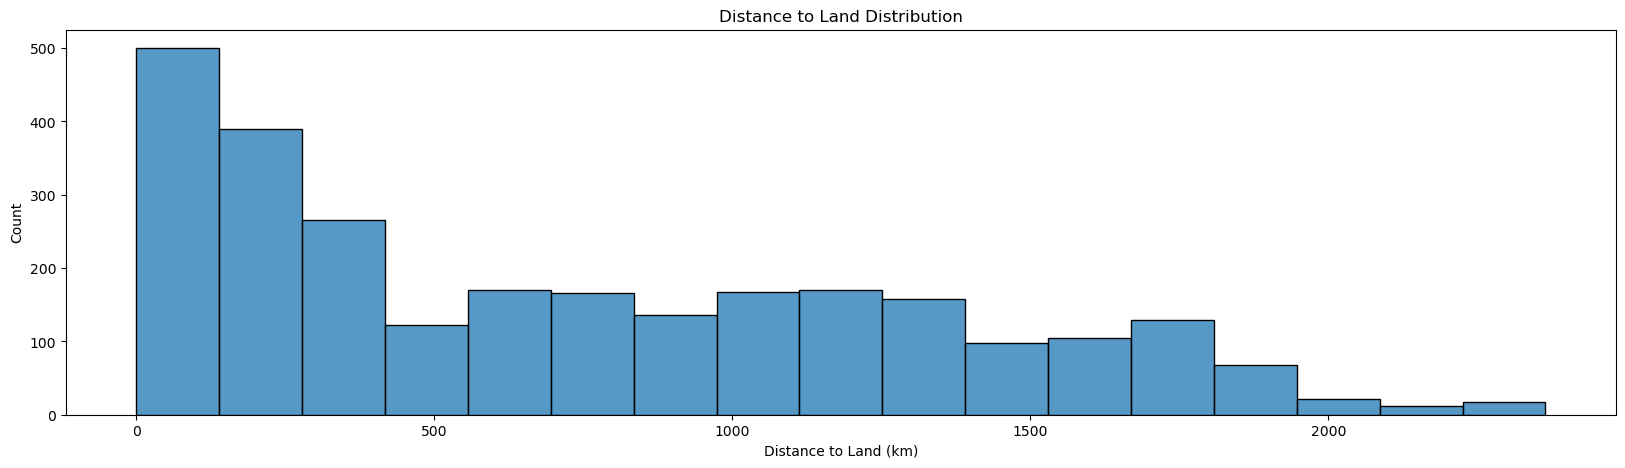

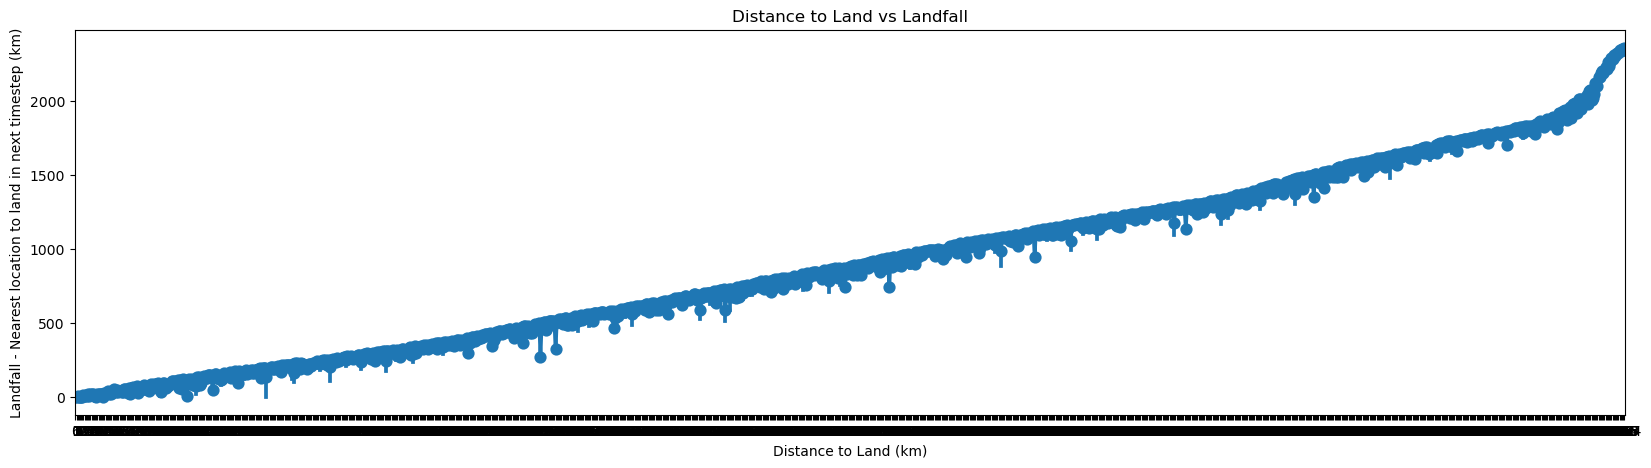

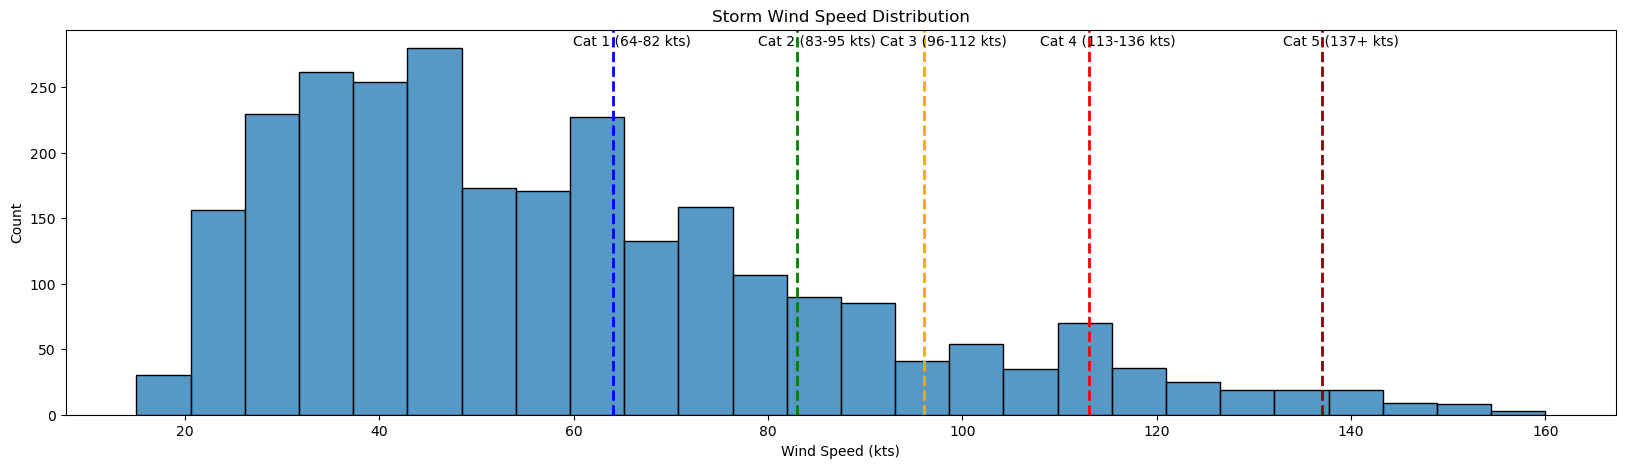

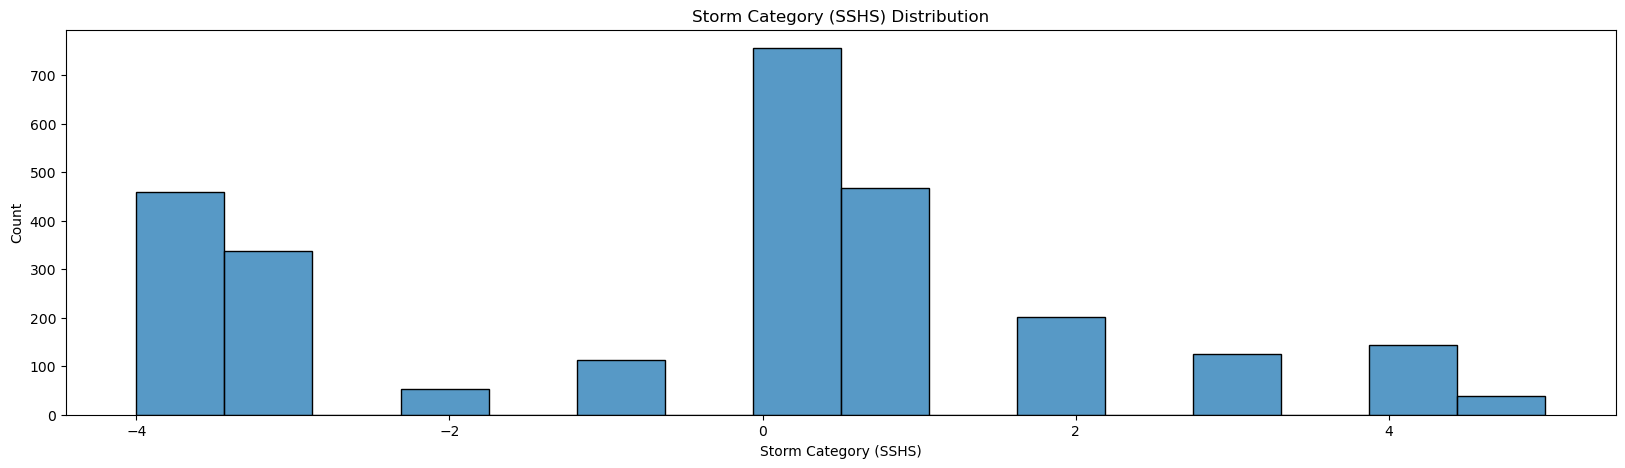

In [17]:
# ALl hurricanes 2022-2025
stats_hurr_viz(hurr_data_redux_rec_hur)

Starting overview for gas_data_redux and ['Pensacola', 'Tallahassee', 'Tampa-St. Petersburg-Clearwater', 'Fort Myers-Cape Coral', 'Miami', 'West Palm Beach-Boca Raton', 'Melbourne-Titusville', 'Daytona Beach', 'Jacksonville']


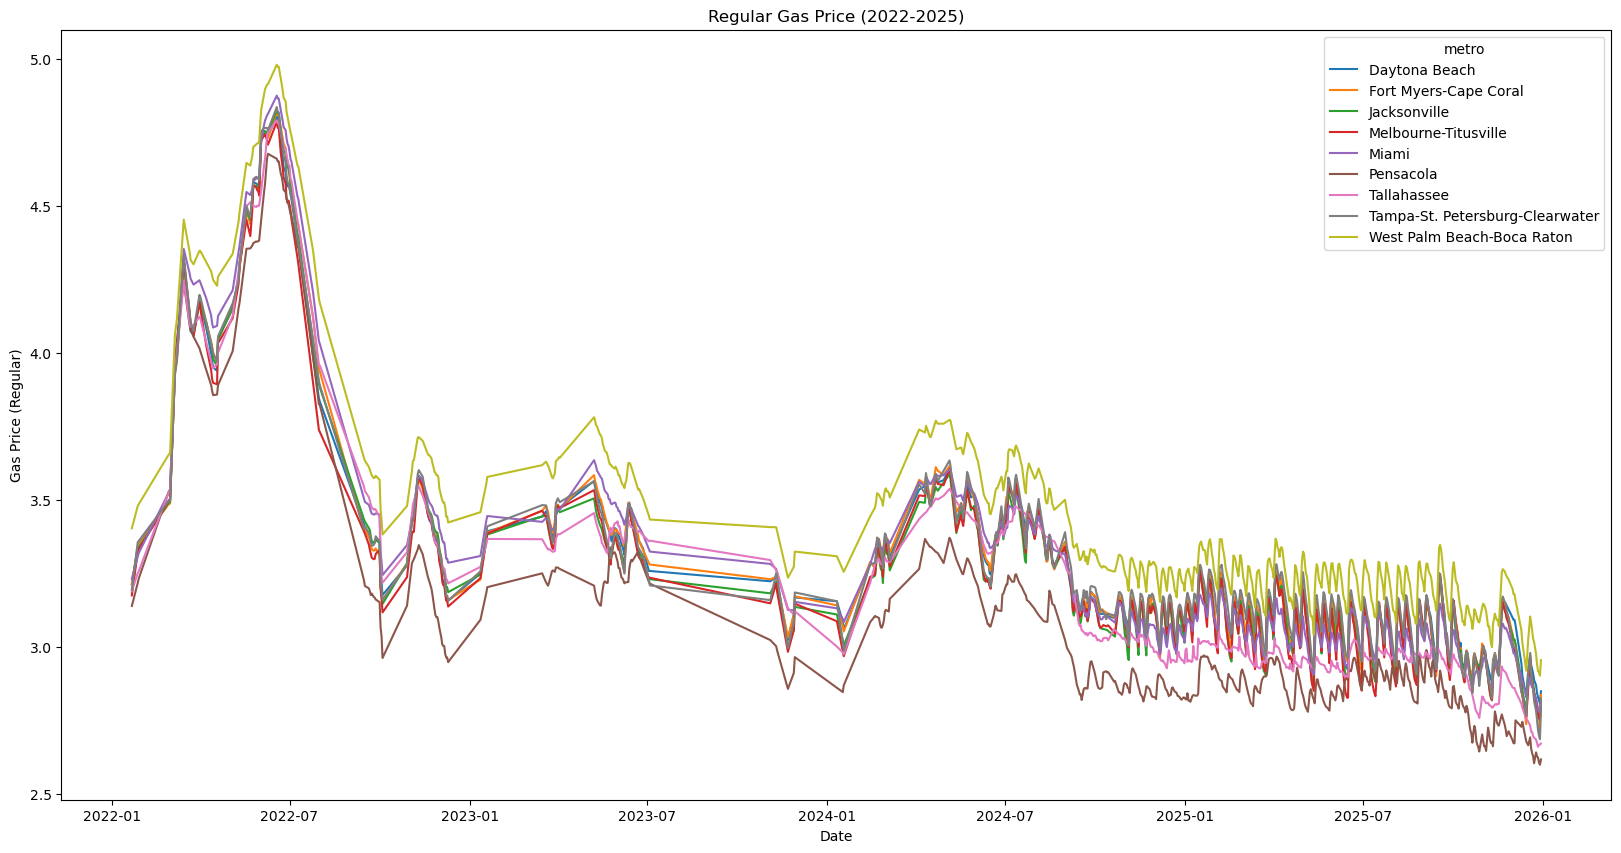

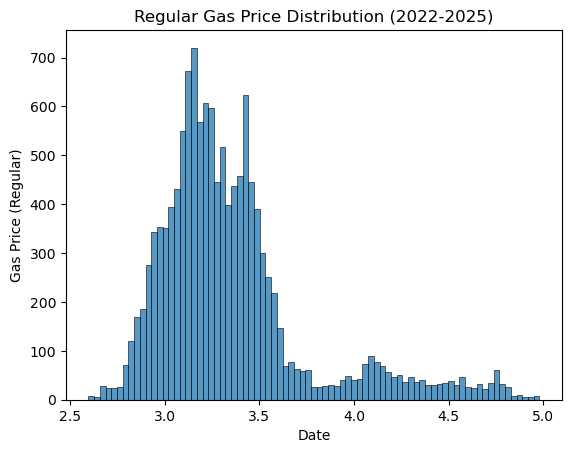

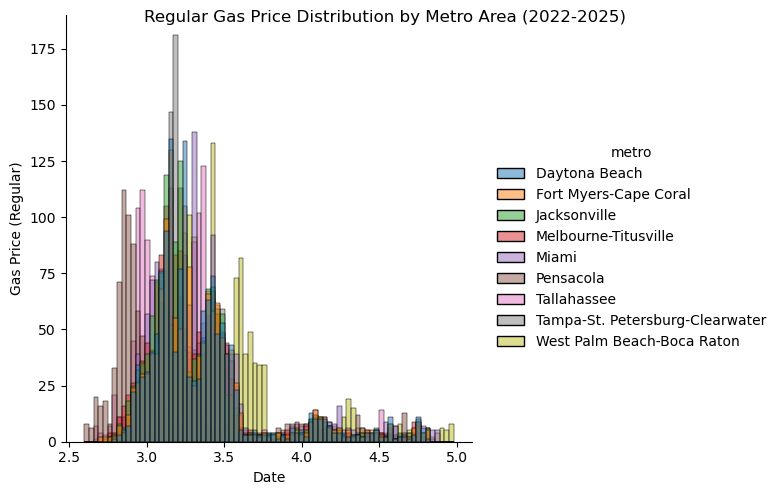

Starting EDA for gas_data_redux and ['Miami', 'West Palm Beach-Boca Raton', 'Melbourne-Titusville', 'Daytona Beach', 'Jacksonville']


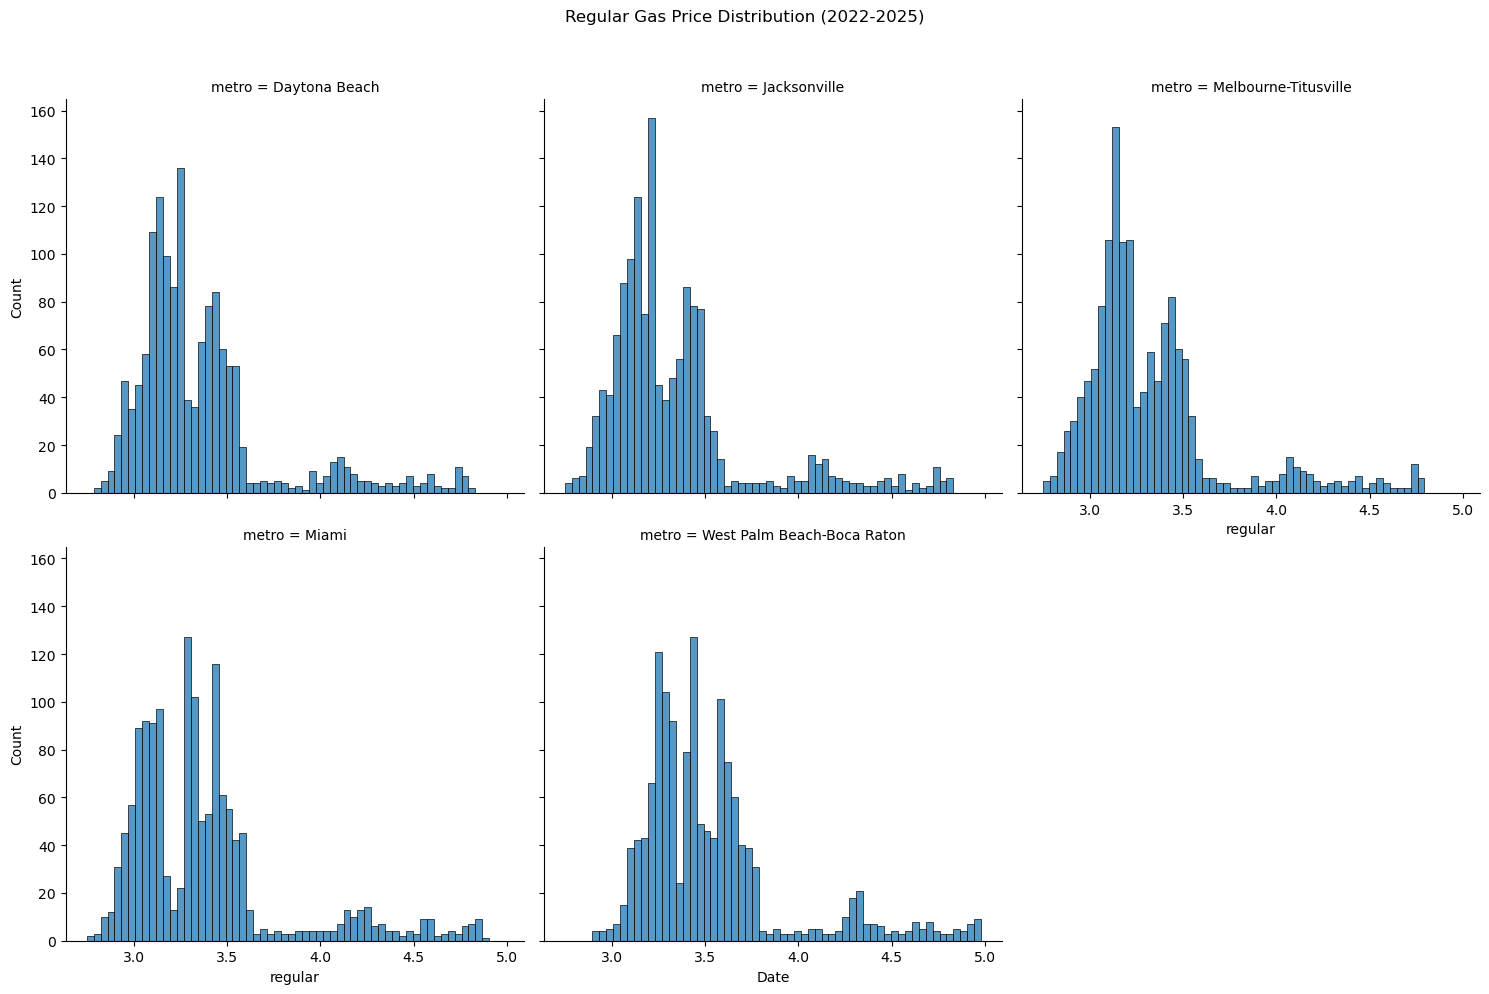

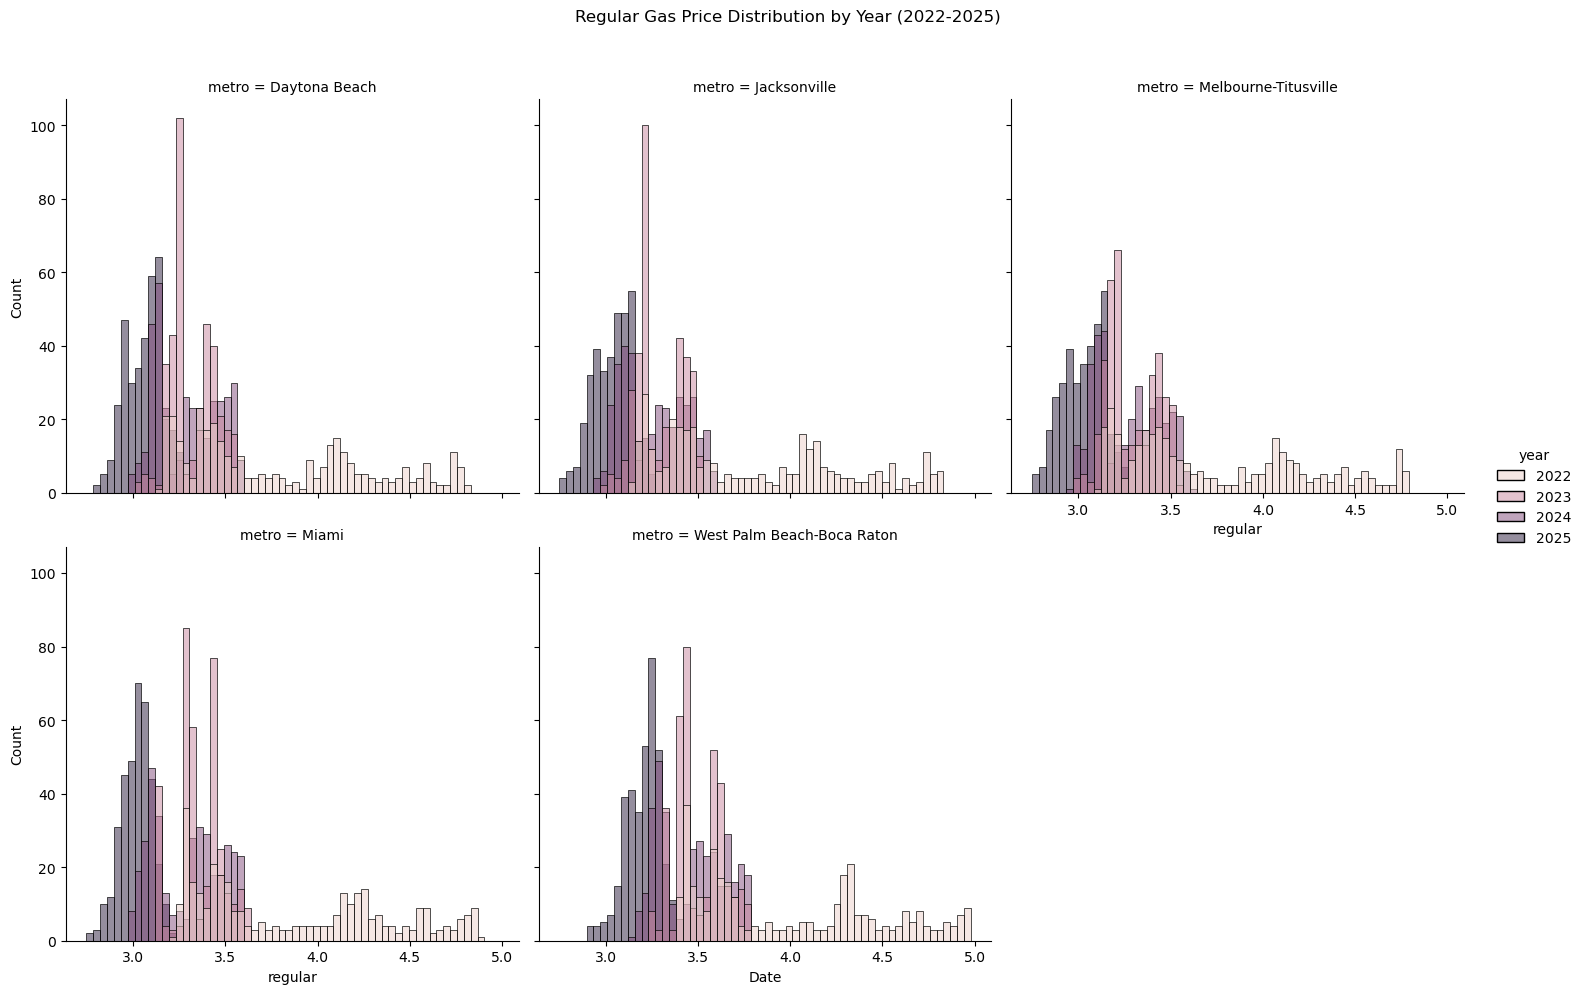

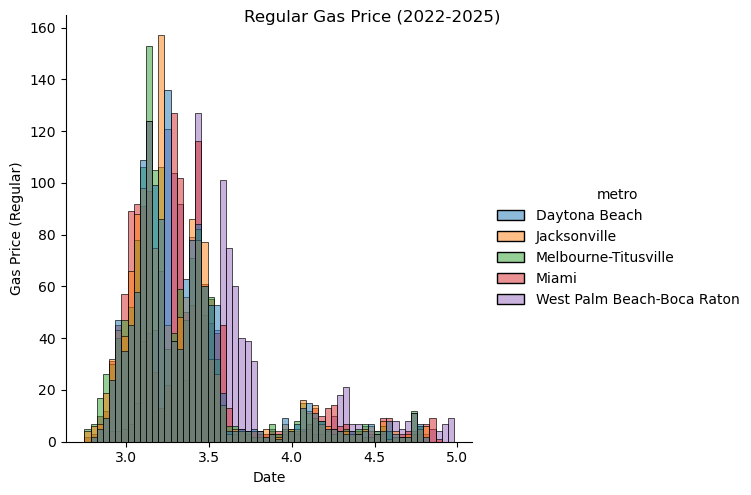

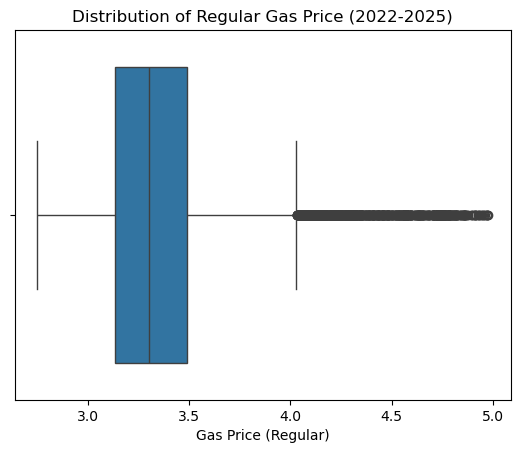

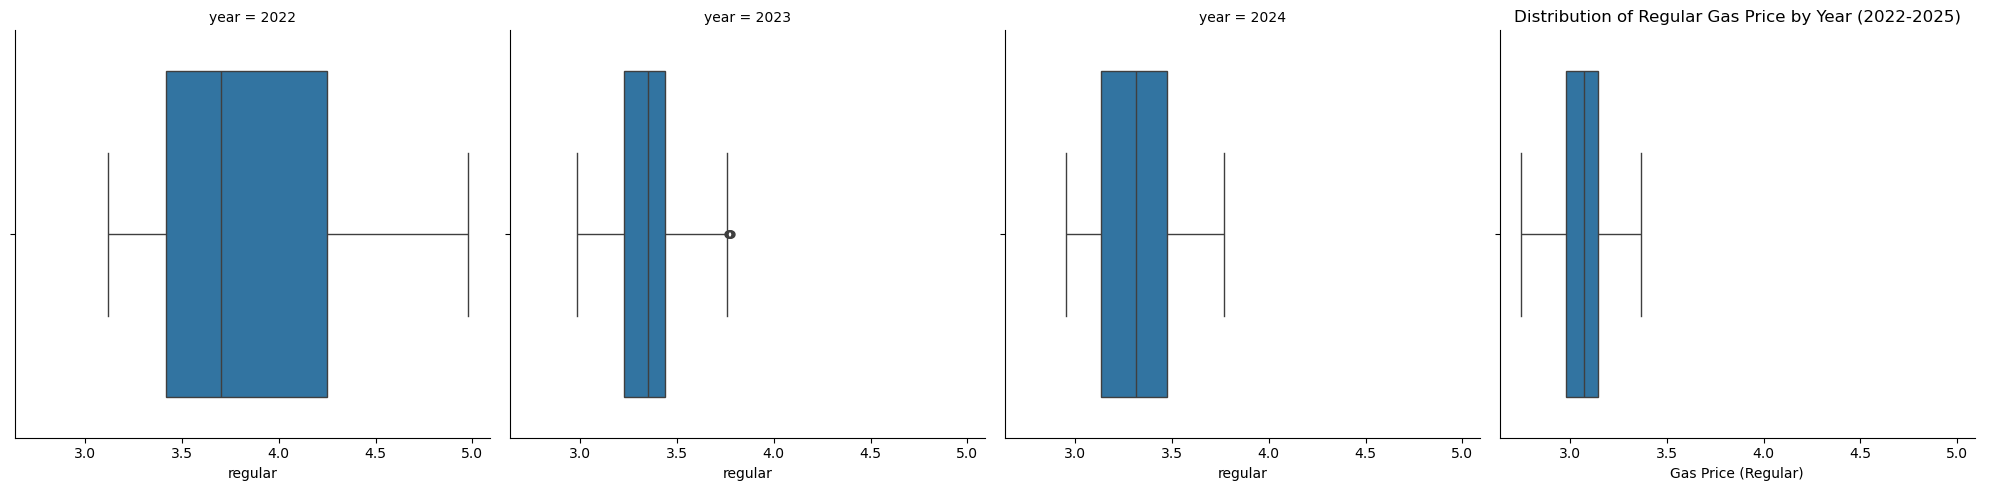

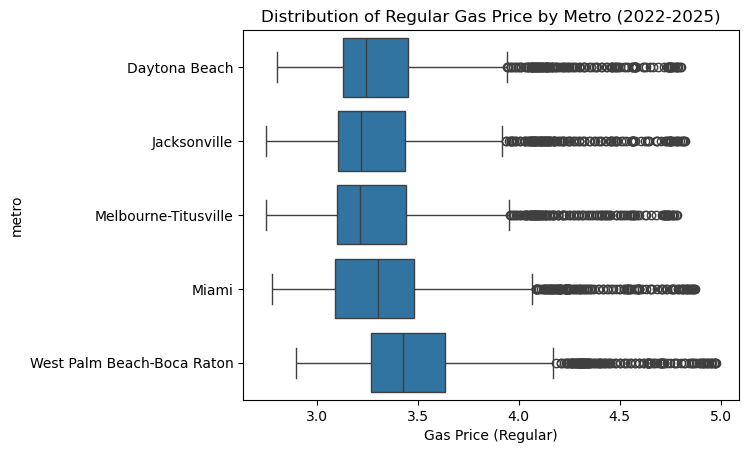

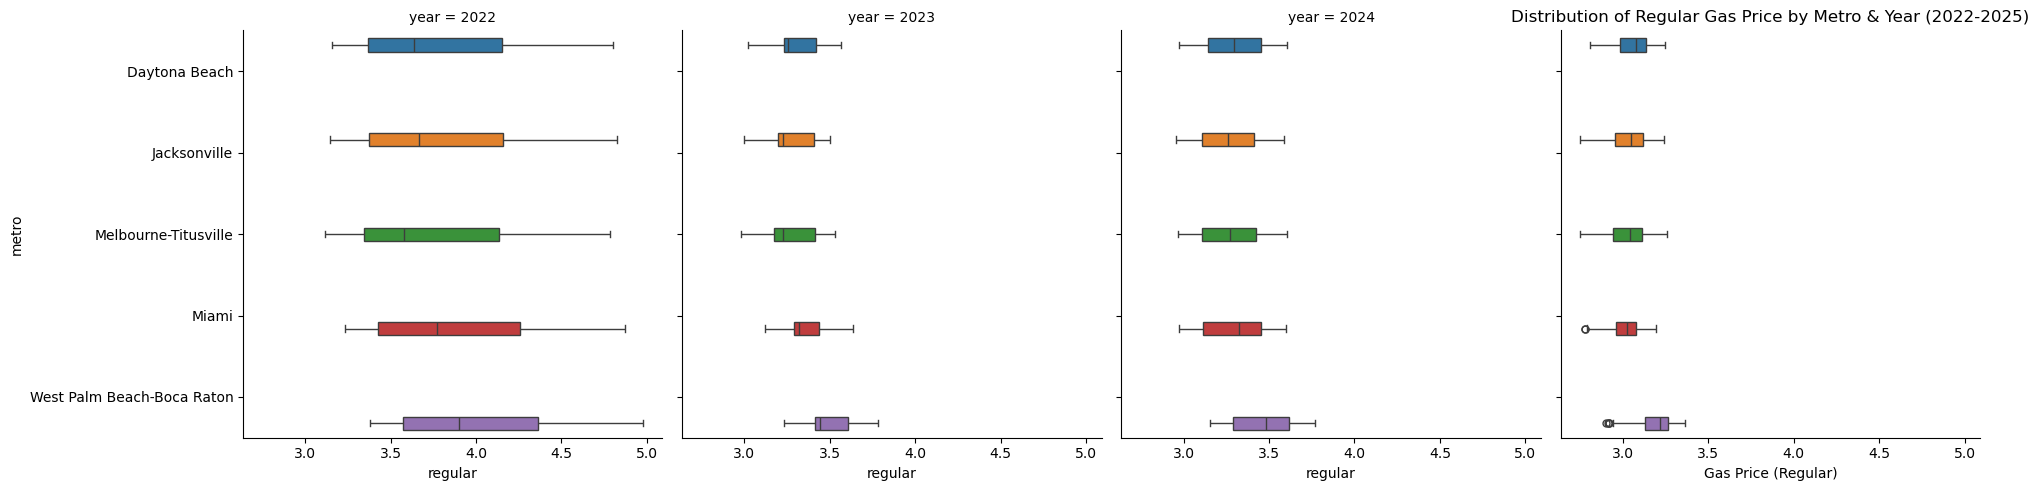

Starting EDA for gas_data_redux and ['Pensacola', 'Tallahassee', 'Tampa-St. Petersburg-Clearwater', 'Fort Myers-Cape Coral']


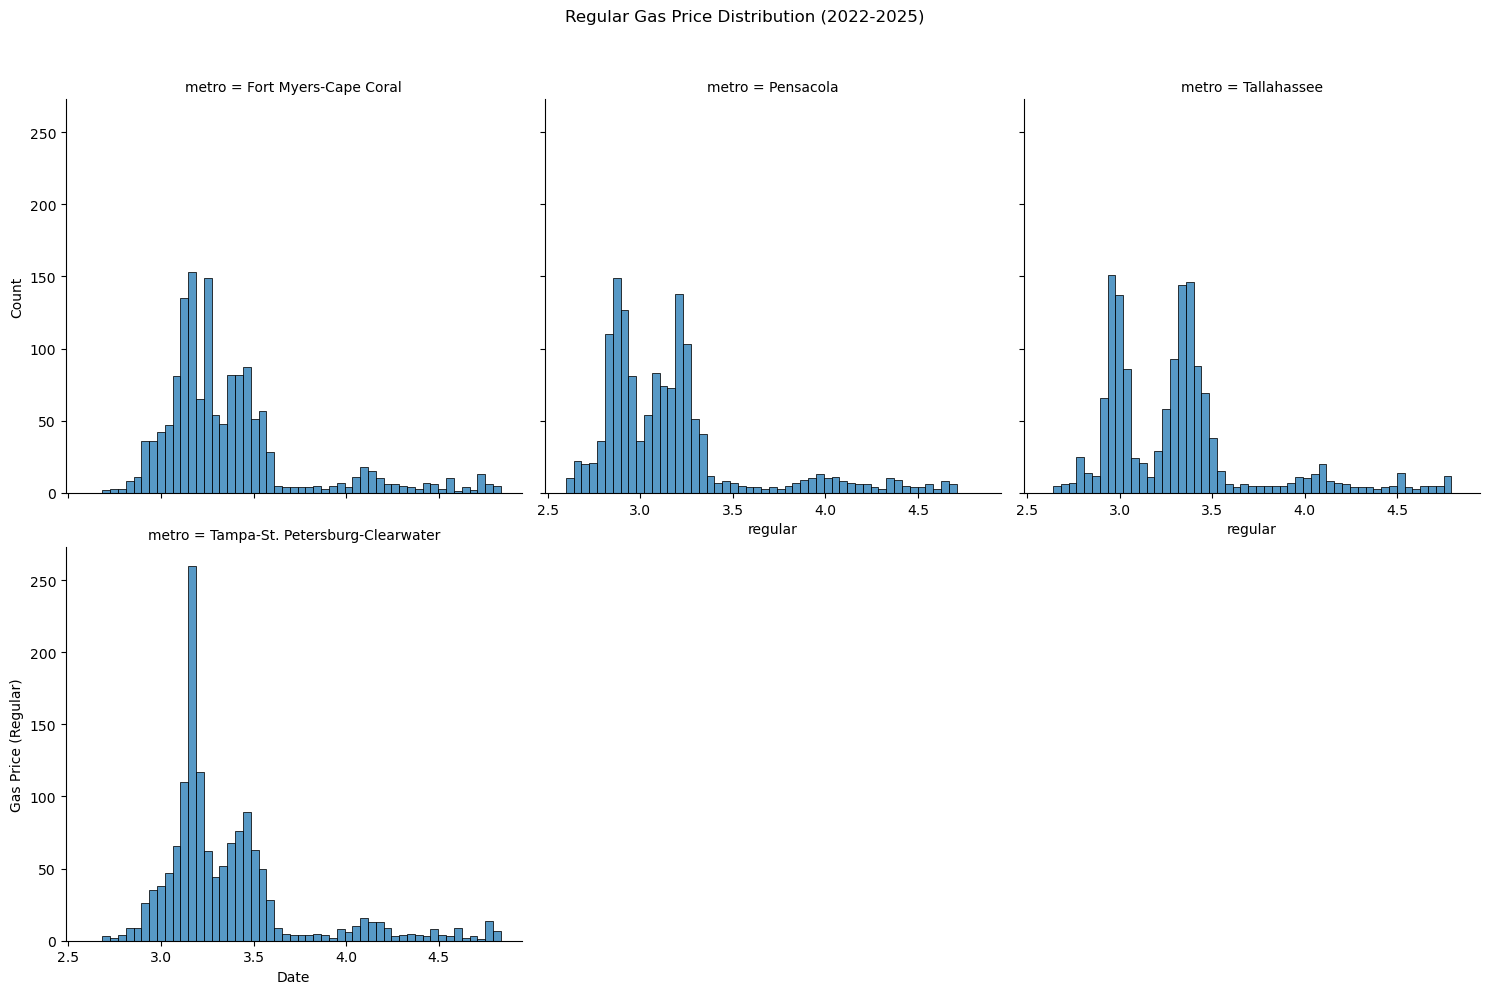

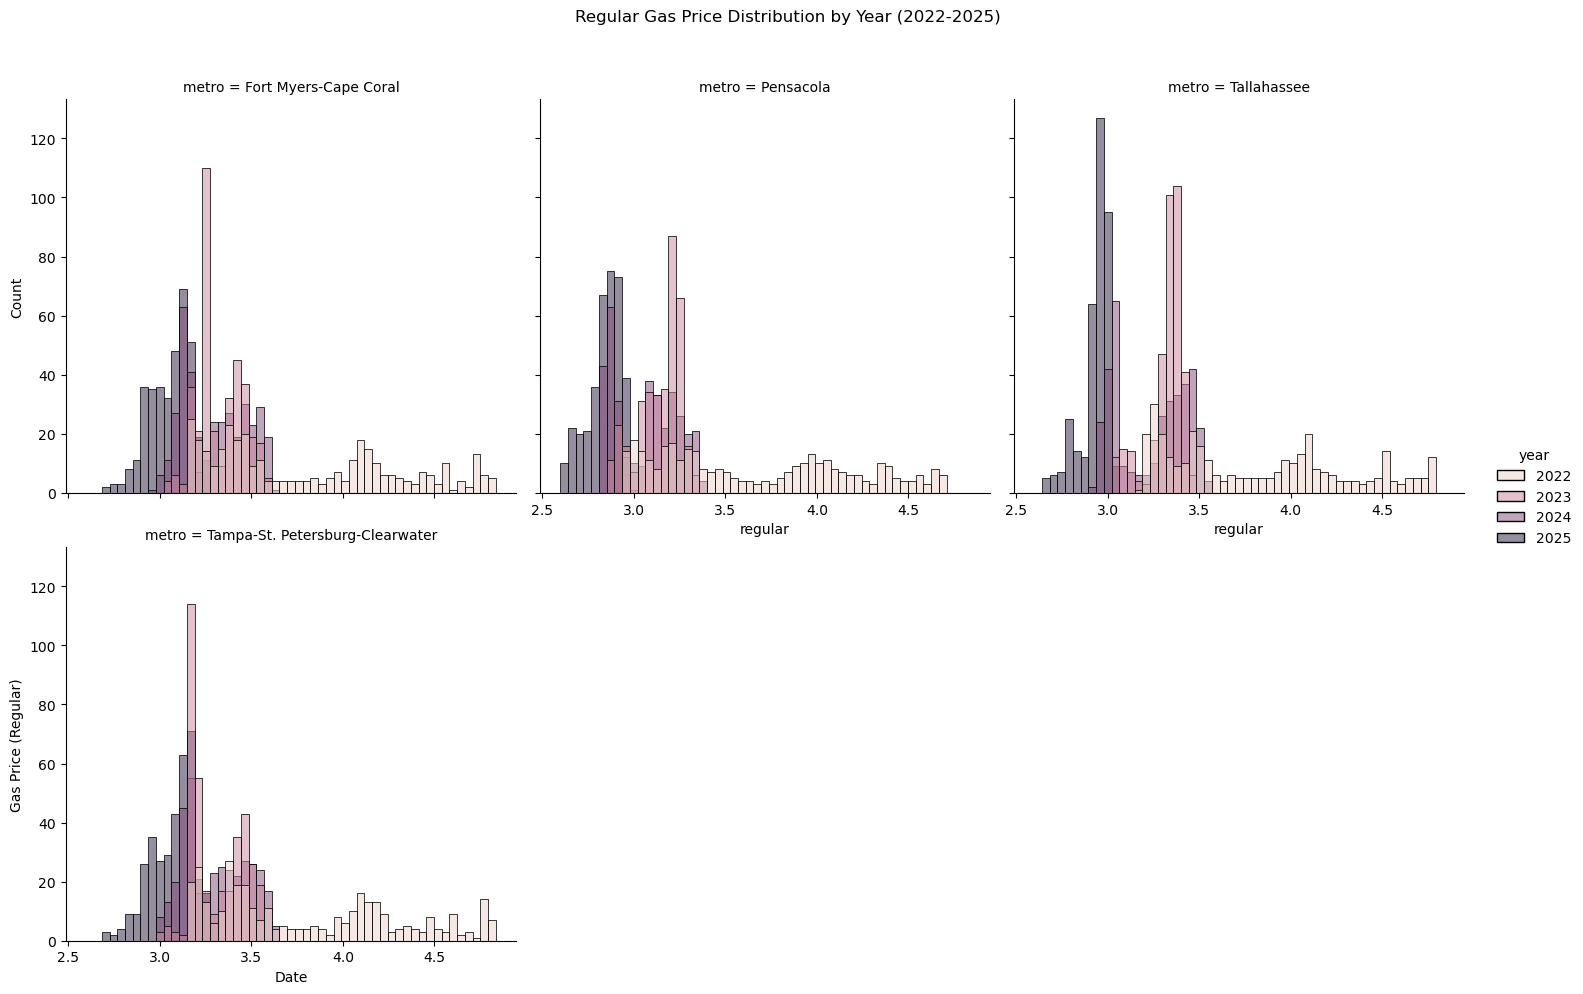

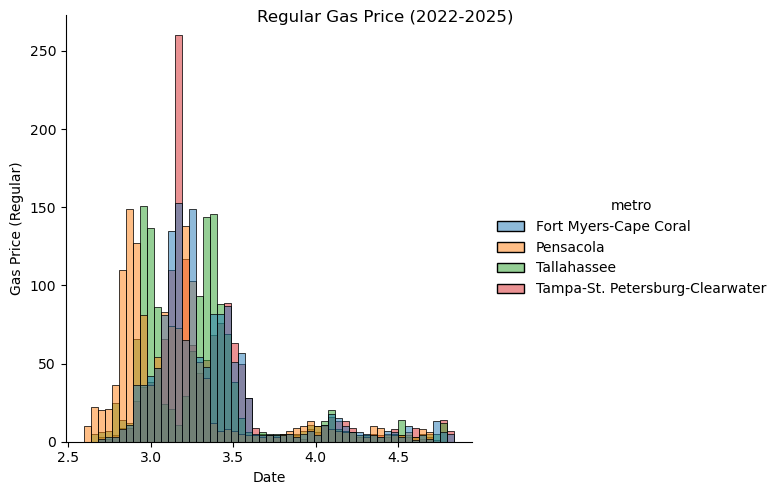

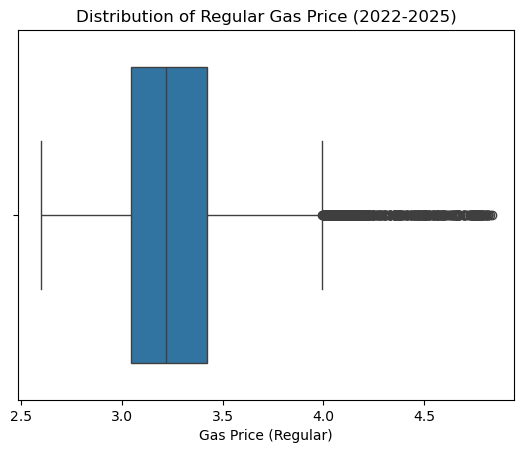

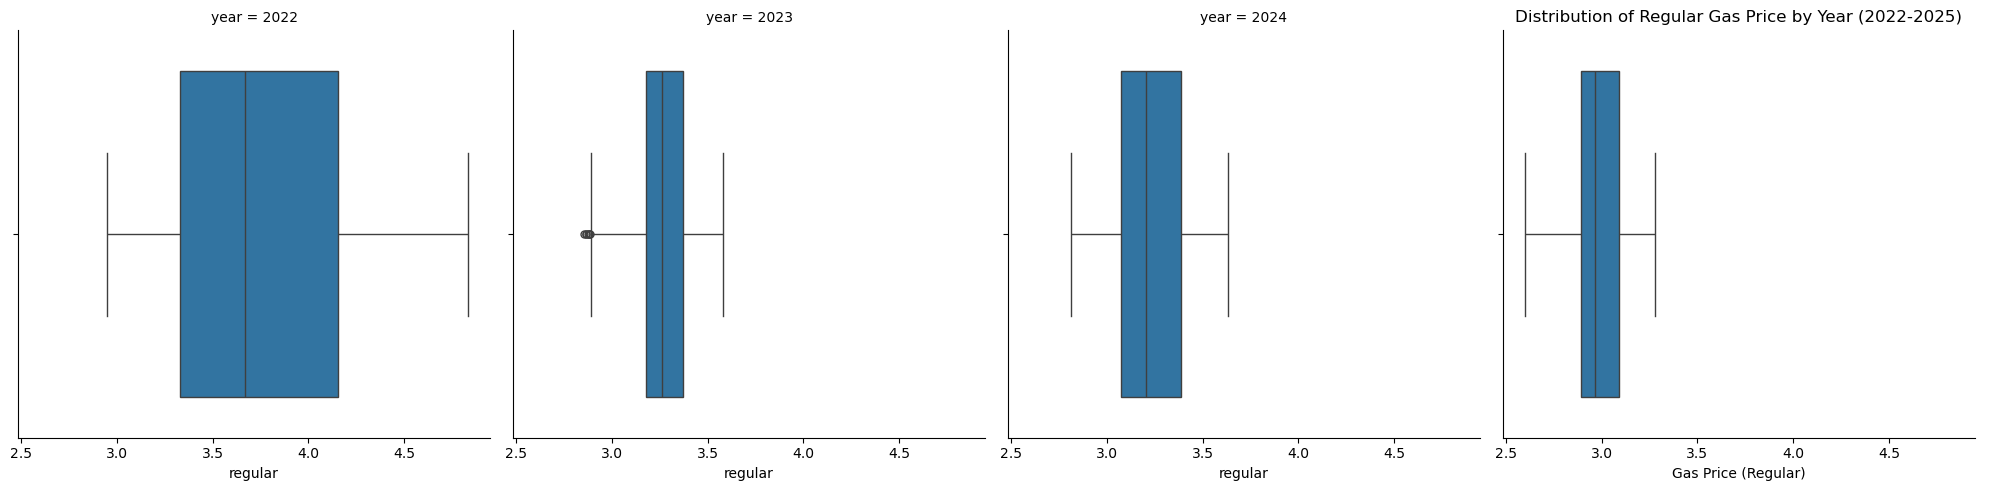

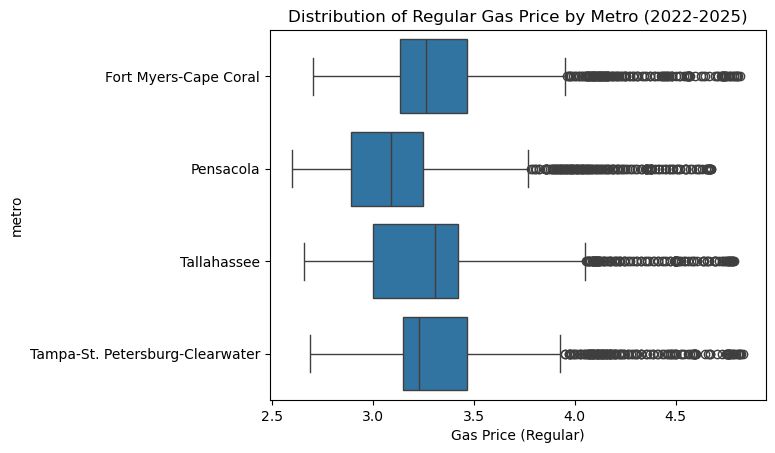

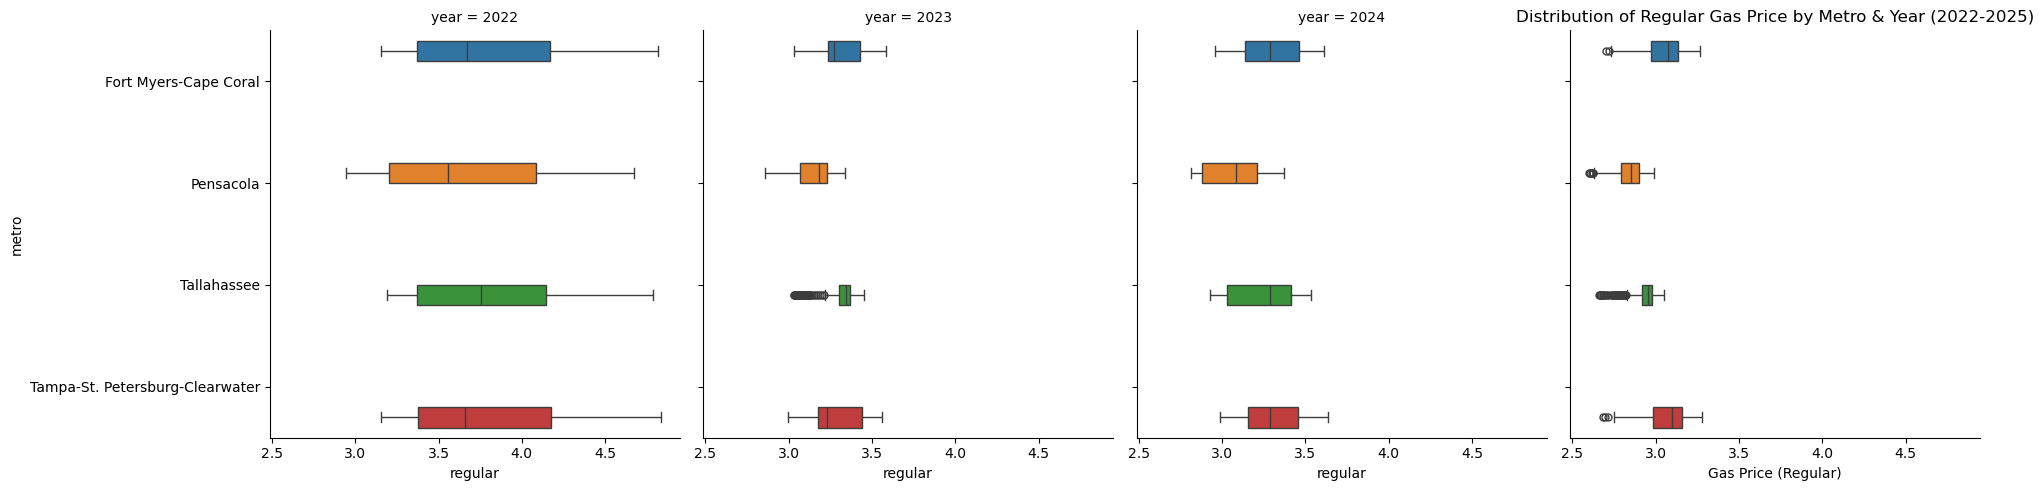

In [18]:
# Gas Overview Visuals
gas_visuals_ov(gas_data_redux, metro_all)

gas_visuals(gas_data_redux, metro_east)

gas_visuals(gas_data_redux, metro_gulf)

In [19]:
# Hurricane Tracks Visuals
from hurr_tracks_viz import *

# Season Survey
#hurr_tracks_season(hurr_data_redux)

# Single Hurricane Track
#hurr_tracks_single(hurr_data_redux, coast_pt_data)

# Compare Hurricane Tracks
#hurr_tracks_compare(hurr_data_redux, coast_pt_data)

In [20]:
# Storm Analysis
from storm_analysis import *

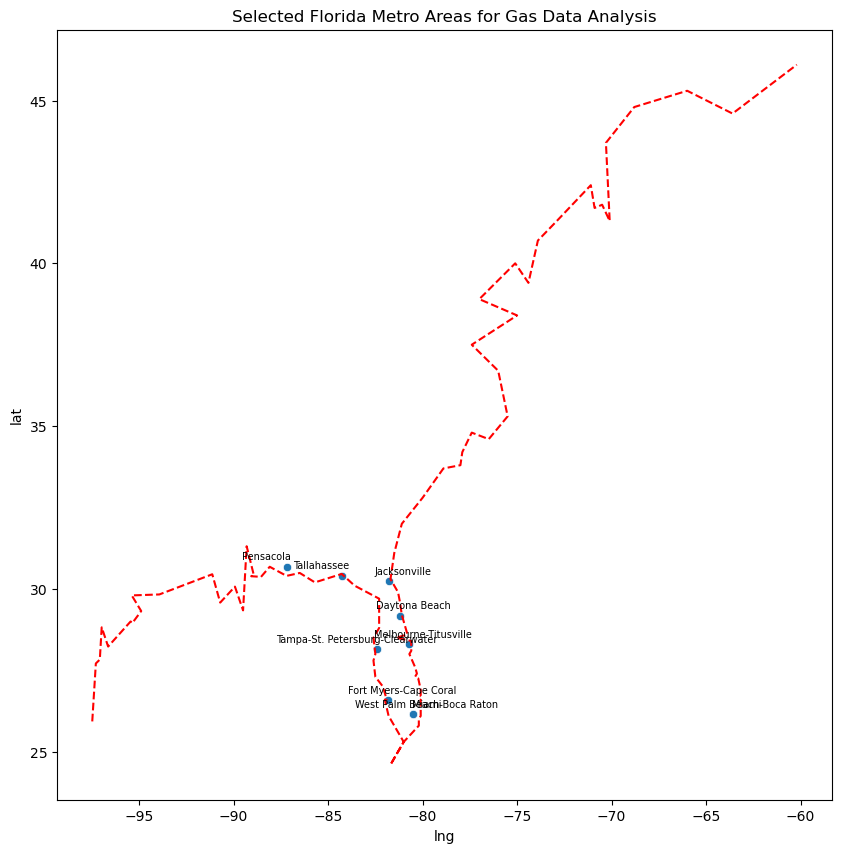

In [21]:
map_plot(metro_loc_data, metro_all, coast_pt_data)

In [22]:
hurr_data_select, gas_data_select, metro, hurr_name, hurr_seas = data_select(hurr_data_redux, hurr_sum_list, gas_data_redux)

Enter target hurricane season (year):  2023


          NAME  MAX CAT  STORM DURATION
2263   UNNAMED       -2               3
2264    ARLENE        0               3
2265      BRET        0               5
2266     CINDY        0               4
2267       DON        1              14
2268      GERT        0              16
2269     EMILY        0               6
2270  FRANKLIN        4              21
2271    HAROLD        0               2
2272    IDALIA        4              12
2273      JOSE        0               3
2274     KATIA        0              16
2275       LEE        5              13
2276    MARGOT        1              11
2277     NIGEL        2              11
2278   OPHELIA        0               3
2279  PHILIPPE        0              13
2280      RINA        0               3
2281      SEAN        0               6
2282     TAMMY        2              13
2283   UNNAMED       -1               1
2284   UNNAMED       -3               1


Enter target hurricane name:  Idalia
Enter FL region of interest: 1 - All Coast, 2 - East Coast, 3 - Gulf Coast, 4 - West Coast, 5 - Panhandle  1


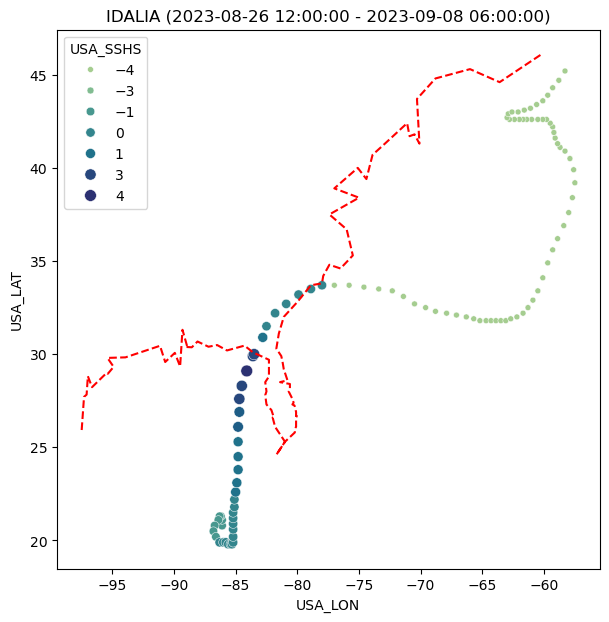

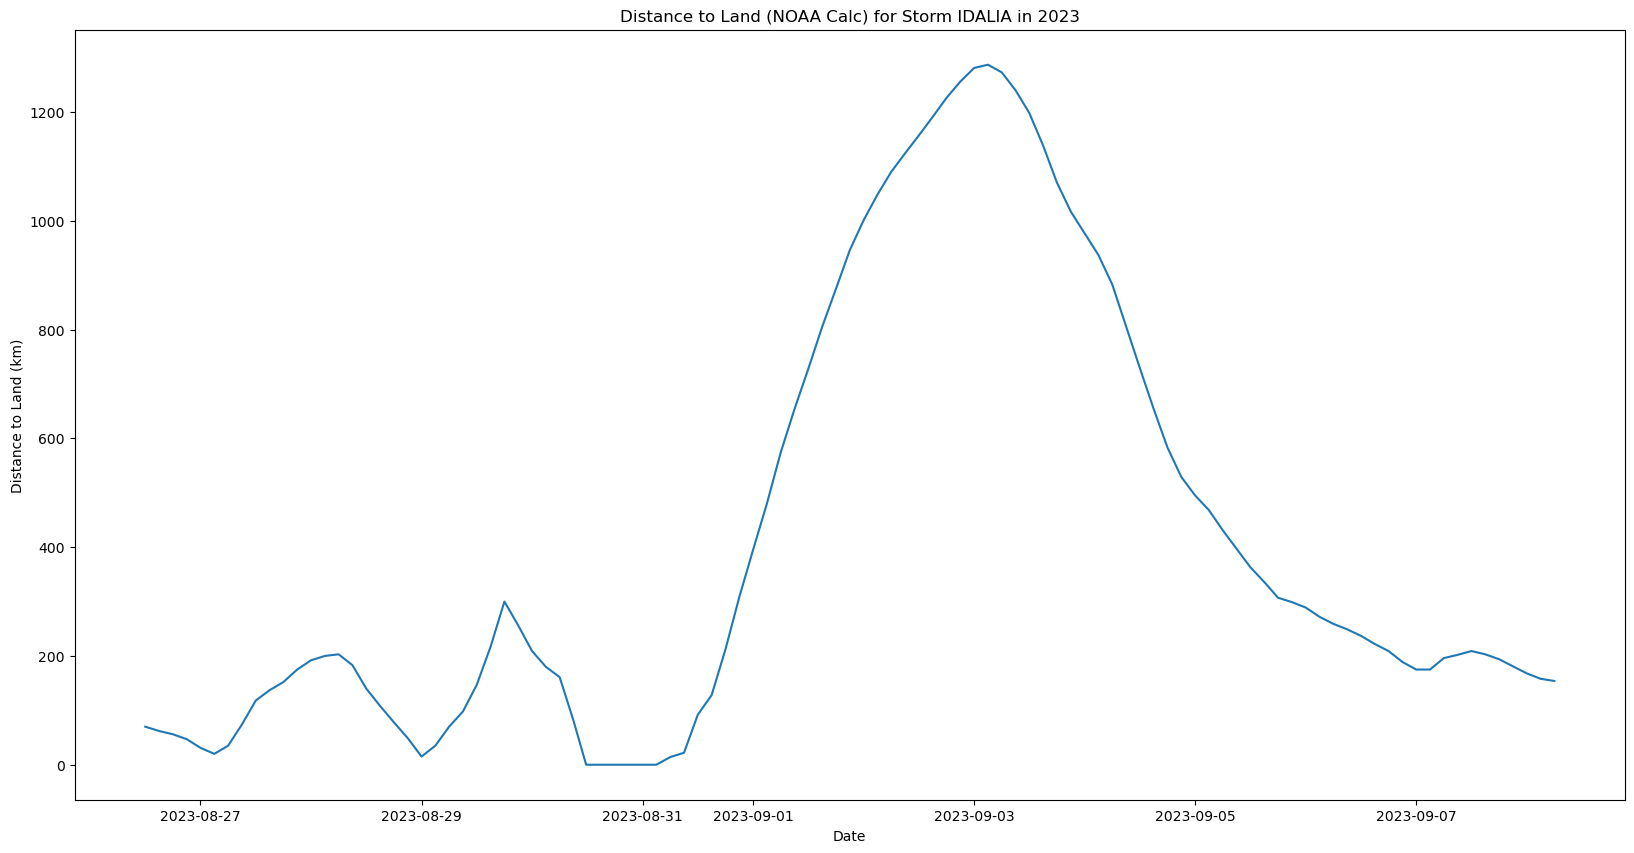

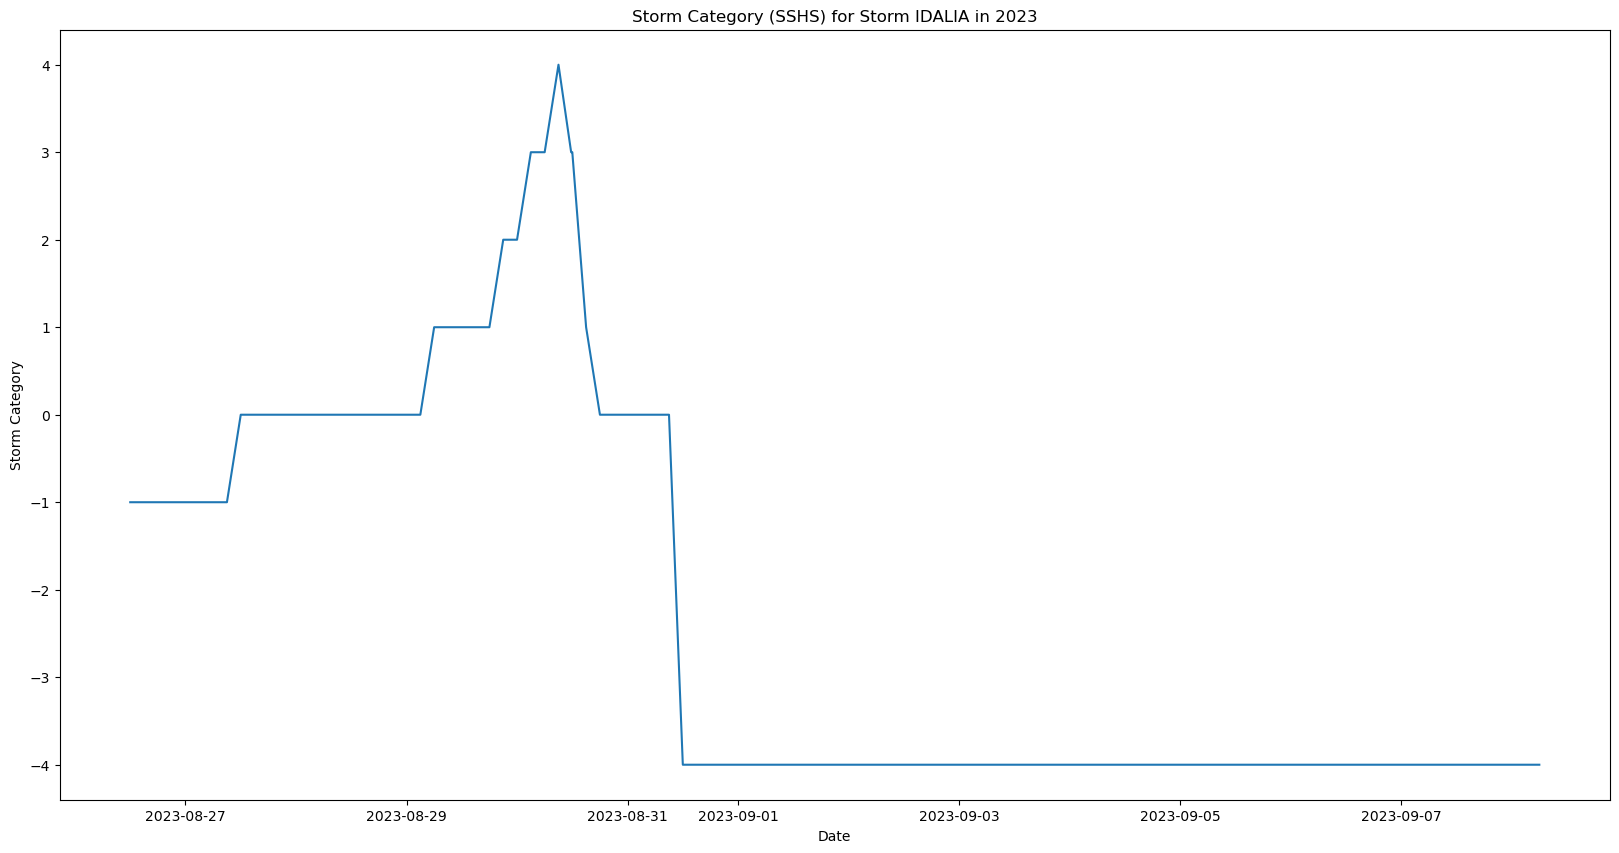

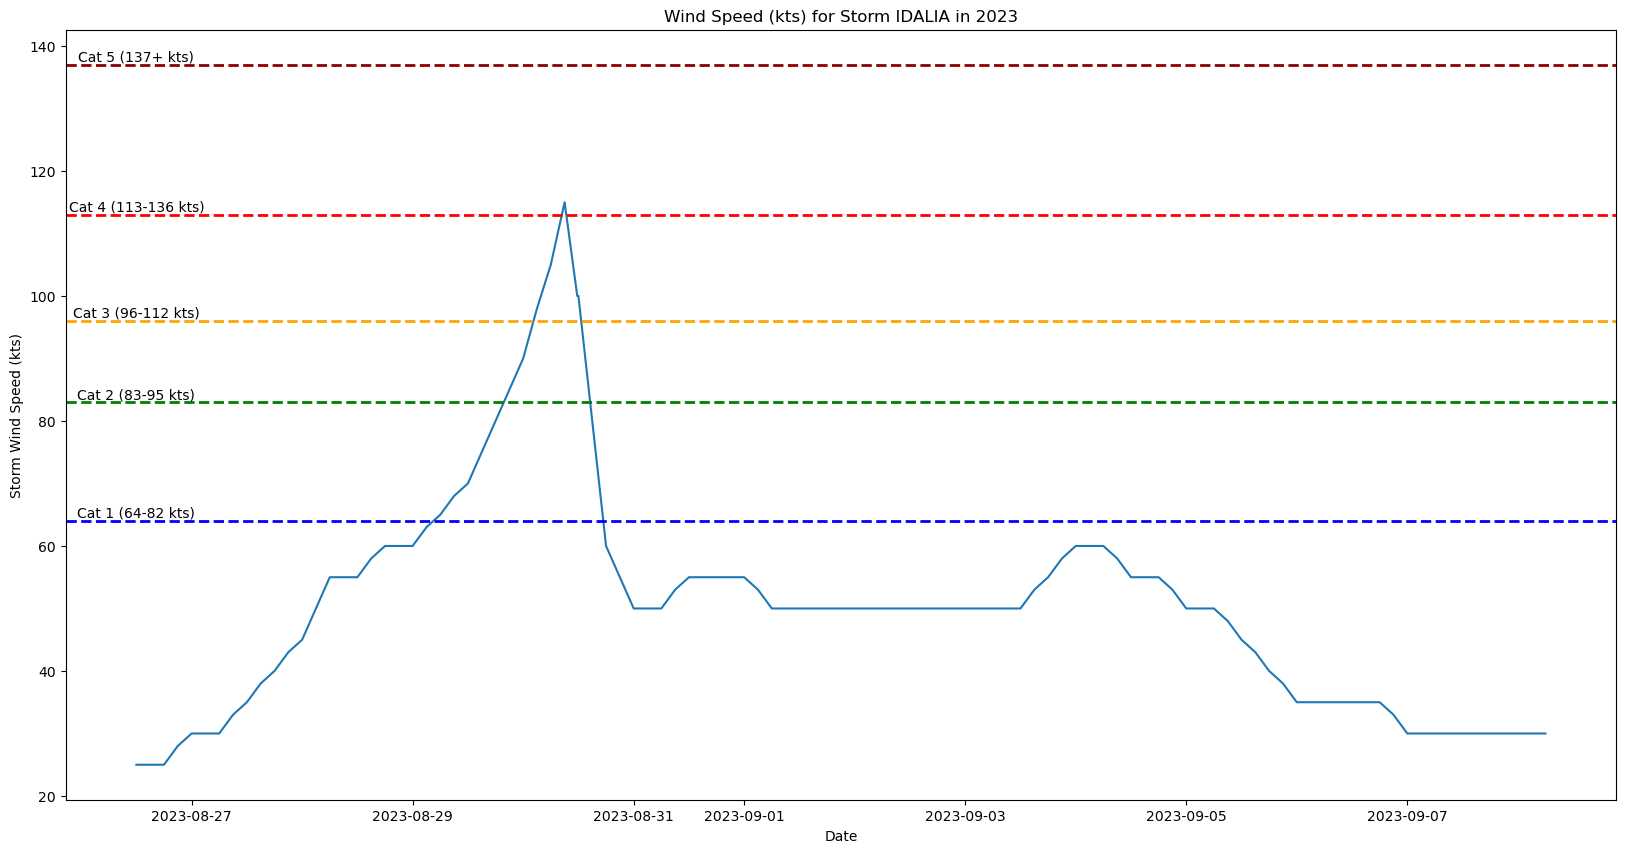

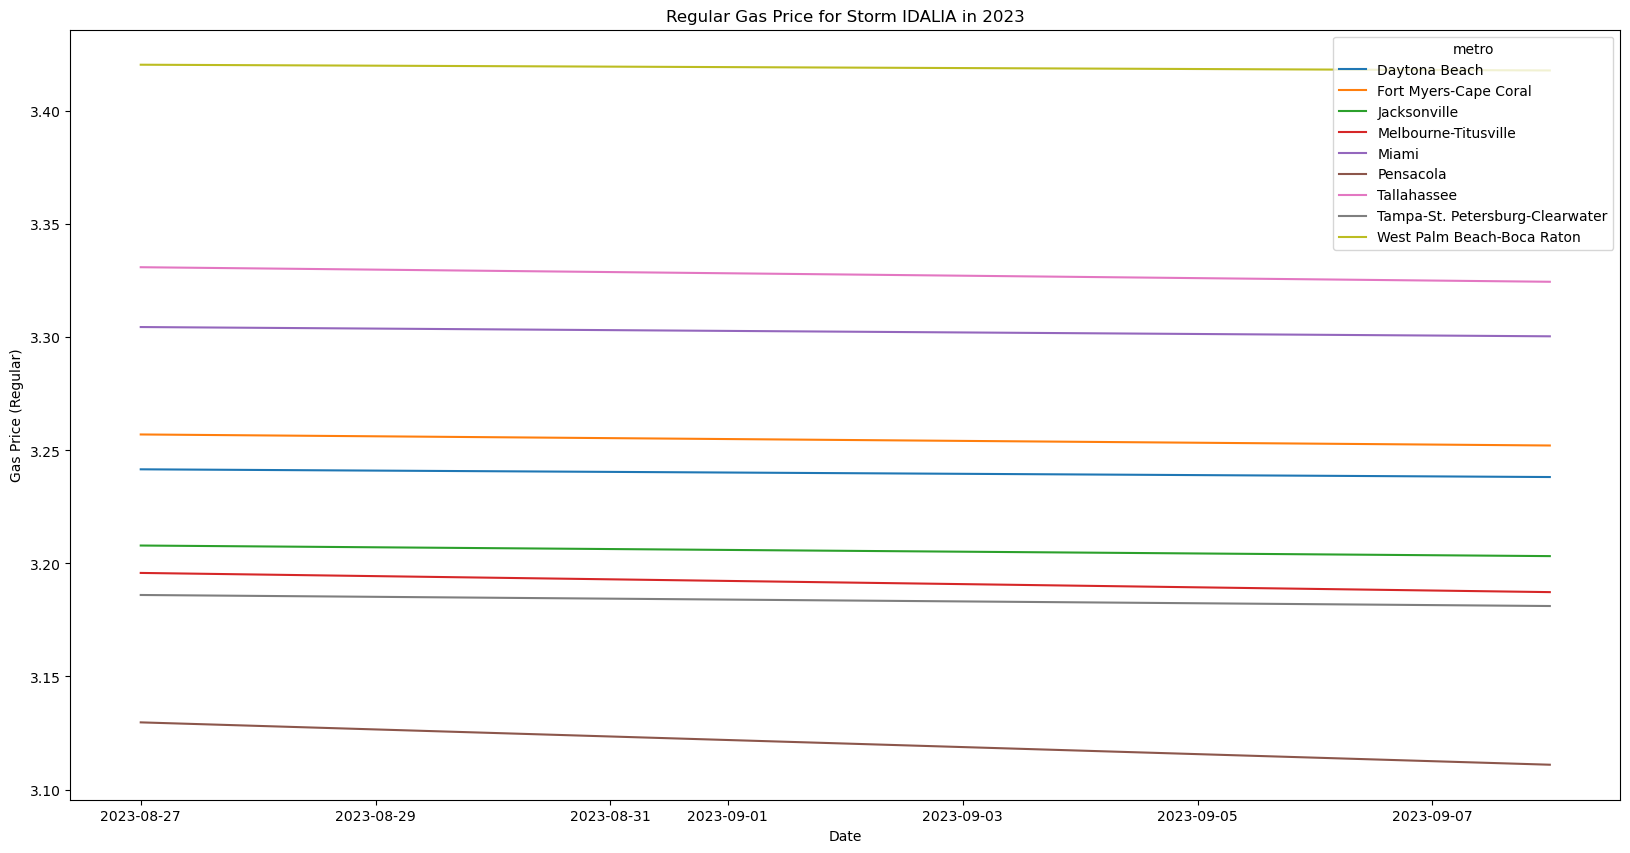

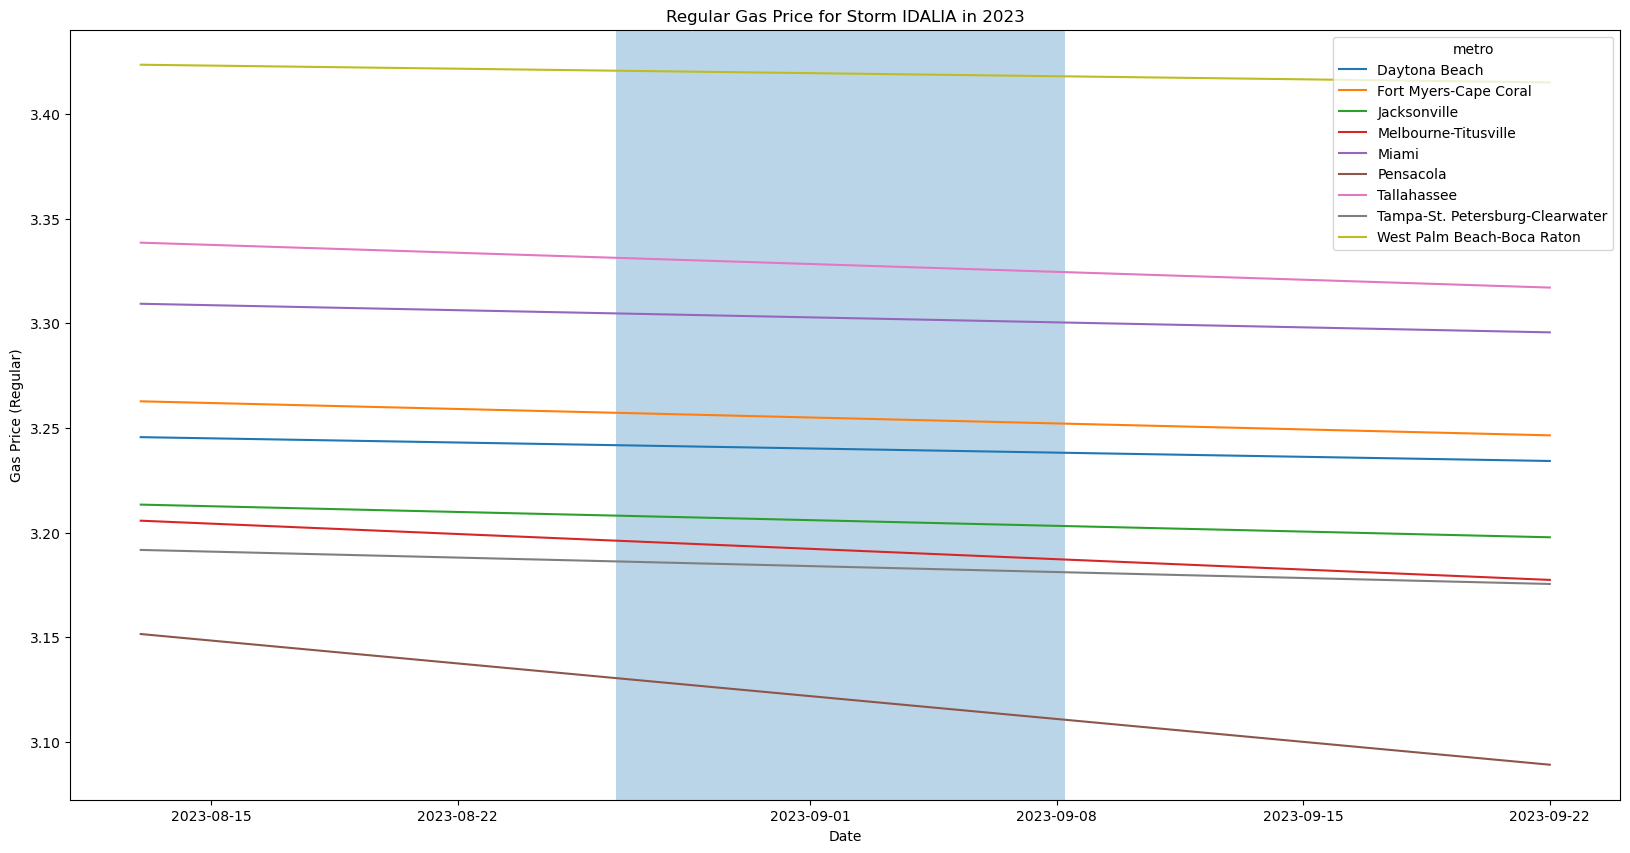

Daytona Beach
               ISO_TIME  USA_LAT  USA_LON         dist
0   2023-08-26 12:00:00     20.8    -86.1  1050.006165
1   2023-08-26 15:00:00     21.1    -86.1  1020.515580
2   2023-08-26 18:00:00     21.3    -86.2  1005.956672
3   2023-08-26 21:00:00     21.3    -86.3  1011.005864
4   2023-08-27 00:00:00     21.1    -86.4  1035.398605
..                  ...      ...      ...          ...
99  2023-09-07 18:00:00     43.6    -60.1  2467.518624
100 2023-09-07 21:00:00     43.9    -59.7  2512.764766
101 2023-09-08 00:00:00     44.3    -59.3  2563.986459
102 2023-09-08 03:00:00     44.7    -58.8  2621.678206
103 2023-09-08 06:00:00     45.2    -58.3  2685.273130

[104 rows x 4 columns]


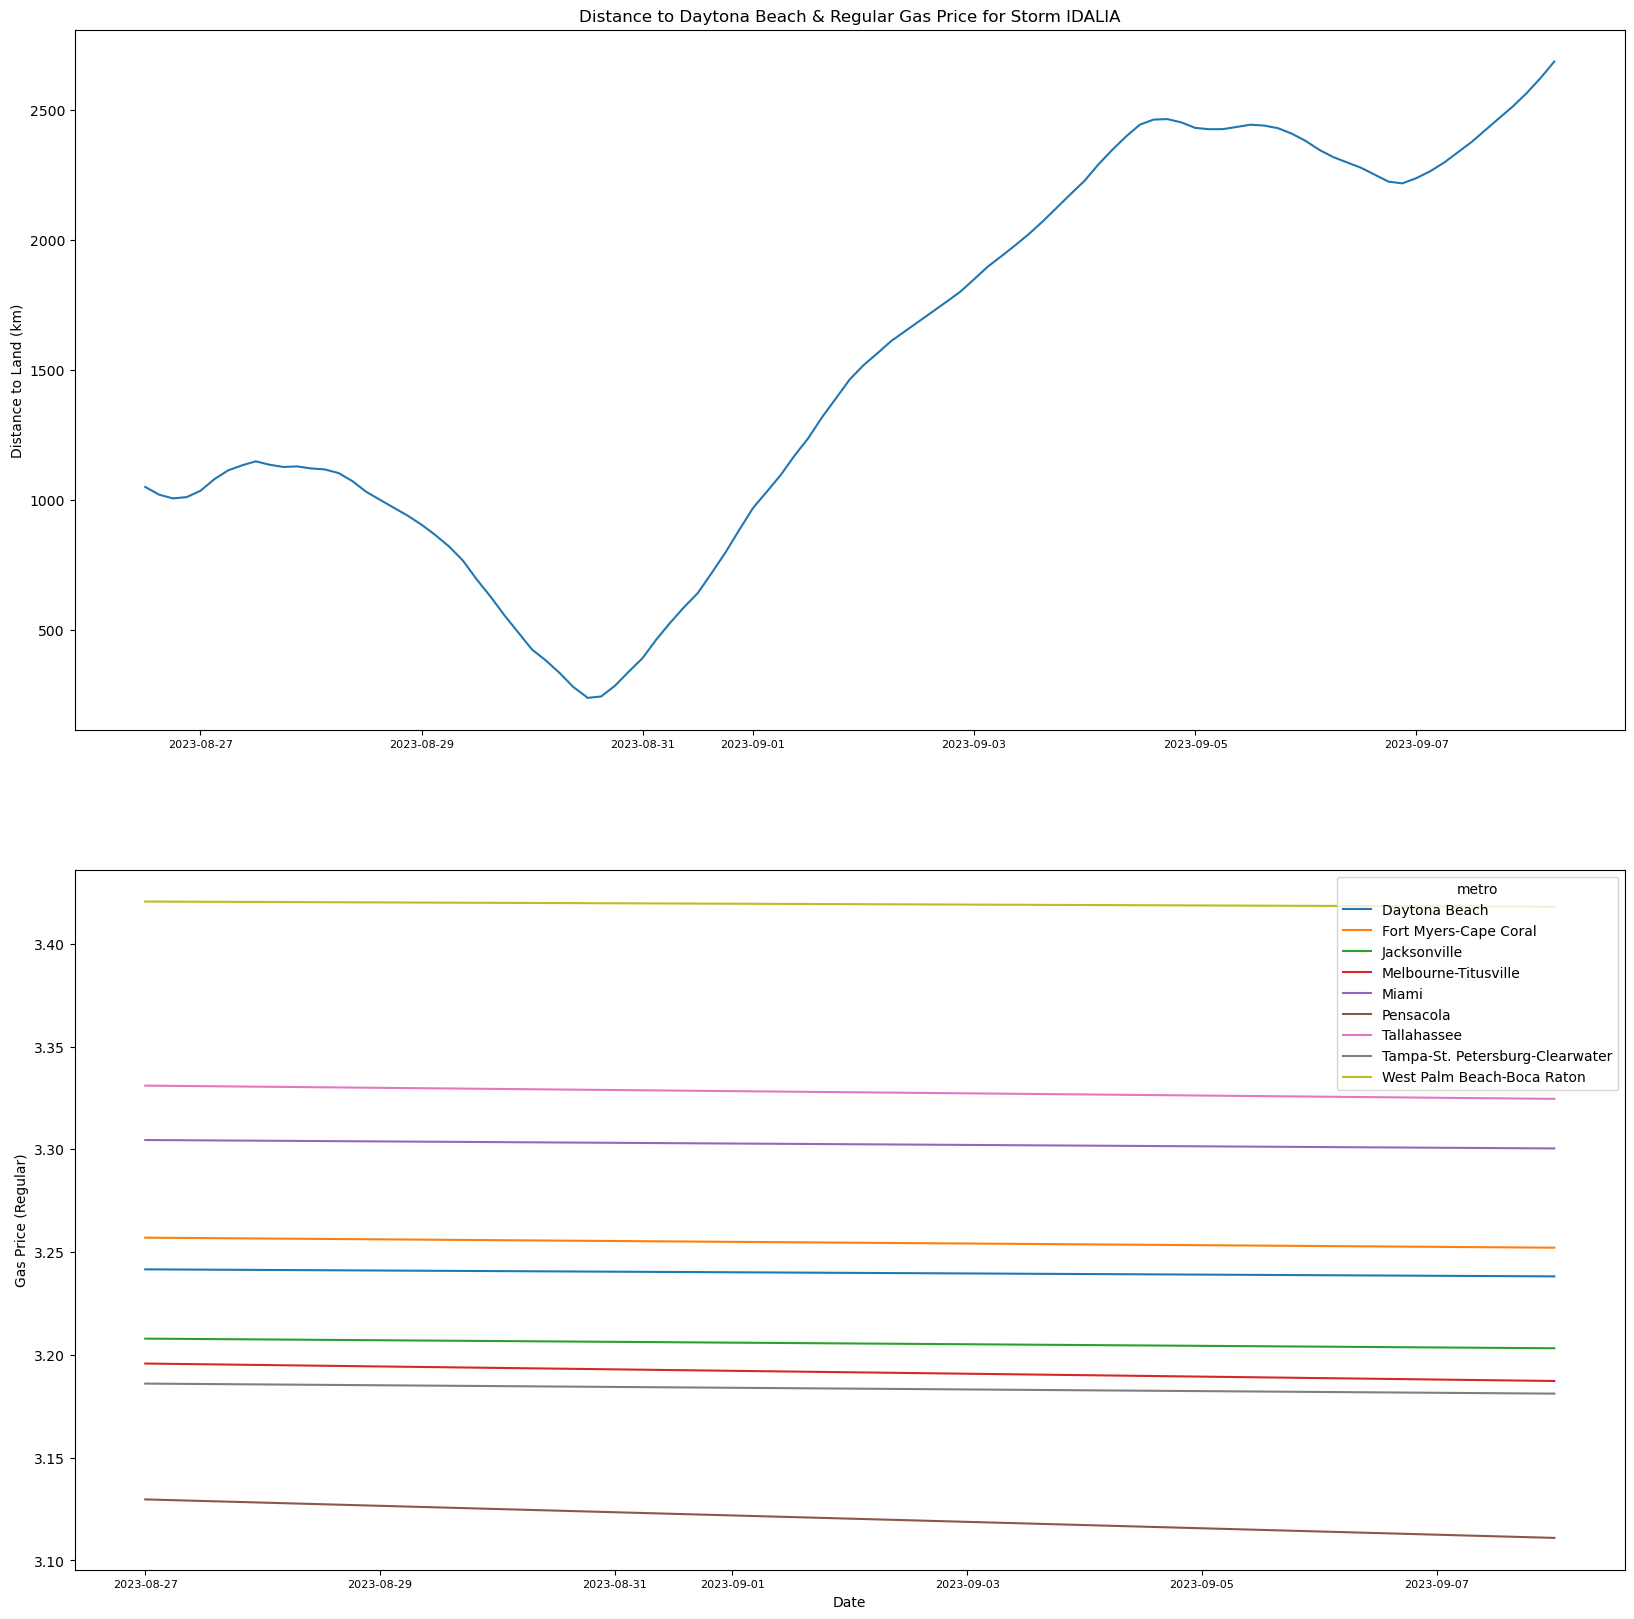

Fort Myers-Cape Coral
               ISO_TIME  USA_LAT  USA_LON         dist
0   2023-08-26 12:00:00     20.8    -86.1   773.722353
1   2023-08-26 15:00:00     21.1    -86.1   746.210147
2   2023-08-26 18:00:00     21.3    -86.2   734.241577
3   2023-08-26 21:00:00     21.3    -86.3   740.441302
4   2023-08-27 00:00:00     21.1    -86.4   764.393501
..                  ...      ...      ...          ...
99  2023-09-07 18:00:00     43.6    -60.1  2721.442181
100 2023-09-07 21:00:00     43.9    -59.7  2767.197753
101 2023-09-08 00:00:00     44.3    -59.3  2819.436584
102 2023-09-08 03:00:00     44.7    -58.8  2877.871422
103 2023-09-08 06:00:00     45.2    -58.3  2942.677982

[104 rows x 4 columns]


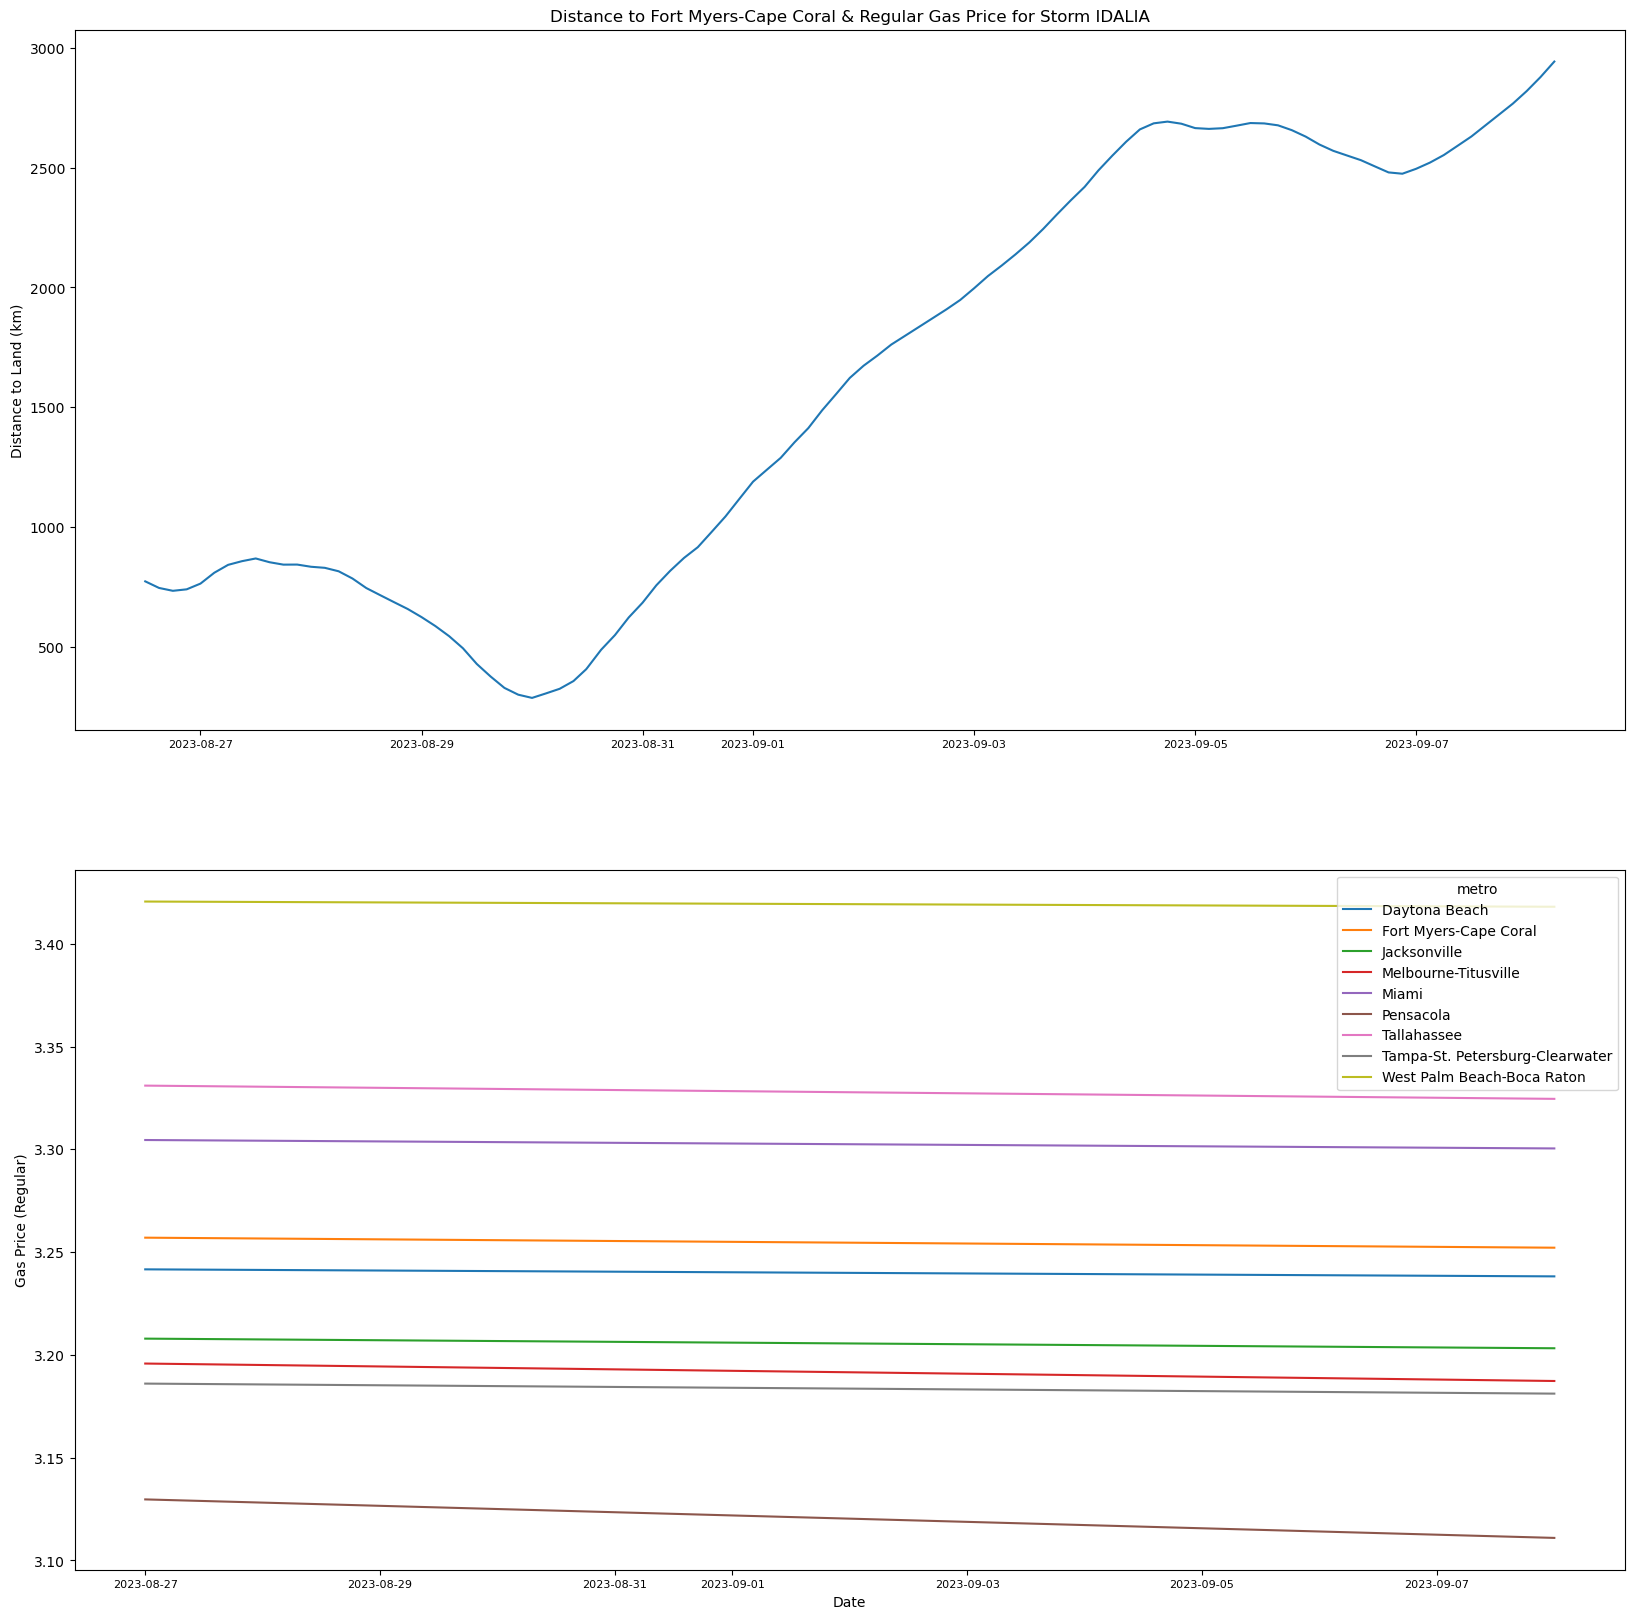

Jacksonville
               ISO_TIME  USA_LAT  USA_LON         dist
0   2023-08-26 12:00:00     20.8    -86.1  1131.218045
1   2023-08-26 15:00:00     21.1    -86.1  1100.402961
2   2023-08-26 18:00:00     21.3    -86.2  1083.975393
3   2023-08-26 21:00:00     21.3    -86.3  1088.090703
4   2023-08-27 00:00:00     21.1    -86.4  1112.539397
..                  ...      ...      ...          ...
99  2023-09-07 18:00:00     43.6    -60.1  2423.539026
100 2023-09-07 21:00:00     43.9    -59.7  2468.213757
101 2023-09-08 00:00:00     44.3    -59.3  2518.403967
102 2023-09-08 03:00:00     44.7    -58.8  2575.291263
103 2023-09-08 06:00:00     45.2    -58.3  2637.651330

[104 rows x 4 columns]


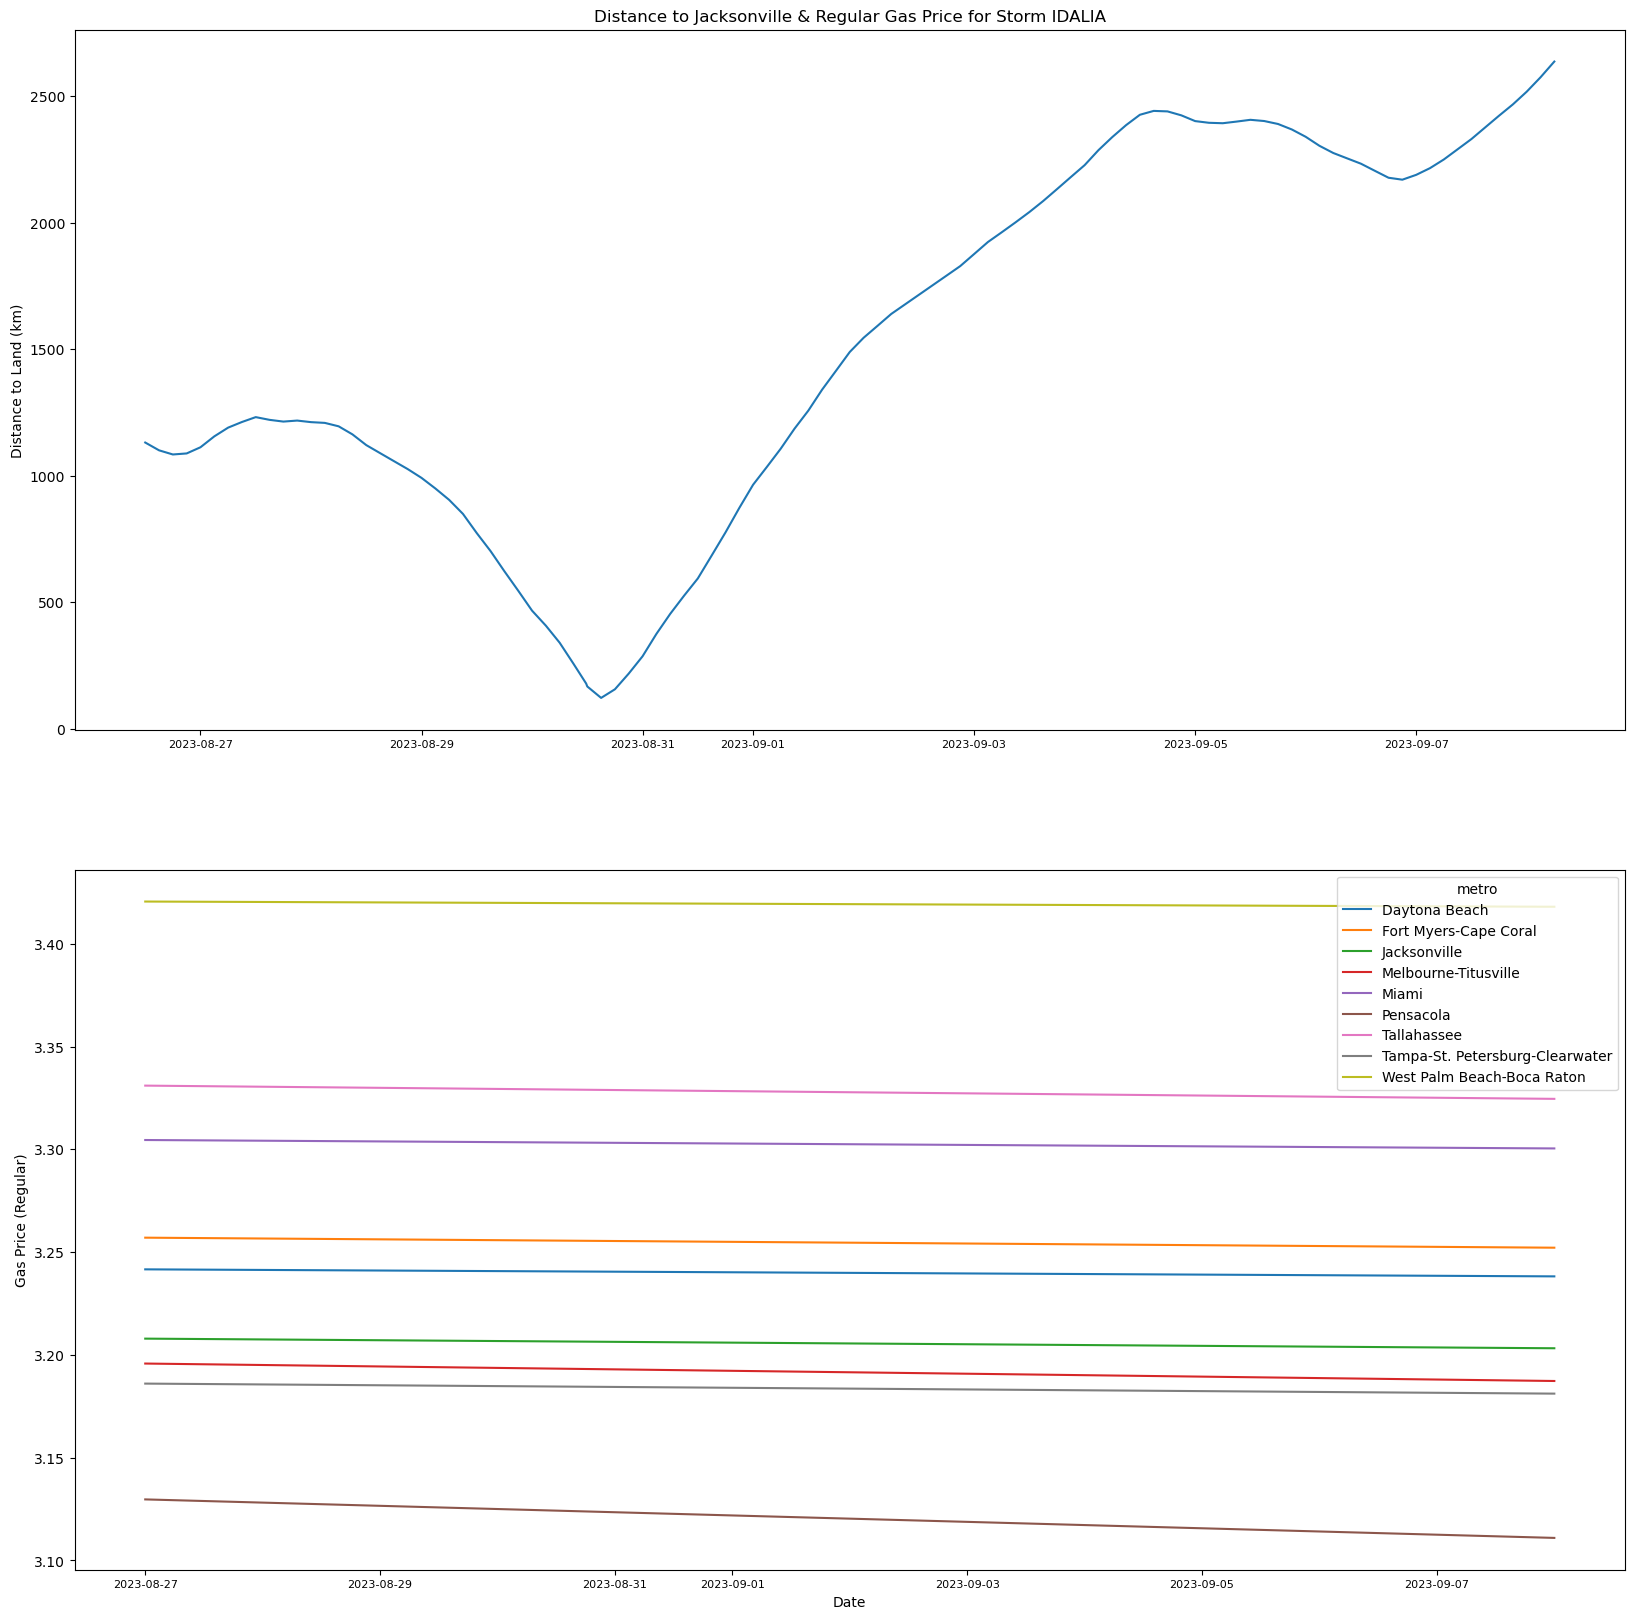

Melbourne-Titusville
               ISO_TIME  USA_LAT  USA_LON         dist
0   2023-08-26 12:00:00     20.8    -86.1   991.984547
1   2023-08-26 15:00:00     21.1    -86.1   964.024211
2   2023-08-26 18:00:00     21.3    -86.2   951.397510
3   2023-08-26 21:00:00     21.3    -86.3   957.295219
4   2023-08-27 00:00:00     21.1    -86.4   981.409100
..                  ...      ...      ...          ...
99  2023-09-07 18:00:00     43.6    -60.1  2506.667591
100 2023-09-07 21:00:00     43.9    -59.7  2552.292286
101 2023-09-08 00:00:00     44.3    -59.3  2604.259602
102 2023-09-08 03:00:00     44.7    -58.8  2662.505238
103 2023-09-08 06:00:00     45.2    -58.3  2726.999857

[104 rows x 4 columns]


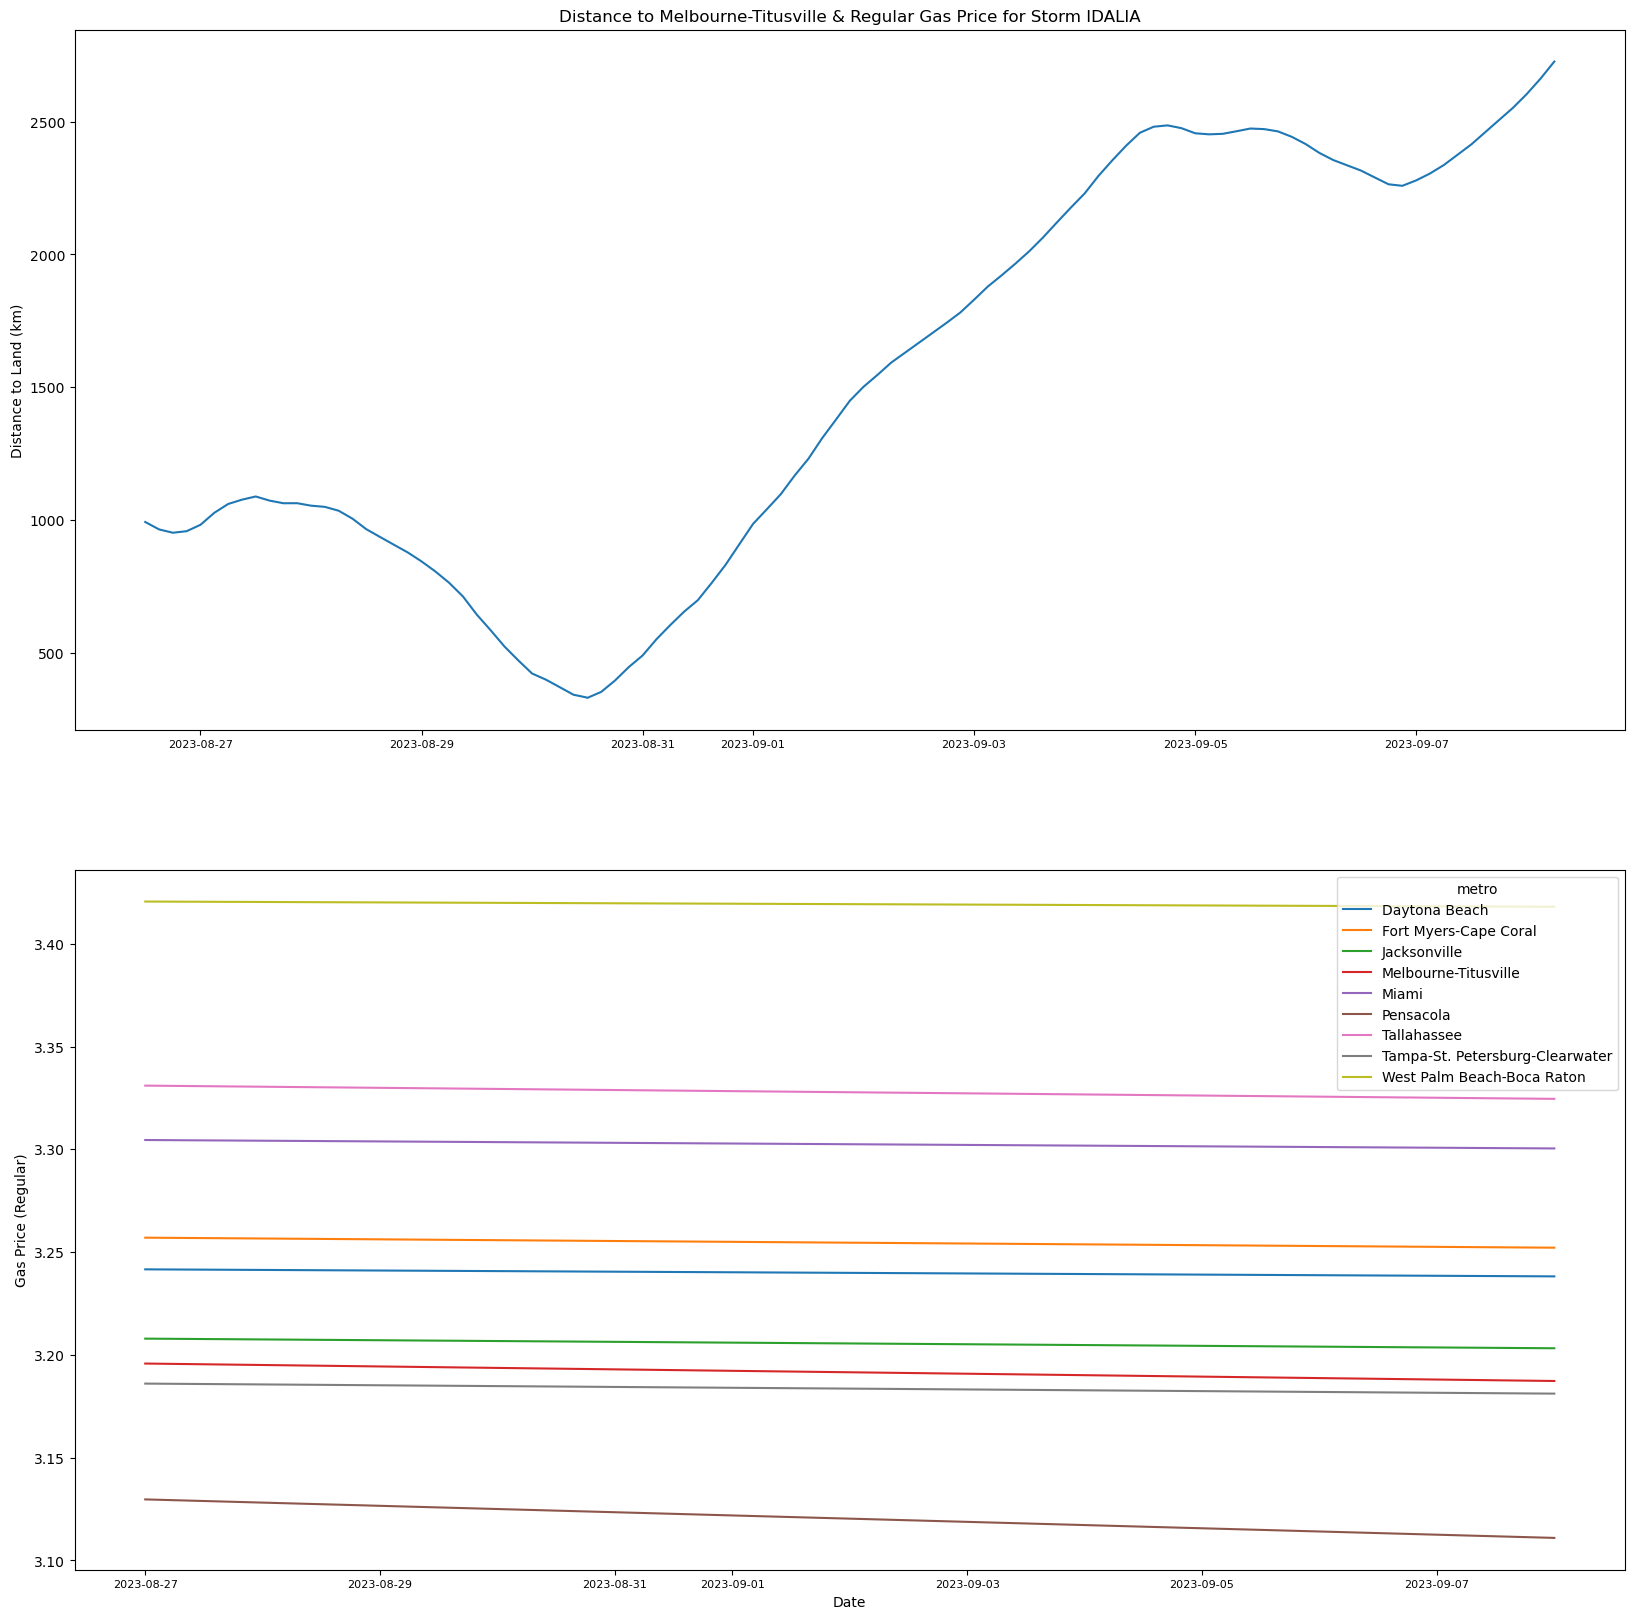

Miami
               ISO_TIME  USA_LAT  USA_LON         dist
0   2023-08-26 12:00:00     20.8    -86.1   823.536950
1   2023-08-26 15:00:00     21.1    -86.1   799.500099
2   2023-08-26 18:00:00     21.3    -86.2   791.287338
3   2023-08-26 21:00:00     21.3    -86.3   798.789711
4   2023-08-27 00:00:00     21.1    -86.4   821.608375
..                  ...      ...      ...          ...
99  2023-09-07 18:00:00     43.6    -60.1  2673.264197
100 2023-09-07 21:00:00     43.9    -59.7  2719.334648
101 2023-09-08 00:00:00     44.3    -59.3  2772.322721
102 2023-09-08 03:00:00     44.7    -58.8  2831.266540
103 2023-09-08 06:00:00     45.2    -58.3  2897.002086

[104 rows x 4 columns]


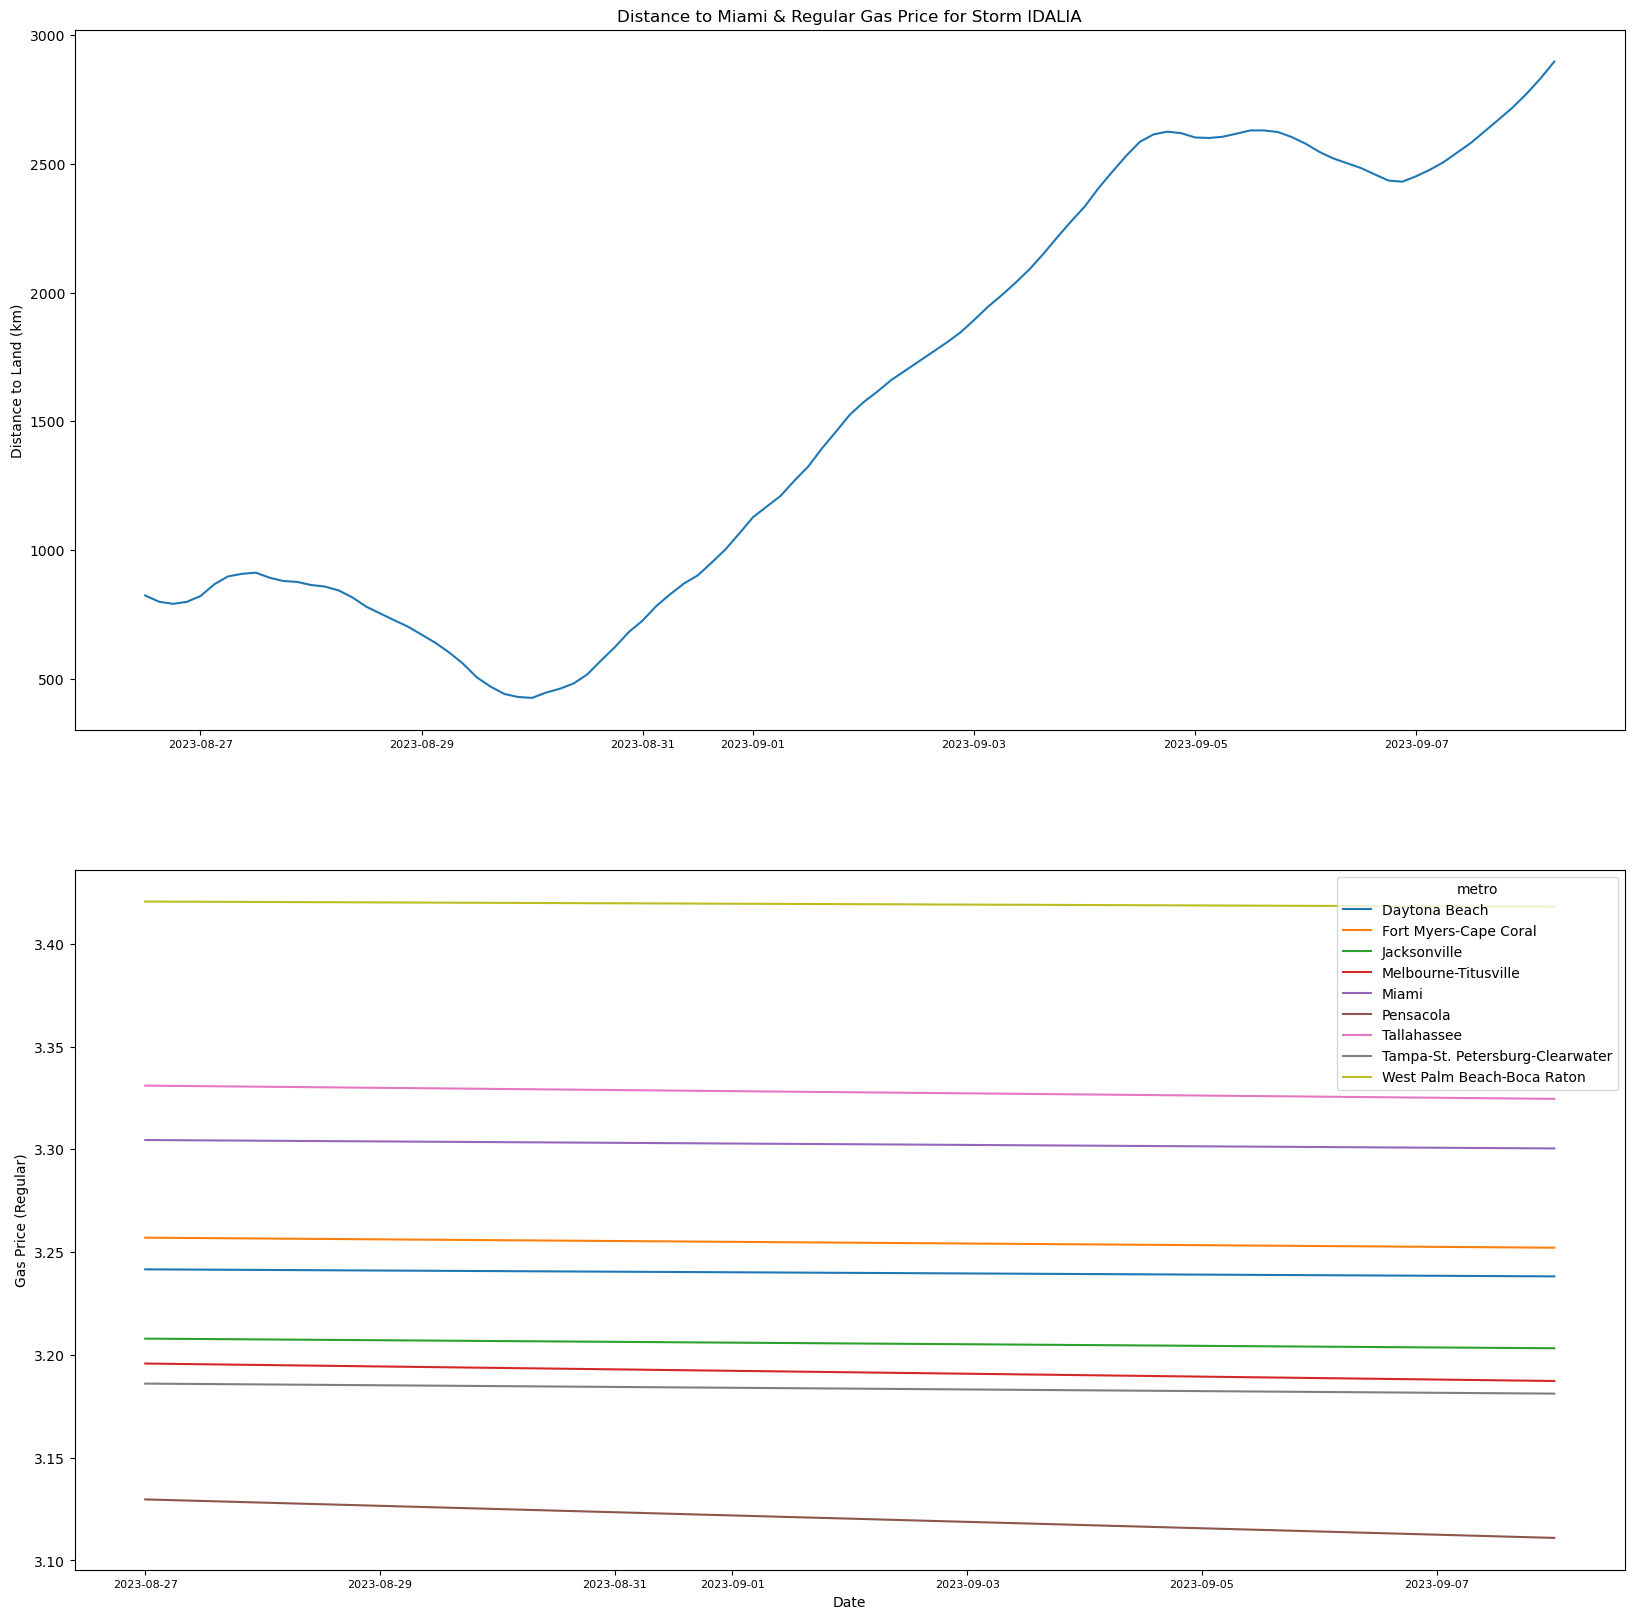

Pensacola
               ISO_TIME  USA_LAT  USA_LON         dist
0   2023-08-26 12:00:00     20.8    -86.1  1100.542516
1   2023-08-26 15:00:00     21.1    -86.1  1067.474090
2   2023-08-26 18:00:00     21.3    -86.2  1044.471362
3   2023-08-26 21:00:00     21.3    -86.3  1043.604596
4   2023-08-27 00:00:00     21.1    -86.4  1064.923920
..                  ...      ...      ...          ...
99  2023-09-07 18:00:00     43.6    -60.1  2779.398658
100 2023-09-07 21:00:00     43.9    -59.7  2821.756054
101 2023-09-08 00:00:00     44.3    -59.3  2868.191597
102 2023-09-08 03:00:00     44.7    -58.8  2921.882125
103 2023-09-08 06:00:00     45.2    -58.3  2979.655151

[104 rows x 4 columns]


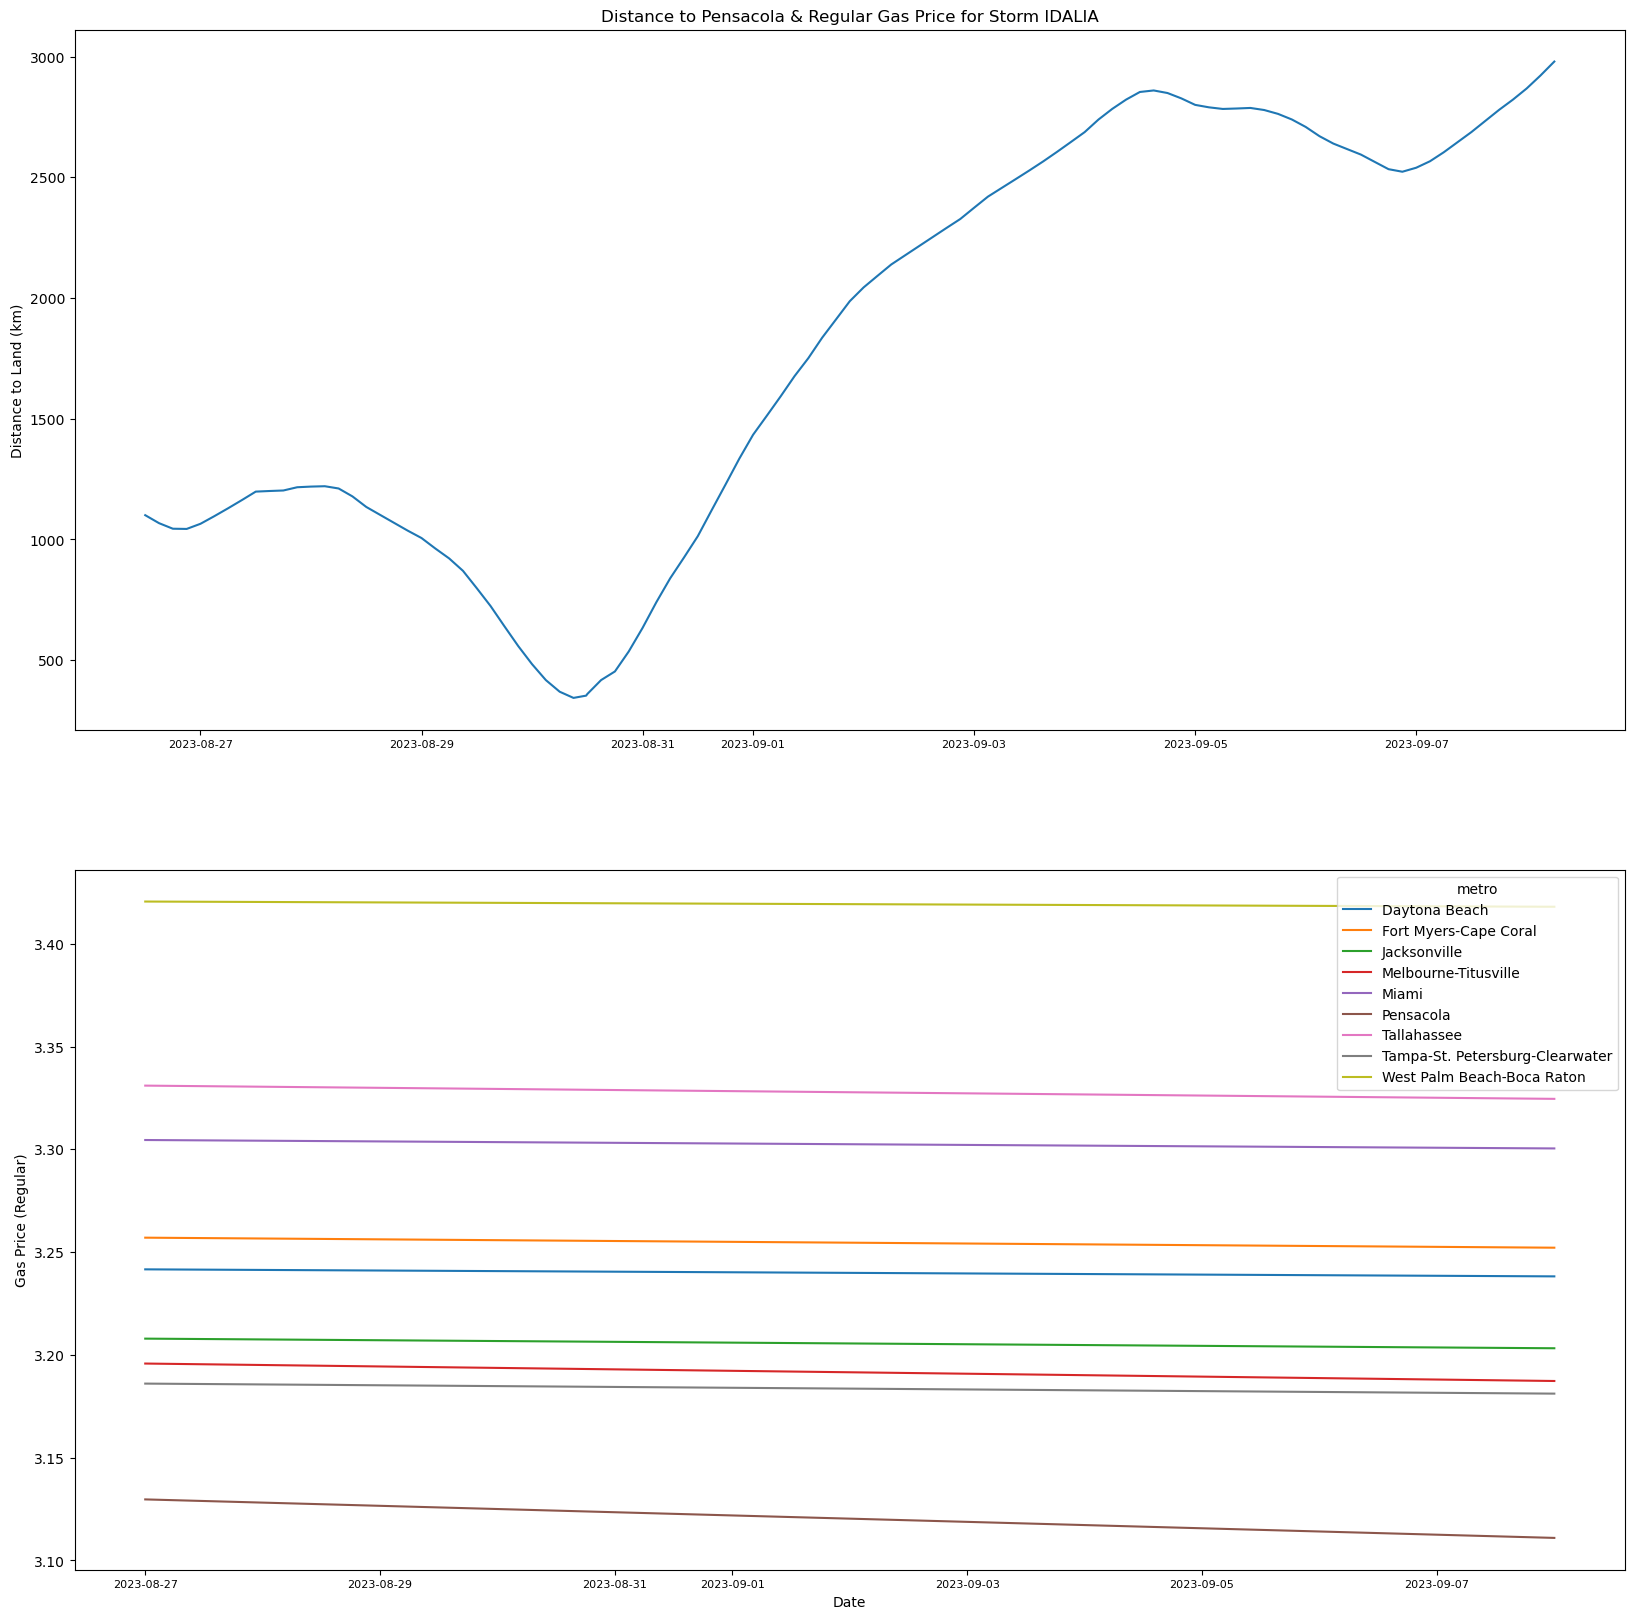

Tallahassee
               ISO_TIME  USA_LAT  USA_LON         dist
0   2023-08-26 12:00:00     20.8    -86.1  1079.501491
1   2023-08-26 15:00:00     21.1    -86.1  1046.740174
2   2023-08-26 18:00:00     21.3    -86.2  1026.733813
3   2023-08-26 21:00:00     21.3    -86.3  1028.647015
4   2023-08-27 00:00:00     21.1    -86.4  1052.368833
..                  ...      ...      ...          ...
99  2023-09-07 18:00:00     43.6    -60.1  2588.051484
100 2023-09-07 21:00:00     43.9    -59.7  2631.727574
101 2023-09-08 00:00:00     44.3    -59.3  2680.238831
102 2023-09-08 03:00:00     44.7    -58.8  2735.734242
103 2023-09-08 06:00:00     45.2    -58.3  2796.046219

[104 rows x 4 columns]


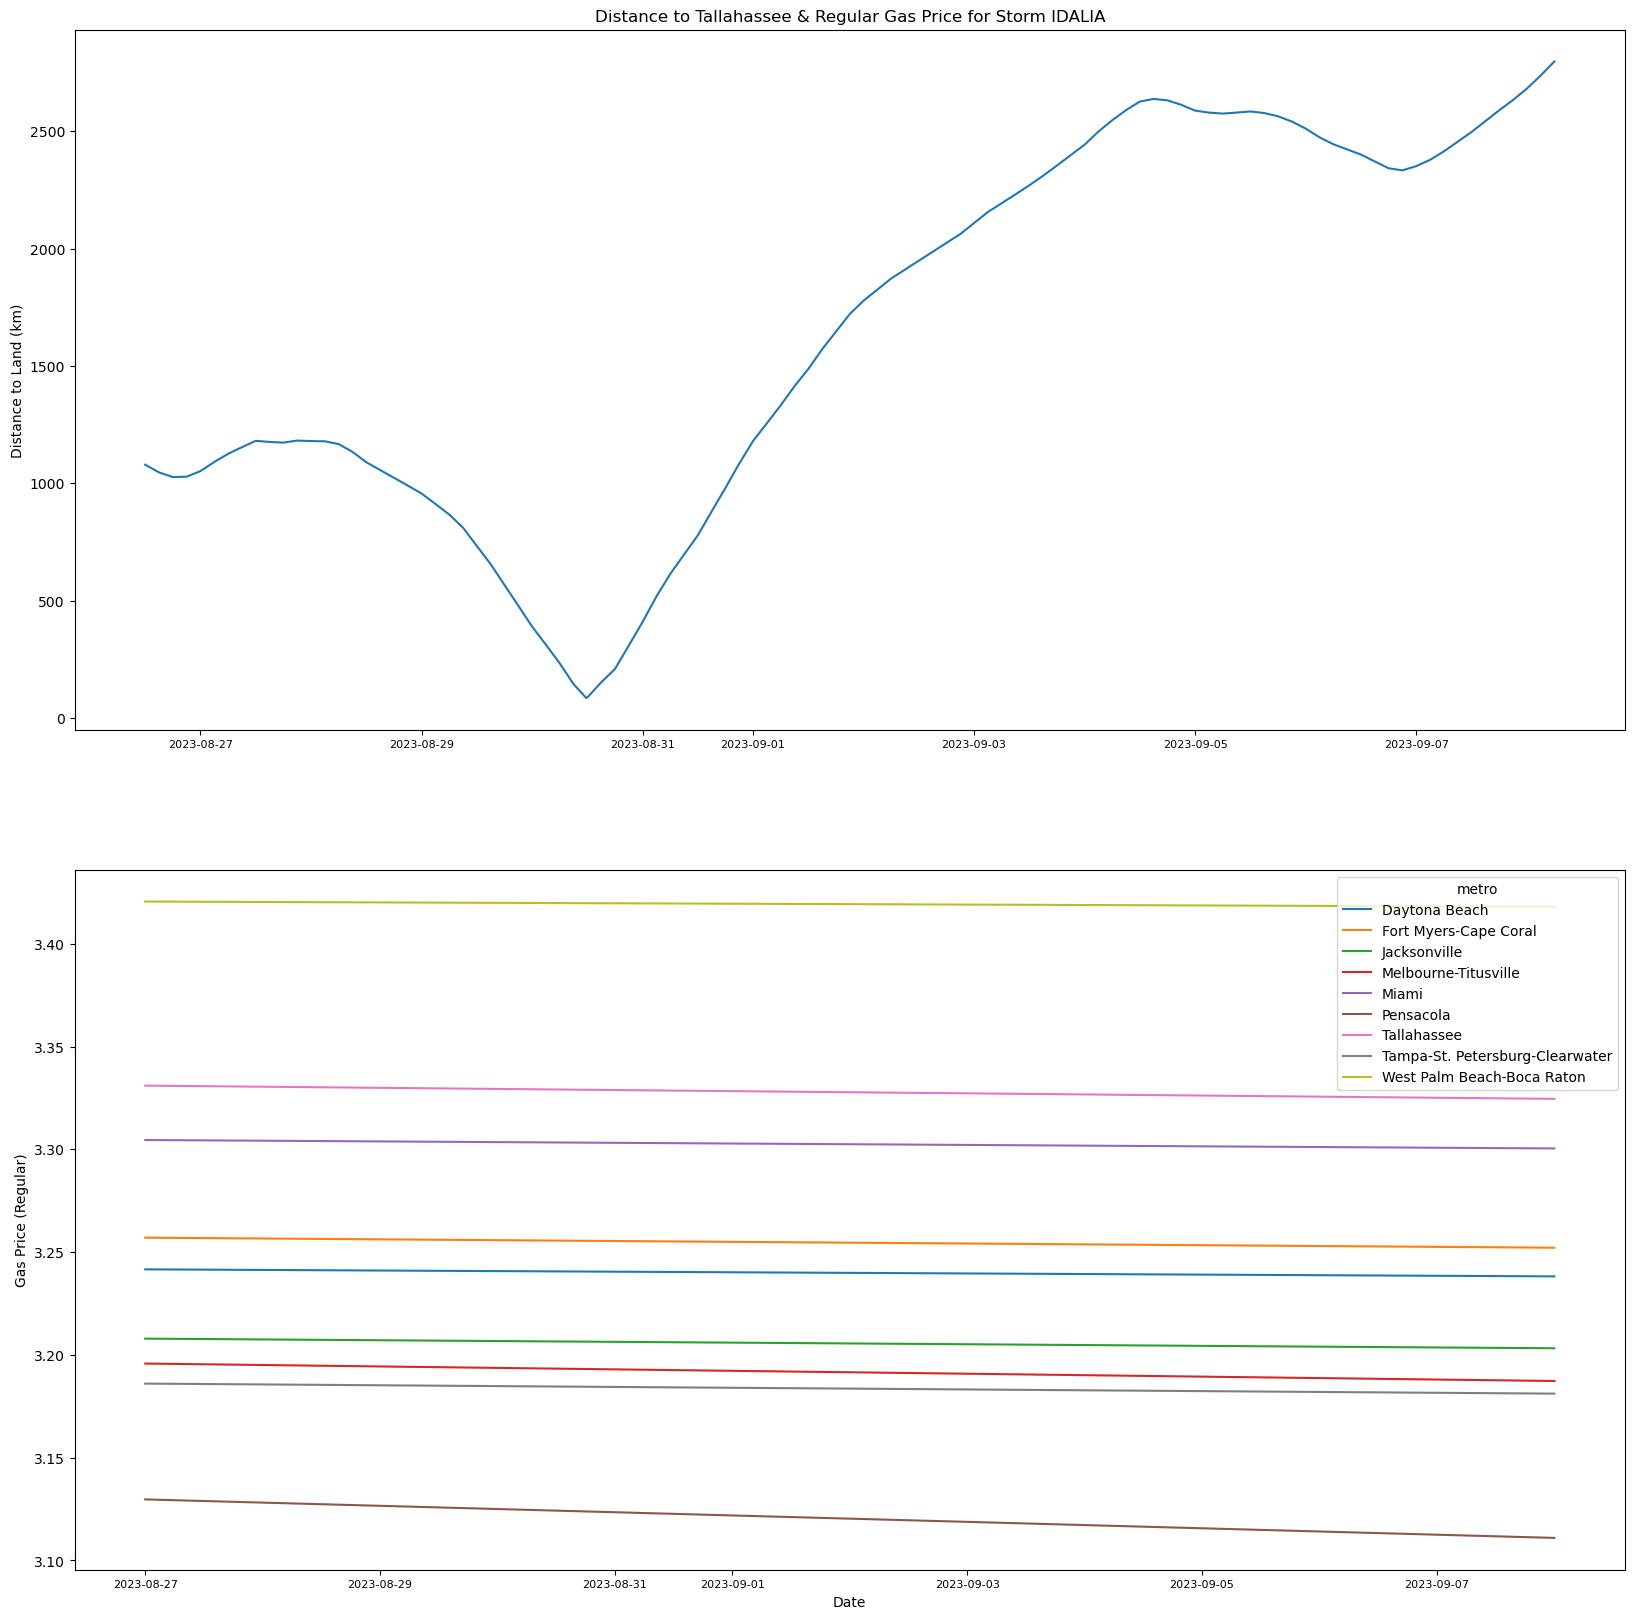

Tampa-St. Petersburg-Clearwater
               ISO_TIME  USA_LAT  USA_LON         dist
0   2023-08-26 12:00:00     20.8    -86.1   896.370874
1   2023-08-26 15:00:00     21.1    -86.1   866.120140
2   2023-08-26 18:00:00     21.3    -86.2   850.584414
3   2023-08-26 21:00:00     21.3    -86.3   855.189326
4   2023-08-27 00:00:00     21.1    -86.4   879.638555
..                  ...      ...      ...          ...
99  2023-09-07 18:00:00     43.6    -60.1  2629.303191
100 2023-09-07 21:00:00     43.9    -59.7  2674.524177
101 2023-09-08 00:00:00     44.3    -59.3  2725.691079
102 2023-09-08 03:00:00     44.7    -58.8  2783.334504
103 2023-09-08 06:00:00     45.2    -58.3  2846.841503

[104 rows x 4 columns]


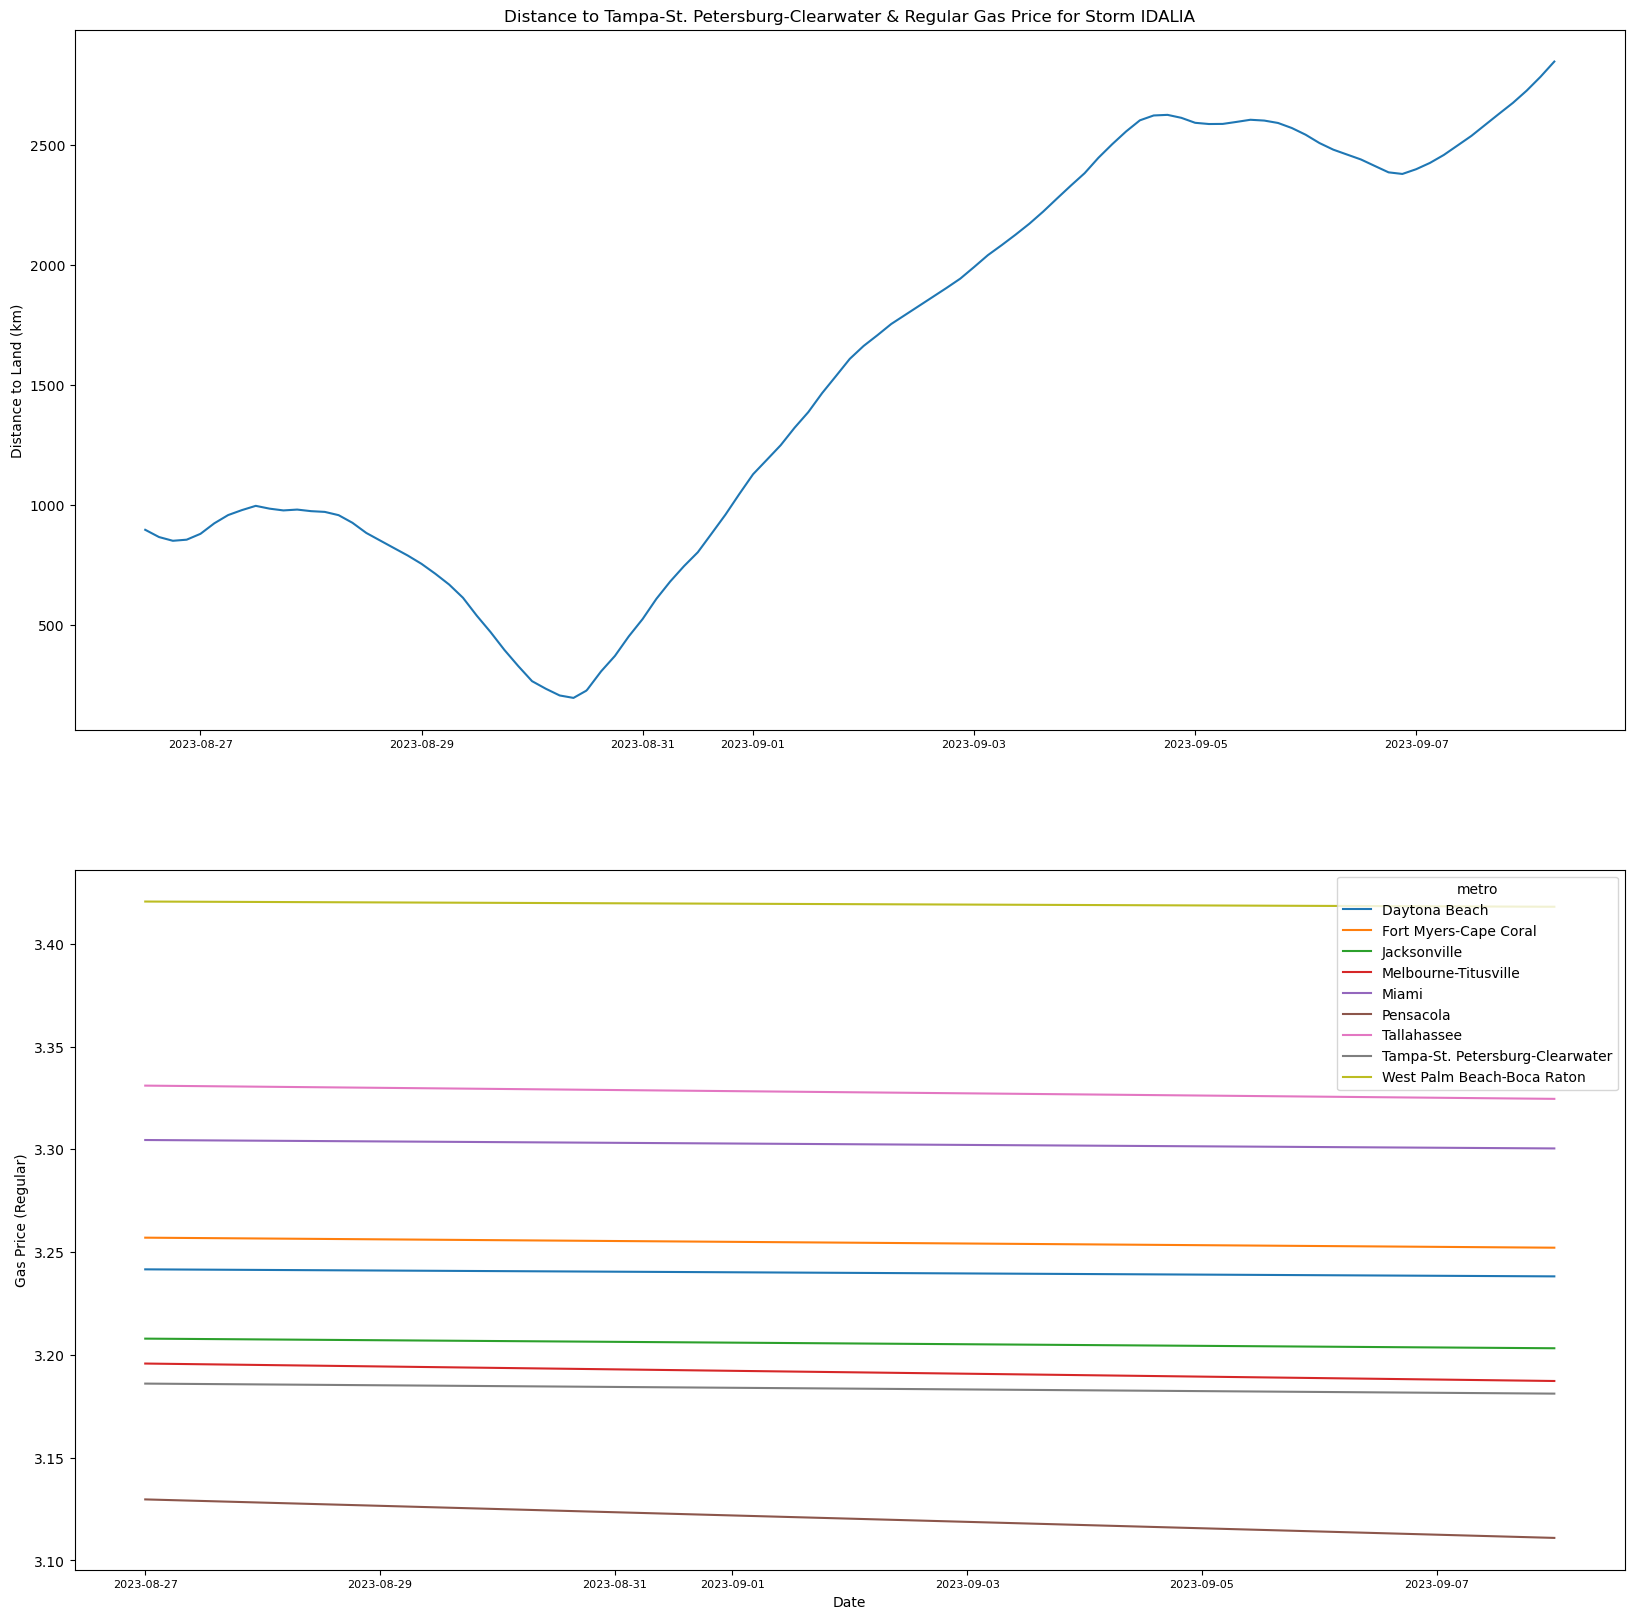

West Palm Beach-Boca Raton
               ISO_TIME  USA_LAT  USA_LON         dist
0   2023-08-26 12:00:00     20.8    -86.1   823.536950
1   2023-08-26 15:00:00     21.1    -86.1   799.500099
2   2023-08-26 18:00:00     21.3    -86.2   791.287338
3   2023-08-26 21:00:00     21.3    -86.3   798.789711
4   2023-08-27 00:00:00     21.1    -86.4   821.608375
..                  ...      ...      ...          ...
99  2023-09-07 18:00:00     43.6    -60.1  2673.264197
100 2023-09-07 21:00:00     43.9    -59.7  2719.334648
101 2023-09-08 00:00:00     44.3    -59.3  2772.322721
102 2023-09-08 03:00:00     44.7    -58.8  2831.266540
103 2023-09-08 06:00:00     45.2    -58.3  2897.002086

[104 rows x 4 columns]


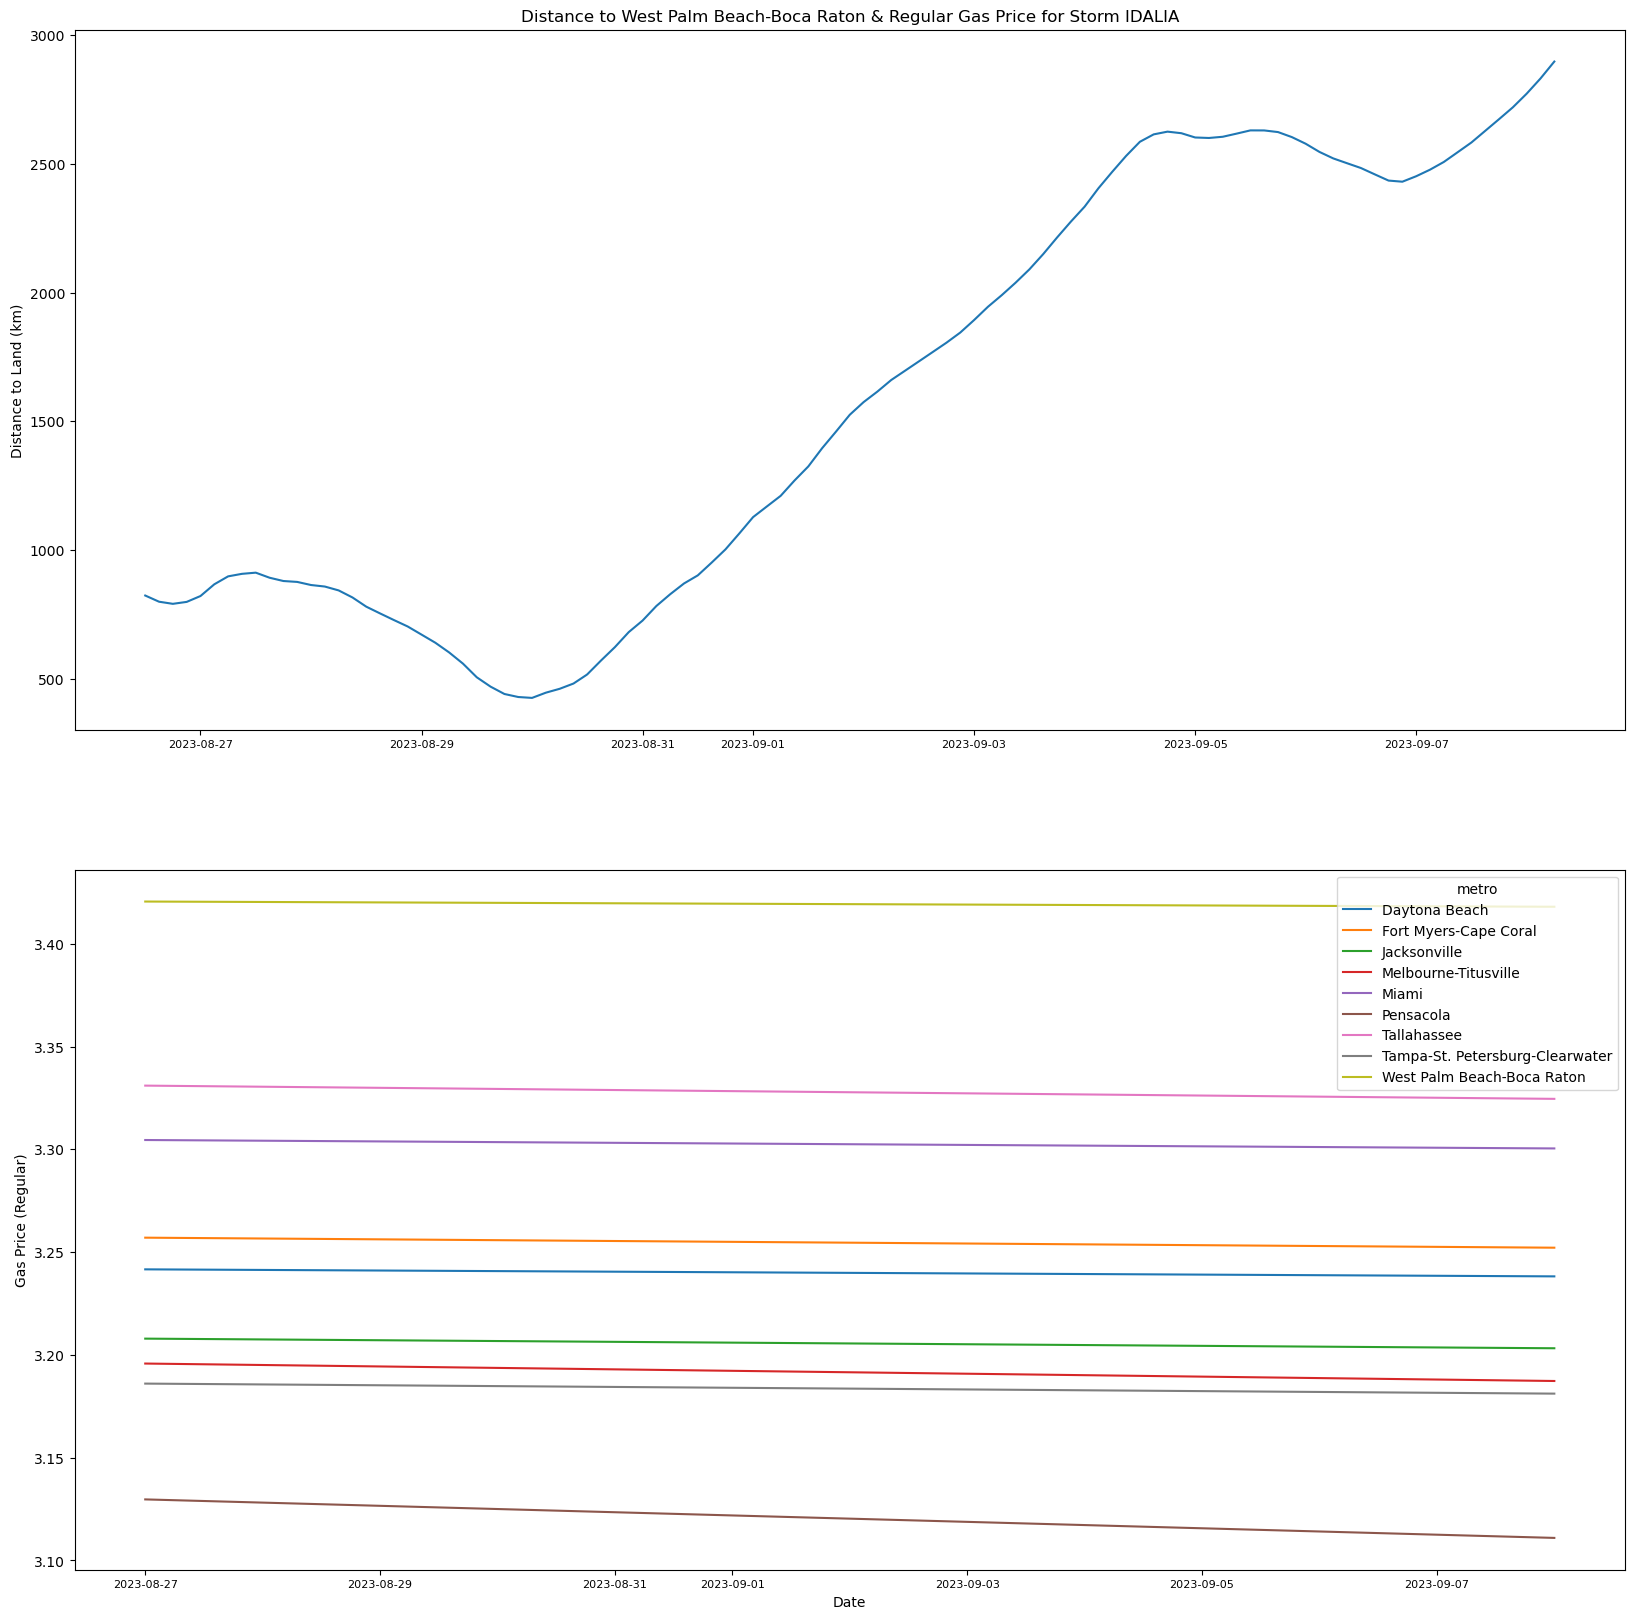

In [23]:
storm_overview(hurr_data_select, gas_data_select, metro, coast_pt_data, hurr_name, hurr_seas, metro_loc_data)

In [24]:
# Generate plot comparisons of specific metro gas prices and hurricane features (distance to metro, storm wind speed, storm travel speed)
# for identified hurricanes making land fall near specific metro areas

# List of identified storms and nearby metros
storm_data = {
    'Season': [2024,2024,2023,2023,2023,2024,2024,2024,2022,2022,2022,2022,2022], 
    'Name': ['Milton','Helene','Idalia','Idalia','Idalia','Debby','Debby','Debby','Nicole','Nicole','Nicole','Ian','Ian'], #,'Idalia',
    "Metro": ['Tampa-St. Petersburg-Clearwater','Tallahassee','Tallahassee','Tampa-St. Petersburg-Clearwater','Jacksonville','Tallahassee','Tampa-St. Petersburg-Clearwater','Jacksonville','Miami','West Palm Beach-Boca Raton','Melbourne-Titusville','Tampa-St. Petersburg-Clearwater','Fort Myers-Cape Coral']
}

storm_df = pd.DataFrame(storm_data)
print(storm_df)

L = storm_df.shape[0]

    Season    Name                            Metro
0     2024  Milton  Tampa-St. Petersburg-Clearwater
1     2024  Helene                      Tallahassee
2     2023  Idalia                      Tallahassee
3     2023  Idalia  Tampa-St. Petersburg-Clearwater
4     2023  Idalia                     Jacksonville
5     2024   Debby                      Tallahassee
6     2024   Debby  Tampa-St. Petersburg-Clearwater
7     2024   Debby                     Jacksonville
8     2022  Nicole                            Miami
9     2022  Nicole       West Palm Beach-Boca Raton
10    2022  Nicole             Melbourne-Titusville
11    2022     Ian  Tampa-St. Petersburg-Clearwater
12    2022     Ian            Fort Myers-Cape Coral


Hurricane MILTON (2024) and Tampa-St. Petersburg-Clearwater


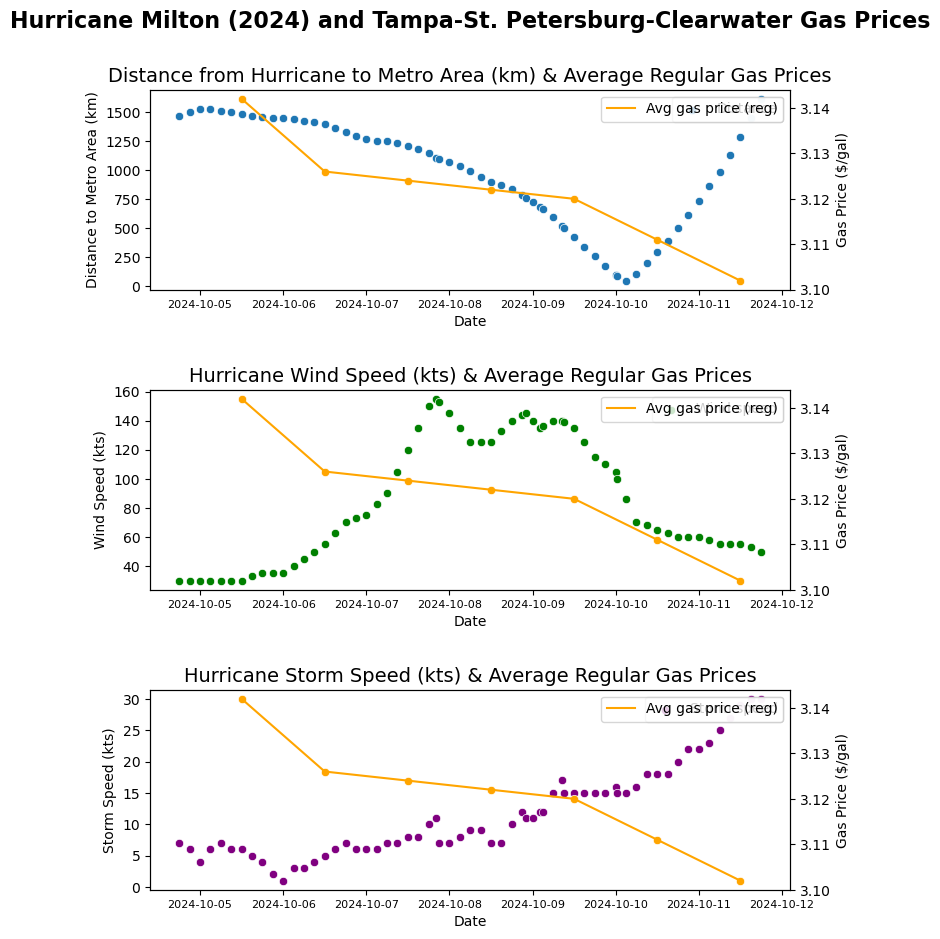

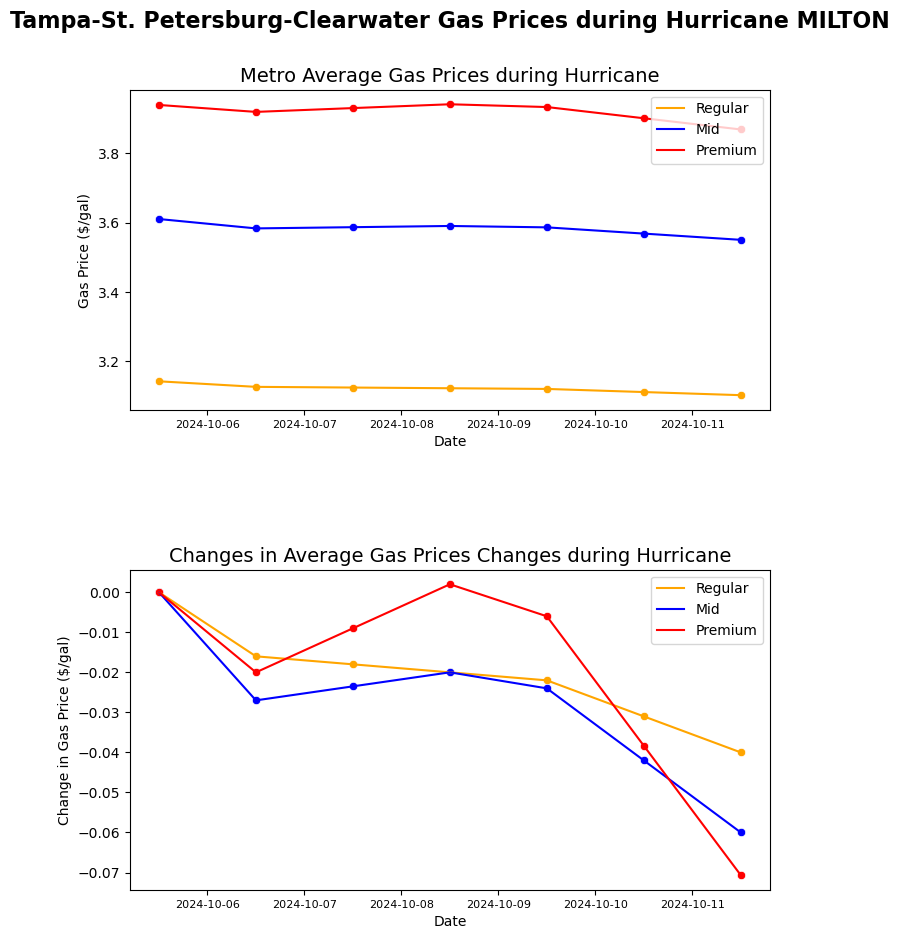

Hurricane HELENE (2024) and Tallahassee


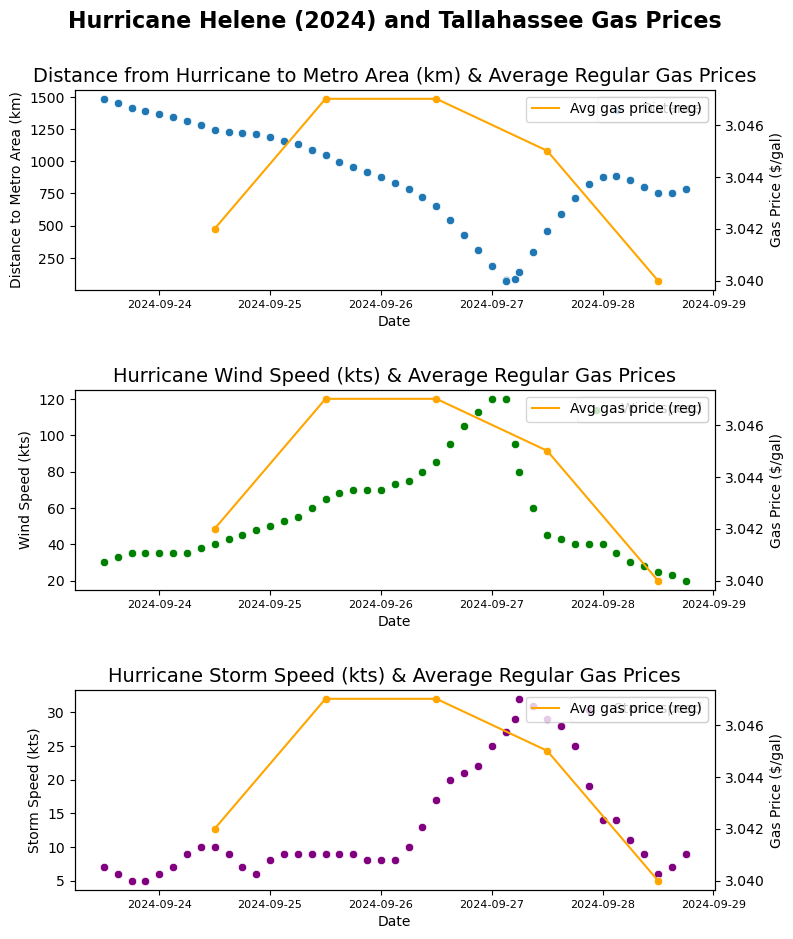

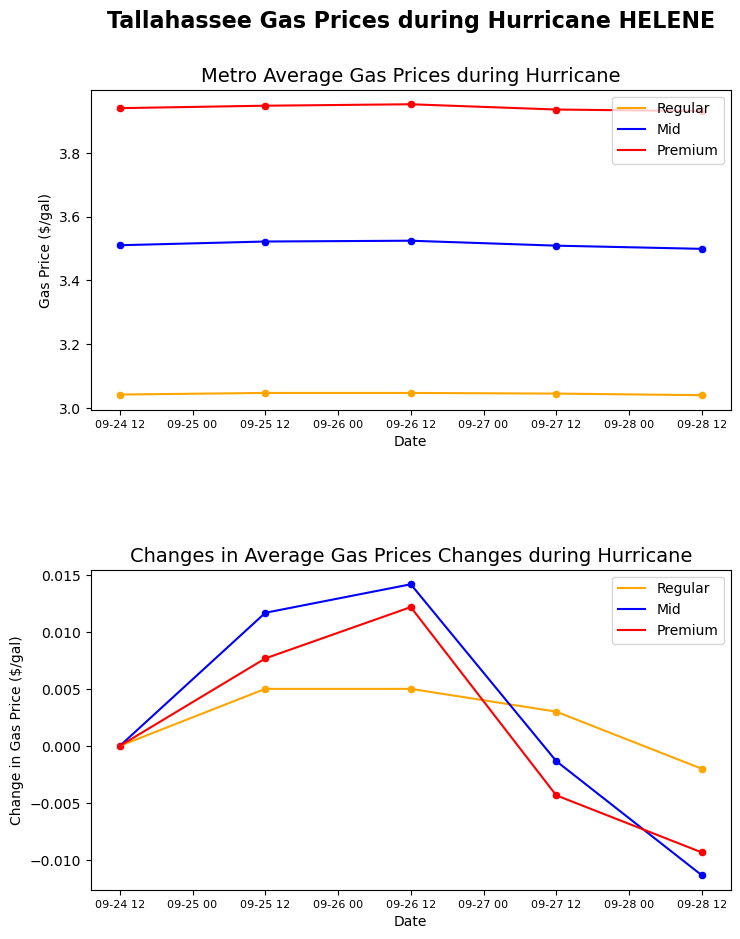

Hurricane IDALIA (2023) and Tallahassee


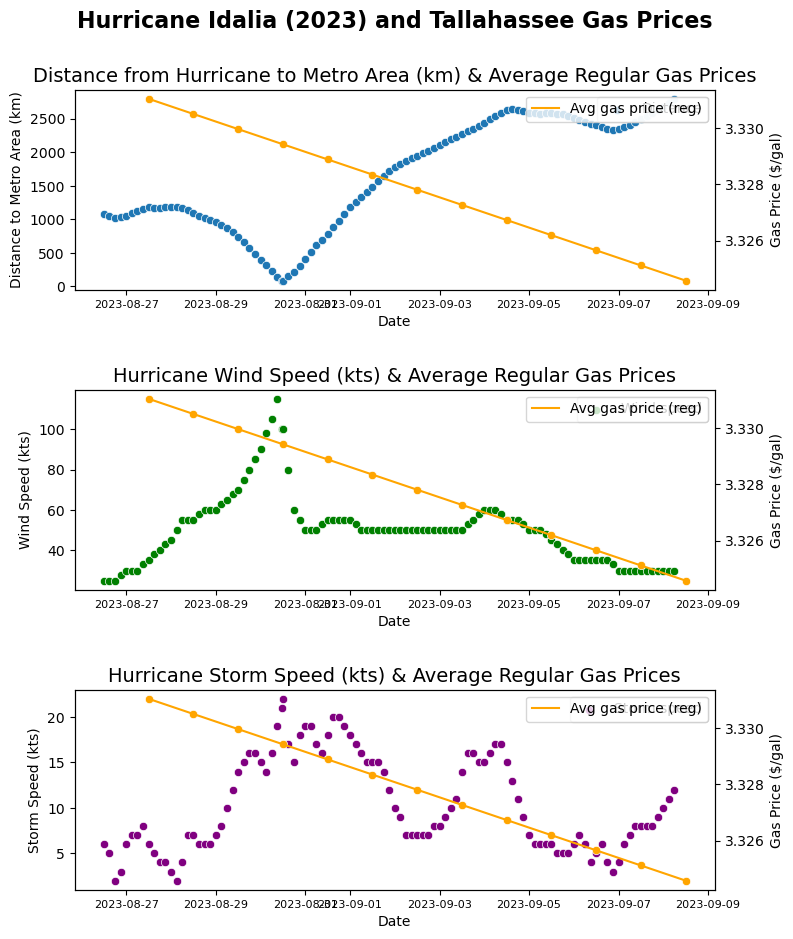

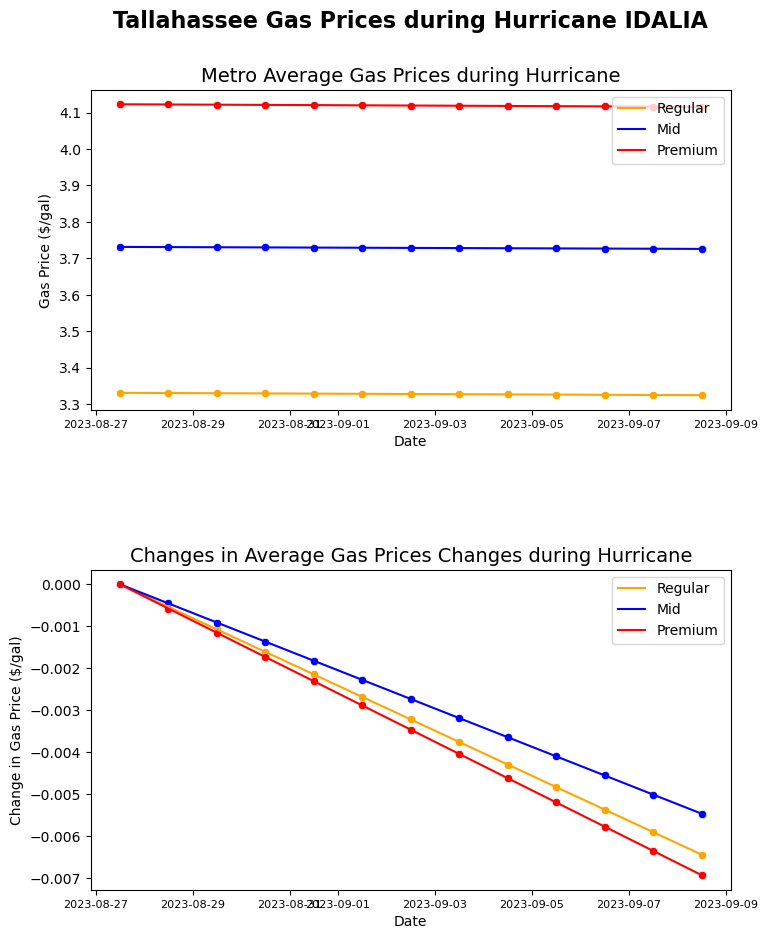

Hurricane IDALIA (2023) and Tampa-St. Petersburg-Clearwater


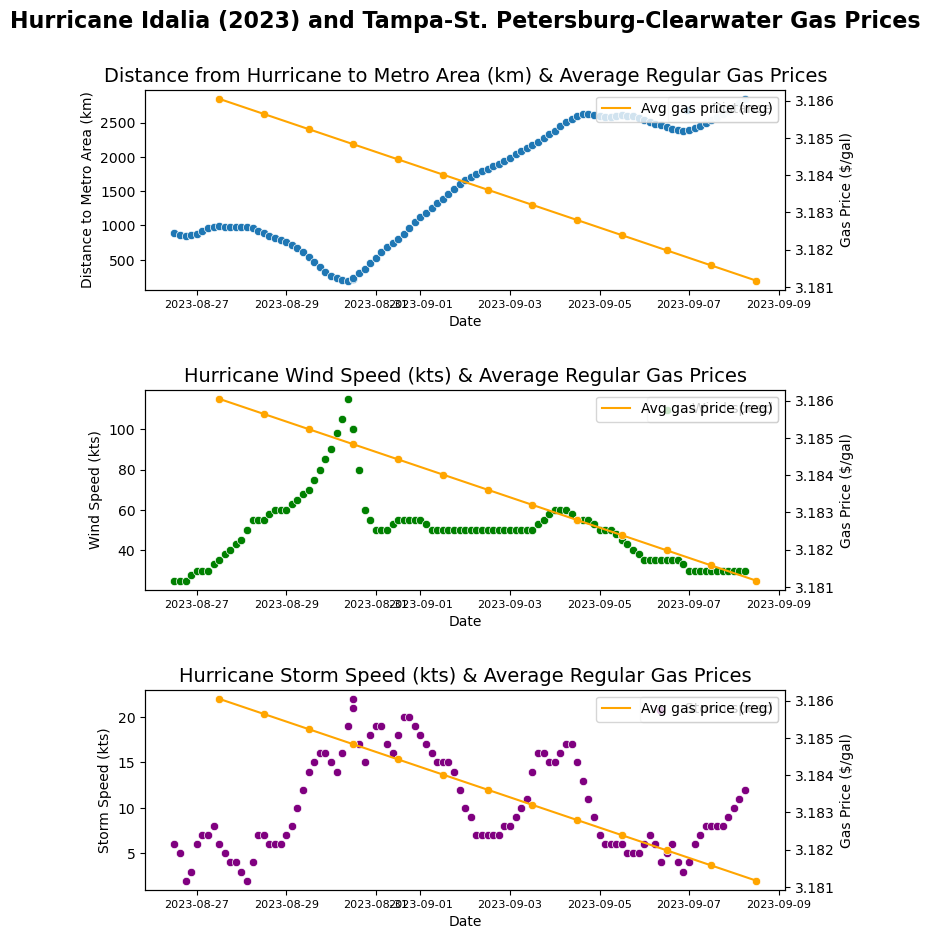

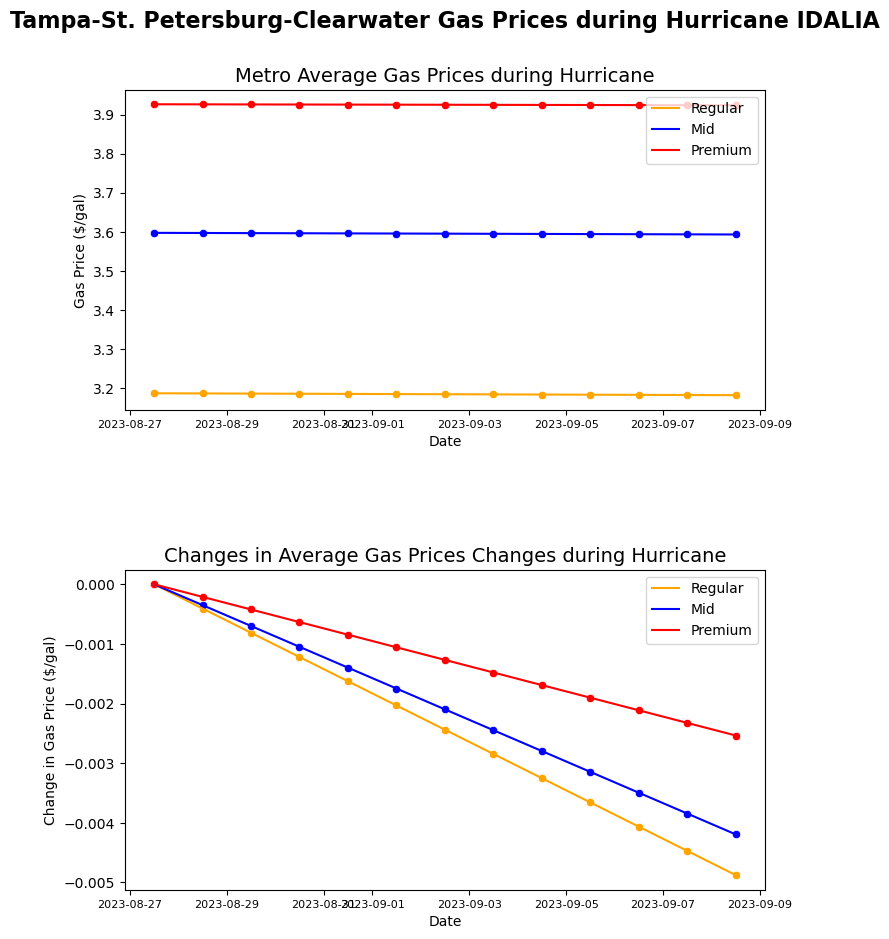

Hurricane IDALIA (2023) and Jacksonville


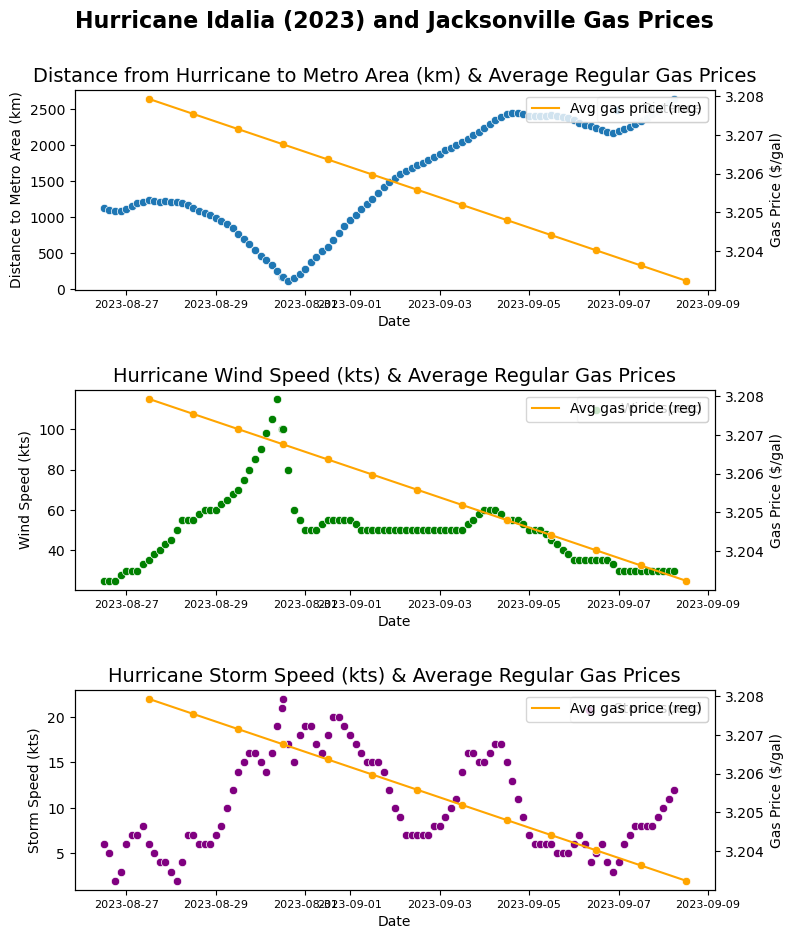

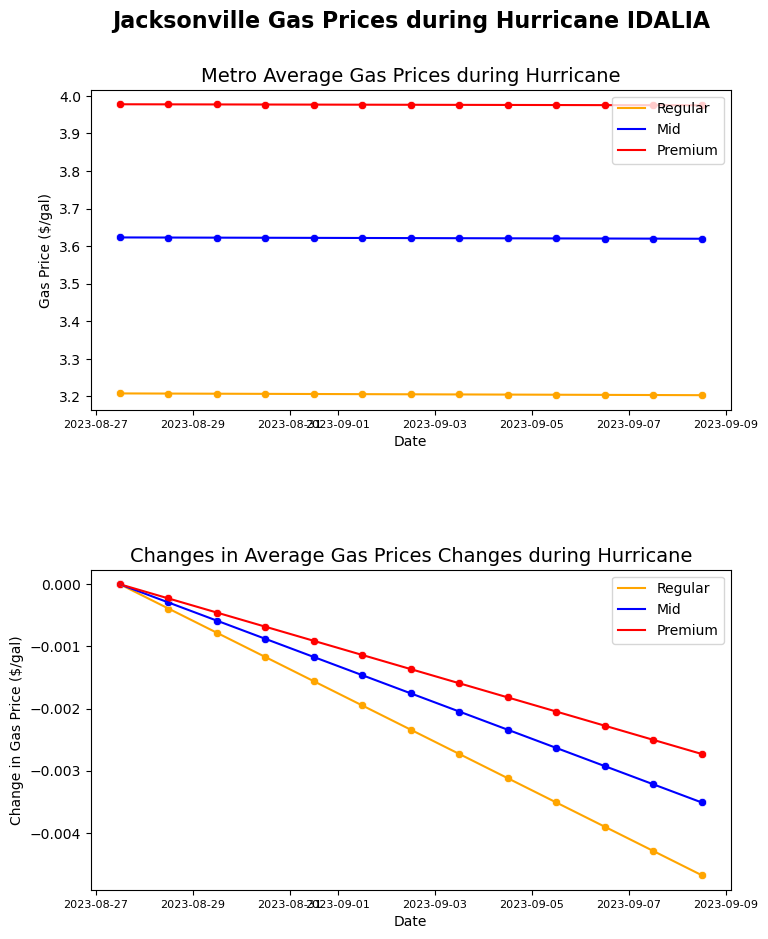

Hurricane DEBBY (2024) and Tallahassee


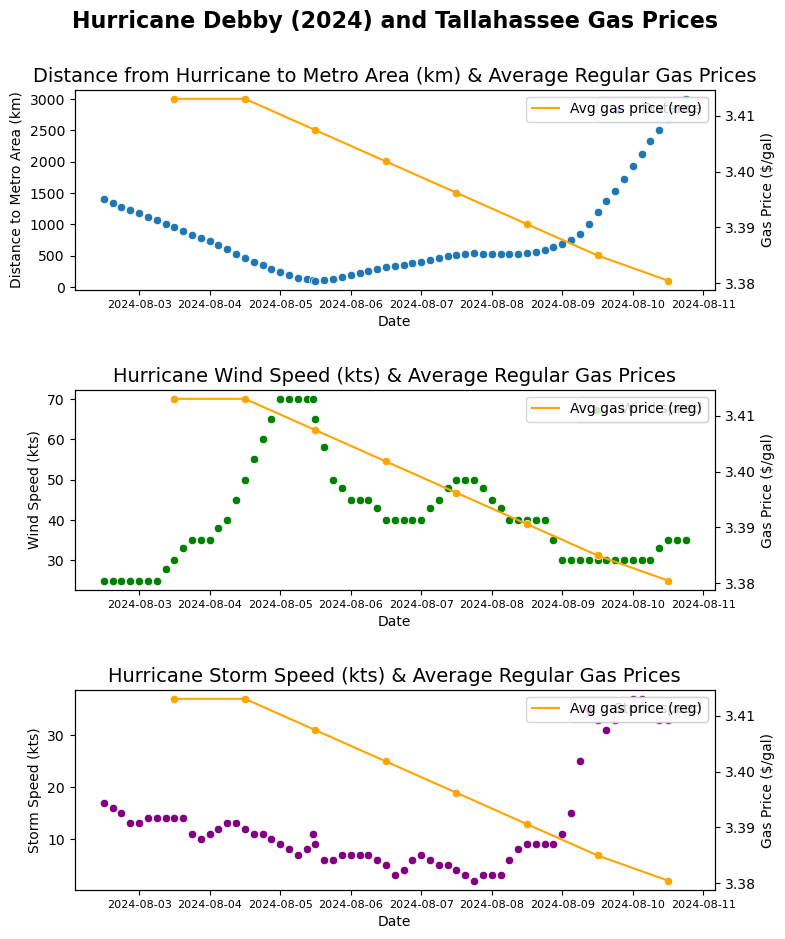

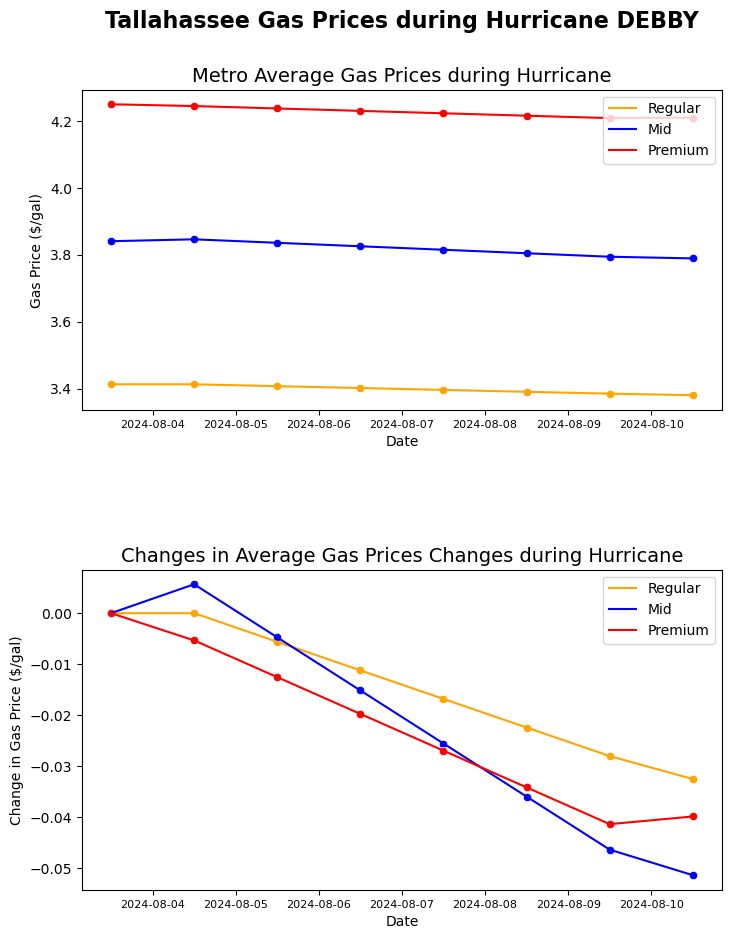

Hurricane DEBBY (2024) and Tampa-St. Petersburg-Clearwater


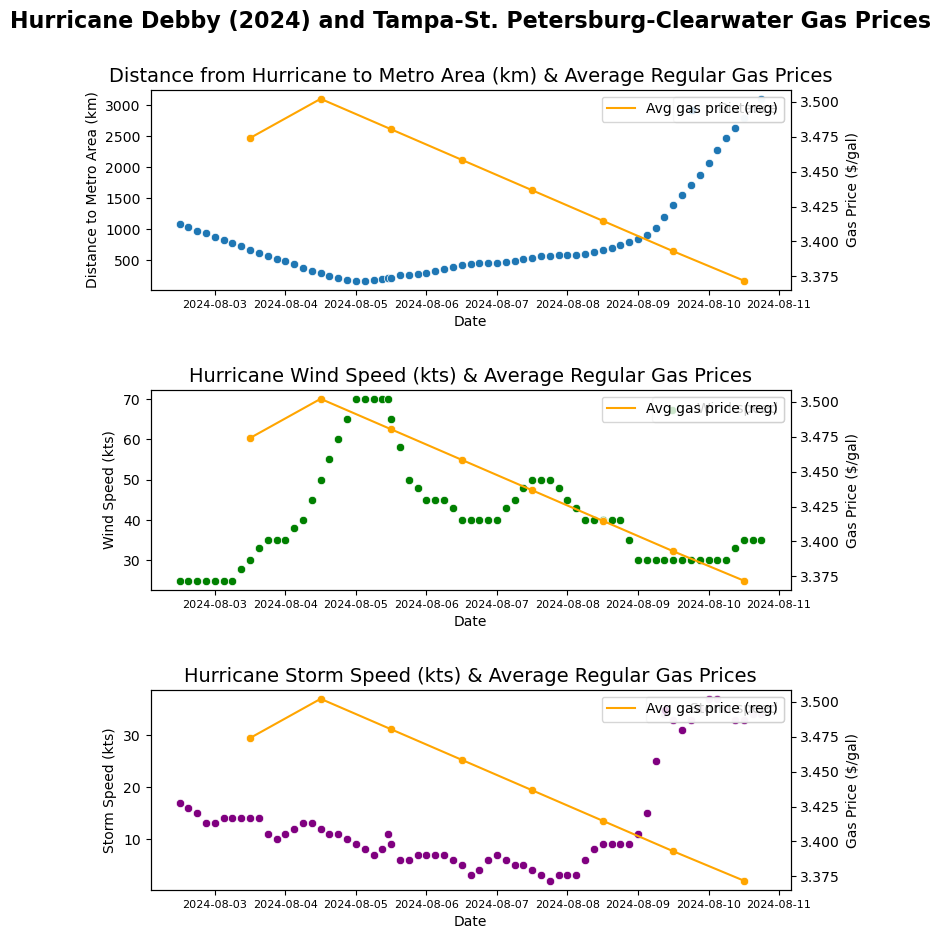

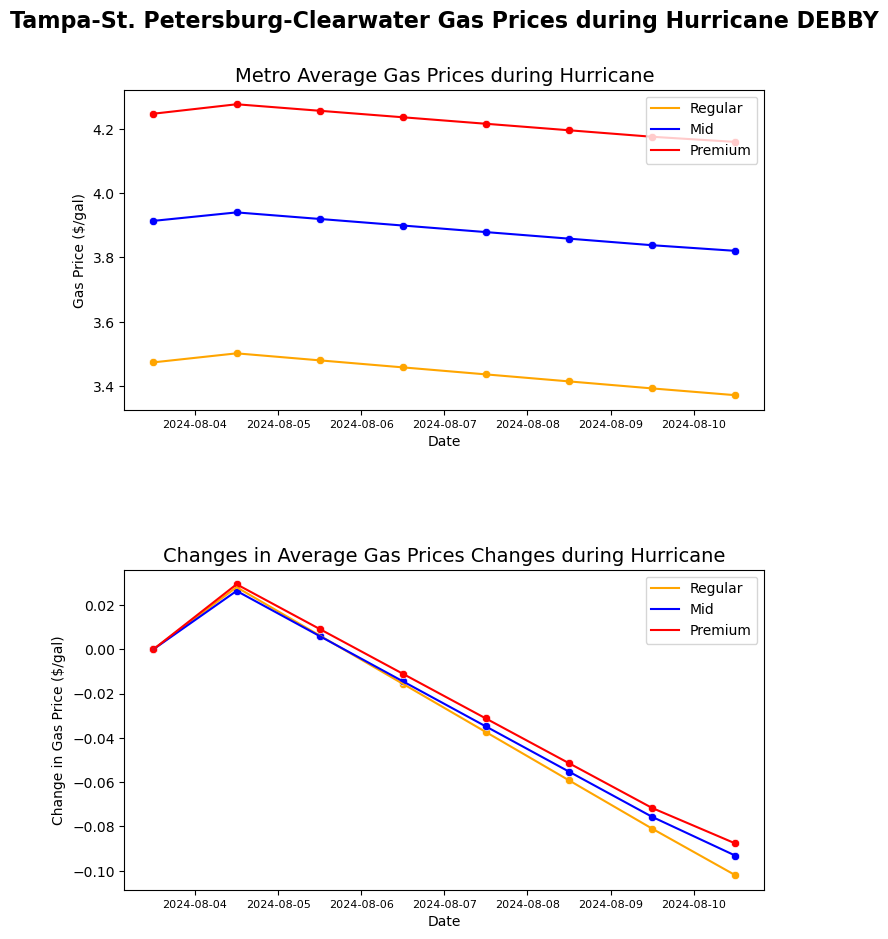

Hurricane DEBBY (2024) and Jacksonville


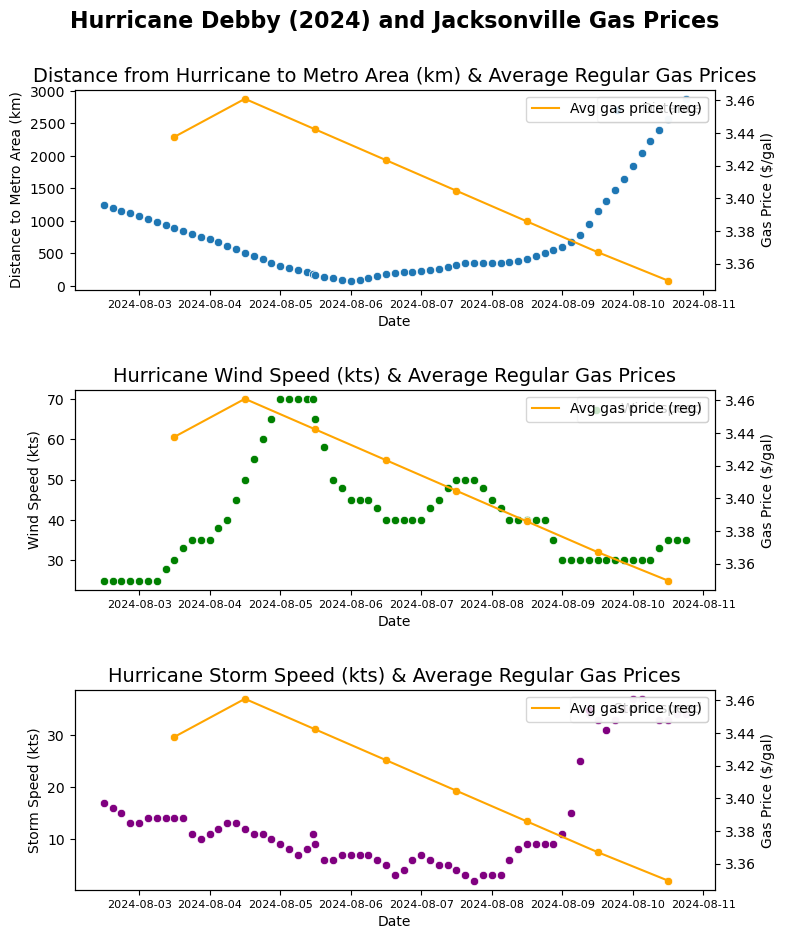

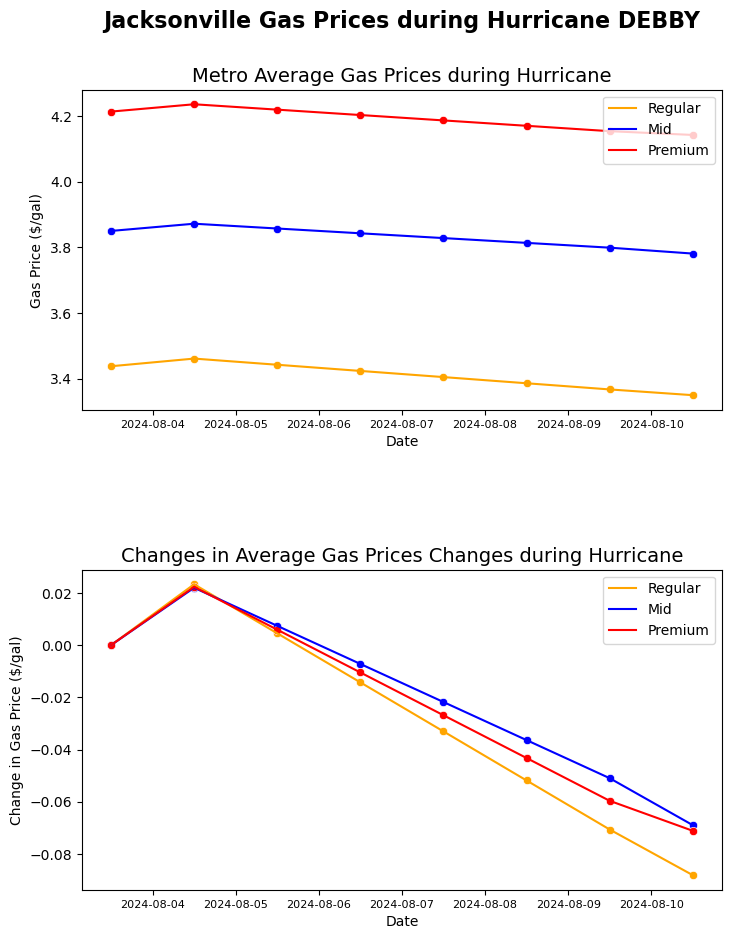

Hurricane NICOLE (2022) and Miami


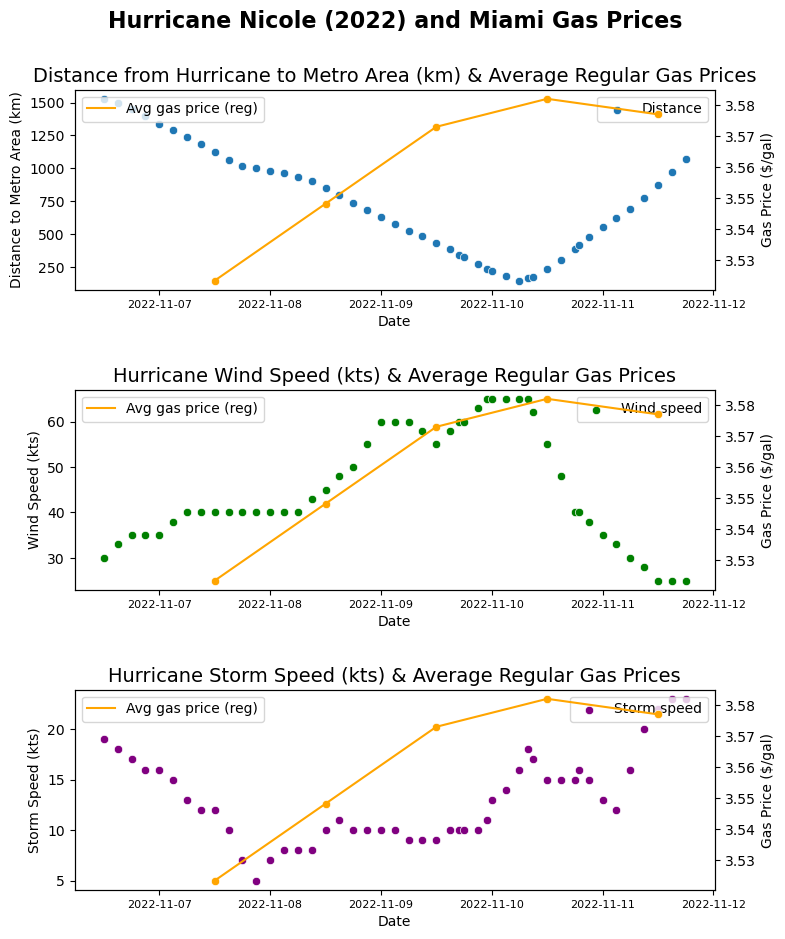

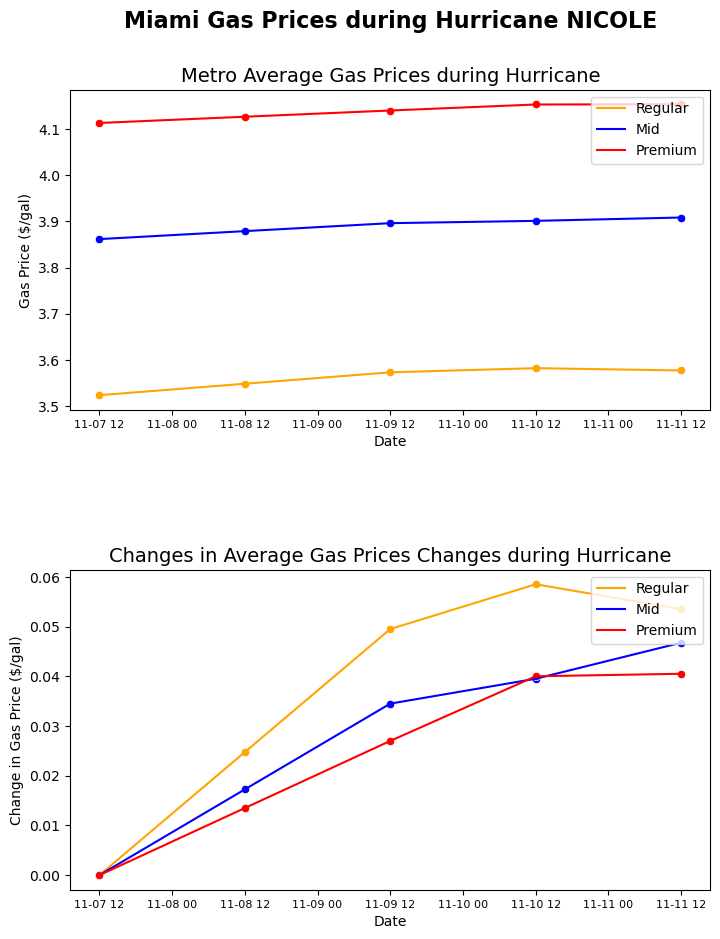

Hurricane NICOLE (2022) and West Palm Beach-Boca Raton


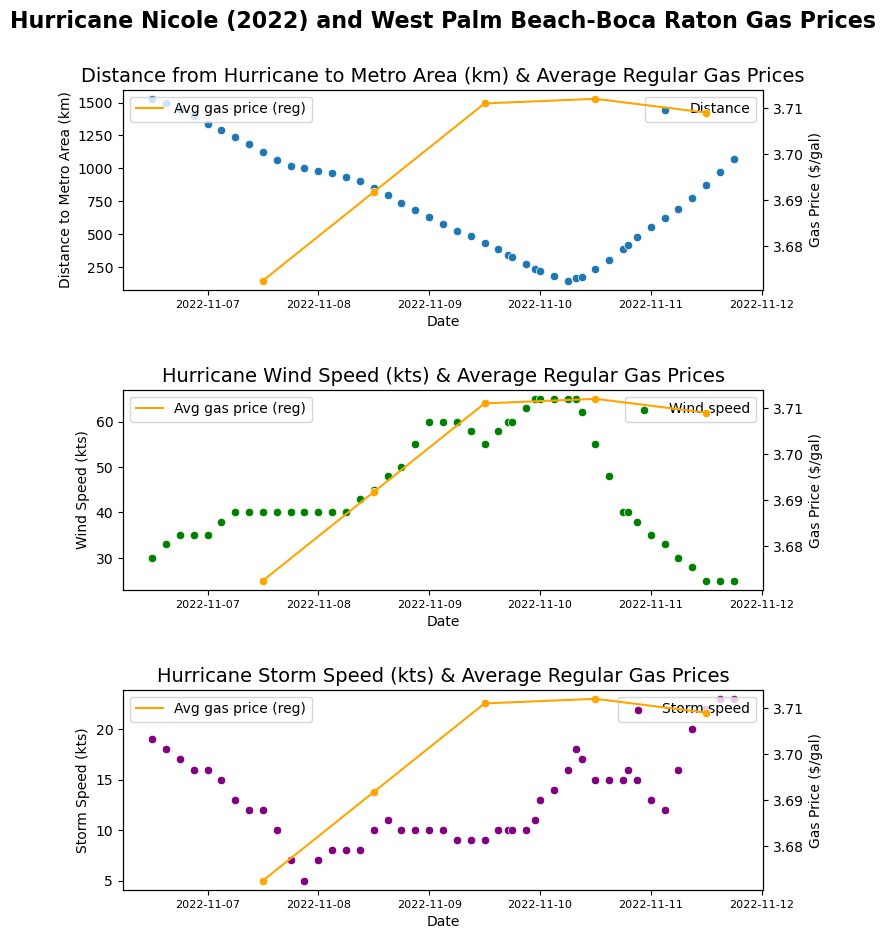

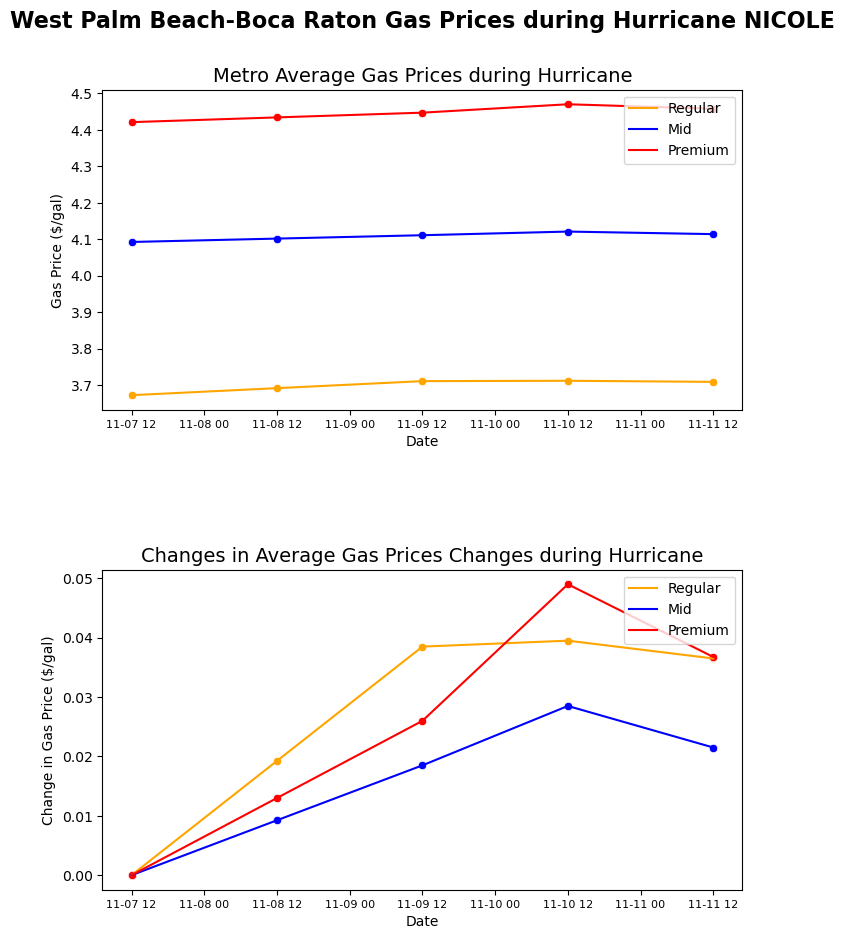

Hurricane NICOLE (2022) and Melbourne-Titusville


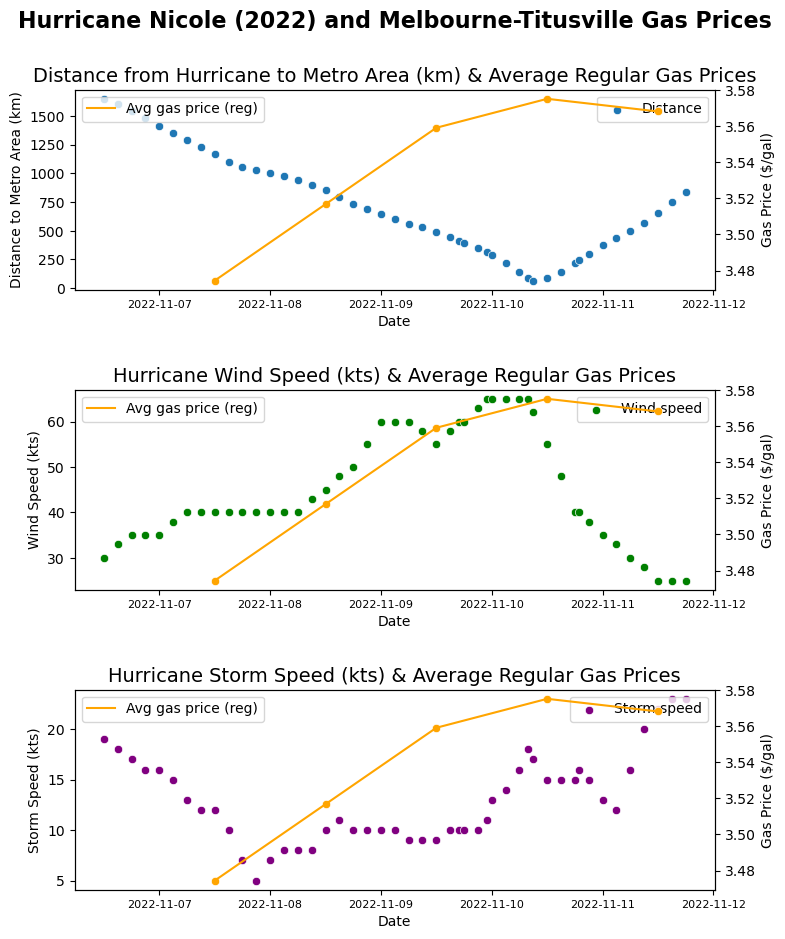

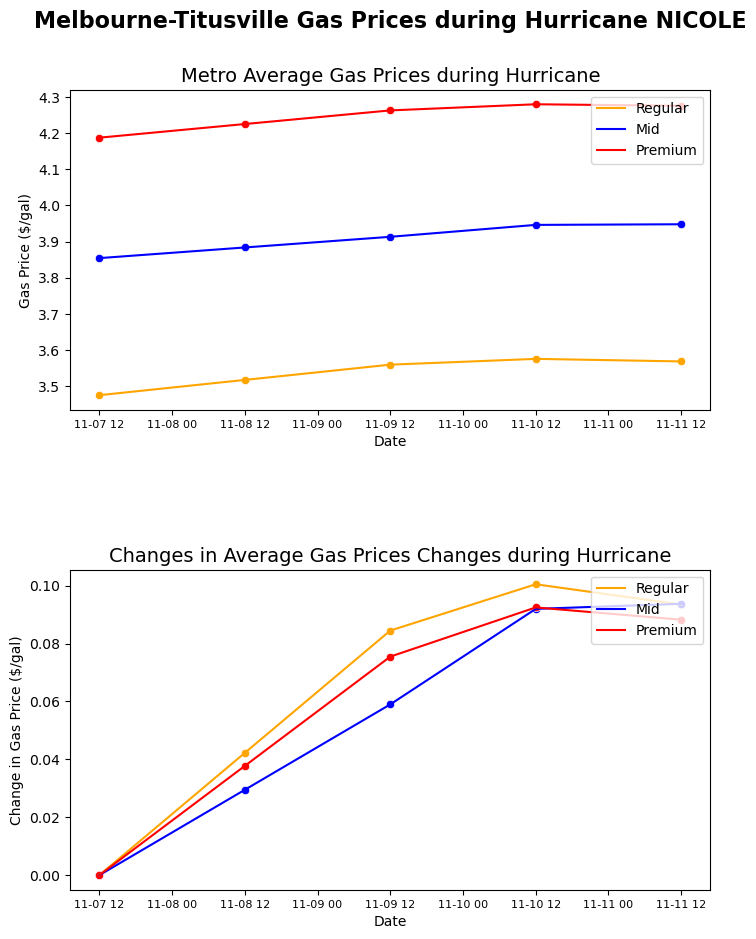

Hurricane IAN (2022) and Tampa-St. Petersburg-Clearwater


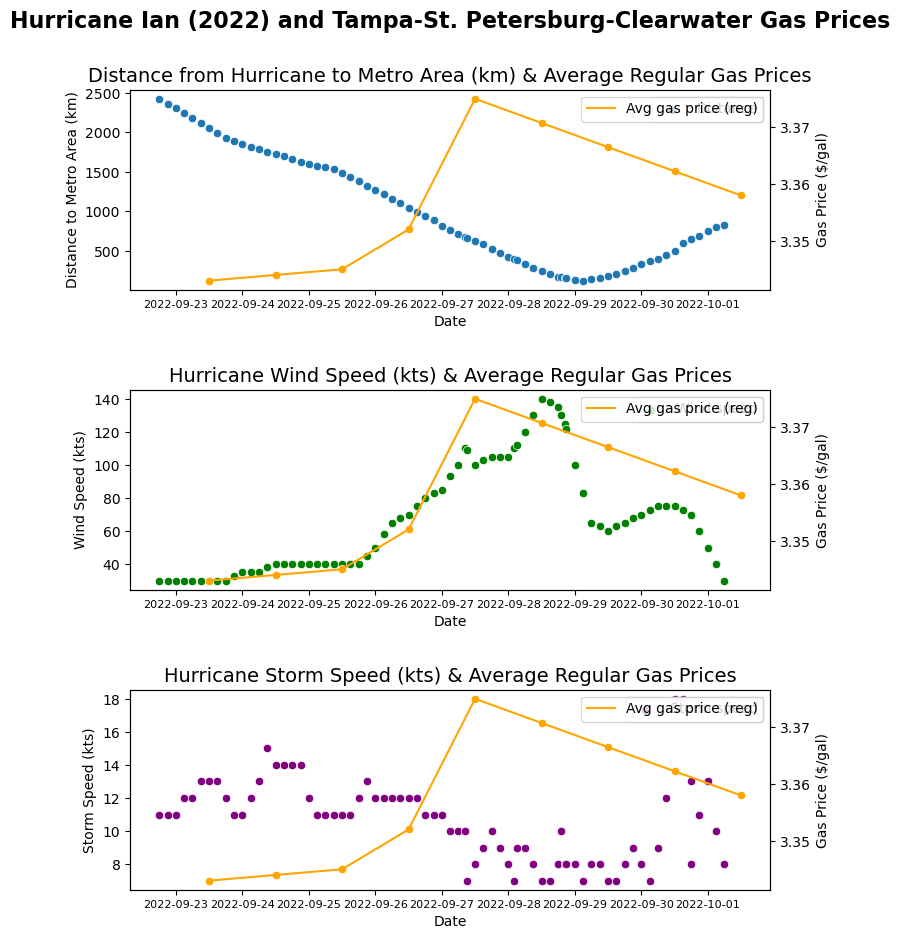

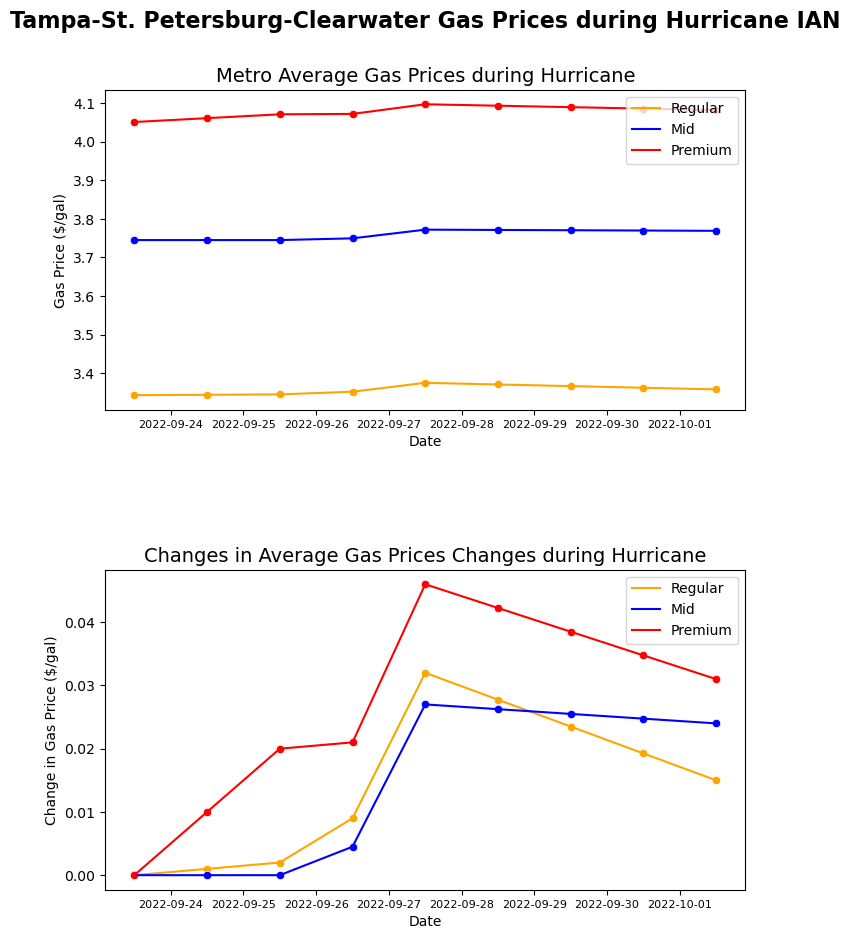

Hurricane IAN (2022) and Fort Myers-Cape Coral


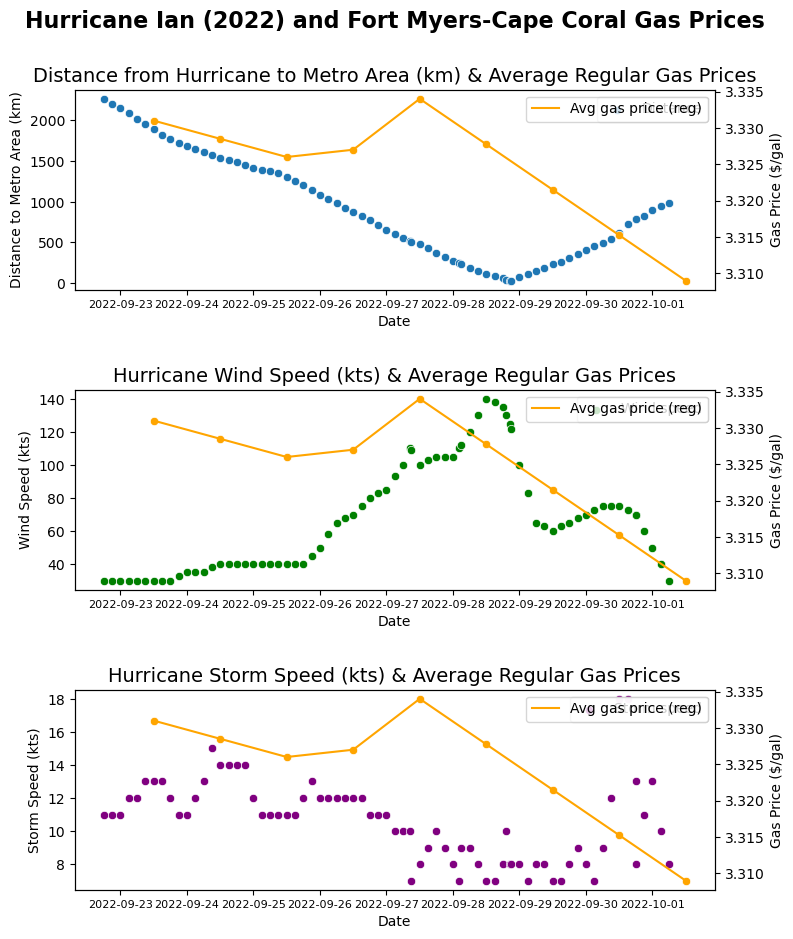

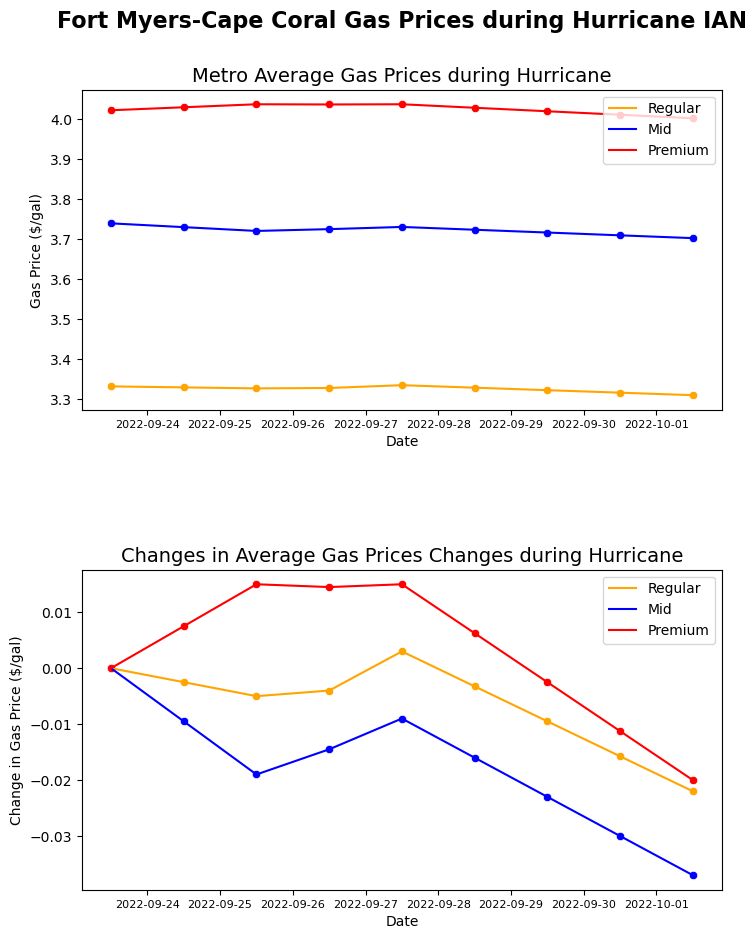

In [25]:
# Plot generation loop
for i in range(L):
    # assign variables
    hurr_seas = storm_df['Season'][i]
    hurr_name = storm_df['Name'][i].upper()
    metro_nm = storm_df['Metro'][i]

    print(f'Hurricane {hurr_name} ({hurr_seas}) and {metro_nm}')
    
    rel_plot(hurr_seas, hurr_name, metro_nm, metro_loc_data, hurr_data_redux, gas_data_redux)



In [26]:
#!pip freeze > requirements.txt